# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

**Описание данных**

- `'airports_nearest'` — расстояние до ближайшего аэропорта в метрах (м)
- `'balcony'` — число балконов
- `'ceiling_height'` — высота потолков (м)
- `'cityCenters_nearest'` — расстояние до центра города (м)
- `'days_exposition'` — сколько дней было размещено объявление (от публикации до снятия)
- `'first_day_exposition'` — дата публикации
- `'floor'` — этаж
- `'floors_total'` — всего этажей в доме
- `'is_apartment'` — апартаменты (булев тип)
- `'kitchen_area'` — площадь кухни в квадратных метрах (м²)
- `'last_price'` — цена на момент снятия с публикации
- `'living_area'` — жилая площадь в квадратных метрах (м²)
- `'locality_name'` — название населённого пункта
- `'open_plan'` — свободная планировка (булев тип)
- `'parks_around3000'` — число парков в радиусе 3 км
- `'parks_nearest'` — расстояние до ближайшего парка (м)
- `'ponds_around3000'` — число водоёмов в радиусе 3 км
- `'ponds_nearest'` — расстояние до ближайшего водоёма (м)
- `'rooms'` — число комнат
- `'studio'` — квартира-студия (булев тип)
- `'total_area'` — общая площадь квартиры в квадратных метрах (м²)
- `'total_images'` — число фотографий квартиры в объявлении

### Откройте файл с данными и изучите общую информацию

#### Загружаем данные из csv-файла в датафрейм c помощью библиотеки pandas.

In [ ]:
# ссылки сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.max_columns = 31

try:
    data = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')
except:
    data = pd.read_csv('https://адрес_удален/datasets/real_estate_data.csv', sep='\t')

Кроме pandas для непосредственной работы нам может пригодится для очистки данных и визуализации результатов библиотека matplotlib, поэтому подключим ее сразу. Заодно подхкорректируем выводимое на экран количество столбцов для удобства работы с датафреймом.

#### Выводим первые 20 строчек датафрейма data на экран

In [ ]:
data.head(20)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,False,False,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,False,False,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,False,False,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,False,False,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,False,False,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,False,False,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,False,False,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,False,False,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,False,False,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


Как мы видим из описания данных и выведенной на экран части датафрейма наименования некоторых столбцов (`'cityCenters_nearest'`, `'parks_around3000'`, `'ponds_around3000'`) нарушают правила хорошего стиля. Также есть столбец `'is_apartment'` "стилистически выделяющийся" среди иных столбов булева типа (не имеющих в наименовании части 'is'). Исправим это позднее.

Также столбцы идут несколько вперемешку, не всегда группируясь по смыслу (например, столбцы с датой публикации и количеством дней размещения было бы логично разместить рядом, а не искать в разных частях датафрейма). К тому же из-за большой ширины она неудобна к просмотру и занимает большой объем памяти (а значит - увеличивается время на обработку). Поэтому для вывода переодически будем использовать только необходимые в данный момент столбцы, а для анализа данных будем создавать новые переменные.

#### Изучаем общую информацию о полученном датафрейме.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

#### Строим гистограмму для всех числовых столбцов таблицы на одном графике

array([[<AxesSubplot:title={'center':'total_images'}>,
        <AxesSubplot:title={'center':'last_price'}>,
        <AxesSubplot:title={'center':'total_area'}>,
        <AxesSubplot:title={'center':'rooms'}>],
       [<AxesSubplot:title={'center':'ceiling_height'}>,
        <AxesSubplot:title={'center':'floors_total'}>,
        <AxesSubplot:title={'center':'living_area'}>,
        <AxesSubplot:title={'center':'floor'}>],
       [<AxesSubplot:title={'center':'kitchen_area'}>,
        <AxesSubplot:title={'center':'balcony'}>,
        <AxesSubplot:title={'center':'airports_nearest'}>,
        <AxesSubplot:title={'center':'cityCenters_nearest'}>],
       [<AxesSubplot:title={'center':'parks_around3000'}>,
        <AxesSubplot:title={'center':'parks_nearest'}>,
        <AxesSubplot:title={'center':'ponds_around3000'}>,
        <AxesSubplot:title={'center':'ponds_nearest'}>],
       [<AxesSubplot:title={'center':'days_exposition'}>, <AxesSubplot:>,
        <AxesSubplot:>, <AxesSubplot:>]], d

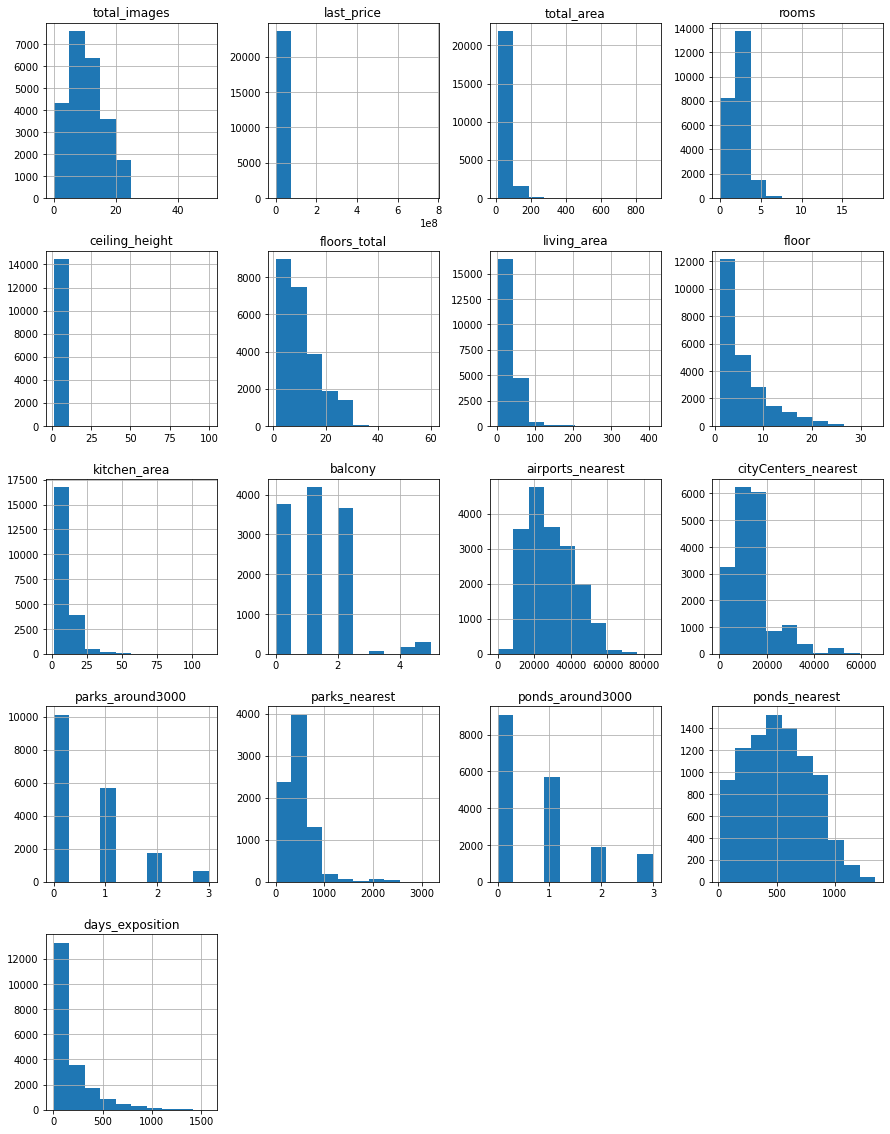

In [ ]:
data.hist(figsize=(15,20))

По построенным гистограммам мы можем заметить некоторое количество закономерностей: что меньшая доля выставленной на продажу недвижимости  имеет большее количество парков/водоемов поблизости (а максимальное количесво этих природных объектов не превышает трех), при этом парки чаще находятся ближе, чем водоемы; доля низких этажей (большинство продаваемых объектов расположены на 10 этаже и ниже) и низких зданий выше (большинство зданий имеет 20 и менее этажей), чем высоких; аналогично чаще встречаются маленькие квартиры (и основная часть объектов имеет площадь до 100 м²) и кухни (до 20 м²), чем более просторные. И что большинство объектов продается в течении года.

### Выполните предобработку данных

#### Переименование столбцов

Приведем название столбцов в соответствие с хорошим стилем и единообразием

In [ ]:
data = data.rename(columns={'is_apartment':'apartment','cityCenters_nearest':'city_centers_nearest',
                            'parks_around3000':'parks_around_3000', 'ponds_around3000':'ponds_around_3000'})

In [ ]:
data.columns #проверка успешности переименования

Index(['total_images', 'last_price', 'total_area', 'first_day_exposition',
       'rooms', 'ceiling_height', 'floors_total', 'living_area', 'floor',
       'apartment', 'studio', 'open_plan', 'kitchen_area', 'balcony',
       'locality_name', 'airports_nearest', 'city_centers_nearest',
       'parks_around_3000', 'parks_nearest', 'ponds_around_3000',
       'ponds_nearest', 'days_exposition'],
      dtype='object')

Исправим порядок колонок

In [ ]:
data = data[['total_images',
             'days_exposition','first_day_exposition',
             'last_price',
             'apartment', 'studio', 'open_plan',
             'total_area', 'living_area', 'kitchen_area',
             'rooms', 'balcony', 'ceiling_height',
             'floor', 'floors_total',
             'locality_name', 'airports_nearest', 'city_centers_nearest',
             'parks_around_3000', 'parks_nearest',
             'ponds_around_3000', 'ponds_nearest']]

In [ ]:
data.info() # проверка успешности переcтановки

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   days_exposition       20518 non-null  float64
 2   first_day_exposition  23699 non-null  object 
 3   last_price            23699 non-null  float64
 4   apartment             2775 non-null   object 
 5   studio                23699 non-null  bool   
 6   open_plan             23699 non-null  bool   
 7   total_area            23699 non-null  float64
 8   living_area           21796 non-null  float64
 9   kitchen_area          21421 non-null  float64
 10  rooms                 23699 non-null  int64  
 11  balcony               12180 non-null  float64
 12  ceiling_height        14504 non-null  float64
 13  floor                 23699 non-null  int64  
 14  floors_total          23613 non-null  float64
 15  locality_name      

С переименованными столбцами, расставленными в более логичном порядке, работать станет удобнее.

#### Поиск и удаление пропусков

##### Определим, в каких столбцах есть пропуски и узнаем их количество

In [ ]:
data.isna().sum()

total_images                0
days_exposition          3181
first_day_exposition        0
last_price                  0
apartment               20924
studio                      0
open_plan                   0
total_area                  0
living_area              1903
kitchen_area             2278
rooms                       0
balcony                 11519
ceiling_height           9195
floor                       0
floors_total               86
locality_name              49
airports_nearest         5542
city_centers_nearest     5519
parks_around_3000        5518
parks_nearest           15620
ponds_around_3000        5518
ponds_nearest           14589
dtype: int64

Выявлены пропуски в большинстве столбцов. Самая большая доля (88%!) в стобце `'apartment'`, отвечающем за принадлежности продаваемого объекта к аппартаментам. Несколько меньше, но все равно превышающую половину доли составляют столбцы, отвечающие за расстояние до ближайших парков `'parks_nearest'`(66%) и водоемов `'ponds_nearest'`(62%). Также большая доля (39%) в столбце, отвечающем за количество балконов `'balcony'`. Наименьшее количество пропусков в столбцах с именем населенного пункта`'locality_name'` и с общим количеством этаже в доме`'floors_total'`.

Лишь для части из тех, что заполнялись пользователем, можно предположить логичную замену, которую в будущем можно применить: столбцы `'apartment'` (апартаменты (булев тип)) - пропуск в большинстве случаев значит False, `'balcony'` (число балконов) - заменим 0,  

Остальная часть "пользовательских" данных, например, столбец `'ceiling_height '`(высота потолков (м) - исправить проблематично, поэтому пропуски придется оставить.

У столбцов `'living_area'` (жилая площадь в квадратных метрах (м²)), `'kitchen_area'` (площадь кухни в квадратных метрах (м²) мы тоже не можем узнать точных значений, но можем предположить, что эти пропуски могут быть характерны для квартир-студий, не имеющих подобного разделения (то есть четко оформленной планом кухни).

Точное название населённого пункта `'locality_name'` установить тоже не выйдет, но можно указать, что оно неизвестно. Так же и со столбцом `'floors_total'`(всего этажей в доме) - здесь мы можем лишь предположить минимум, исходя из этажа продаваемой квартиры, но в связи с небольшим количеством пропусков их можно удалить.

Также можно предположить замену и для некоторых "подтянутых" данных: `'parks_nearest'` (расстояние до ближайшего парка (м))  зависит от столбца `'parks_around_3000'`: '0' в столбце `'parks_around_3000'` ожидаемо приводит к пропуску (`'NaN'`) в столбце `'parks_nearest'`, так как нельзя посчитать расстояние до несуществующего объекта, поэтому можно потенциально ввести столбец булева типа для обозначения наличия парка в радиусе 3 км; аналогично `'NaN'` в столбце `'parks_around_3000'` также приводит к пропуску в зависимом от него столбце `'parks_nearest'`, но в данном случае проблему устранить уже сложнее. Такая же ситуация у столбцов `'ponds_nearest'` (расстояние до ближайшего водоёма (м)) и `'ponds_around_3000'`.

Количество пропусков в "геолокационных" столбцах `'airports_nearest'` (расстояние до ближайшего аэропорта в метрах (м)) `'city_centers_nearest'` (расстояние до центра города (м)), `'parks_around_3000'` (число парков в радиусе 3 км), `'ponds_around_3000'` (число водоёмов в радиусе 3 км), `'ponds_around_3000'` (число водоёмов в радиусе 3 км) значительно превышает количество пропусков в столбце с наименованием населенного пункта (в таком случае пропуски можно было бы отнести к условно-человеческому фактору, и они были бы ожидаемы в связи с недостатком информации для правильного геолоцирования указанной в объявлении недвижимости) и составляет чуть меньше четверти! от общего количества данных (причем их количества сопоставимы). Поэтому потенциально требуется выяснения причин появления данных пропусков (проблемы с доступом к системе геолокации? проблемы с выгрузкой в систему с объявлениями? а может, эти объявления подавались в те времена, когда система еще не использовалась или использовалась не так массово?) с последующим исправлением.

Причину появления пропусков в столбце `'days_exposition'` (сколько дней было размещено объявление (от публикации до снятия)) также необходимо установить. Возможно, `'NaN'` появлялось в тех случаях, когда квартиру не удавалось продать (либо податель объявления забывал его самостоятельно снять) и объявление удалялось или уходило в архив автоматически после определенного периода времени.

Проверим, зависят ли пропуска в `'living_area'` и `'kitchen_area'` от того, является ли продаваемый объект студией.

In [ ]:
len(data[data['studio'] == True]) # узнаем, сколько всего у нас студий в датафрейме

149

In [ ]:
data[data['studio'] == True][{'total_area','living_area', 'kitchen_area'}].head(20)

,living_area,total_area,kitchen_area
144,15.50,27.00,NaN
440,24.75,27.11,NaN
608,NaN,25.00,NaN
697,17.50,24.10,NaN
716,12.00,17.00,NaN
1173,17.00,29.00,NaN
1174,18.00,32.00,NaN
1220,20.00,27.00,NaN
1260,16.00,27.00,NaN
1277,17.38,26.00,NaN


В выведенной части датафрейма мы видим отсутствие площадей кухонь во всех строках, при том, что жилая зона есть почти везде. Посчитаем, сколько и каких пропусков имеют наши студии.

In [ ]:
data[data['studio'] == True].isna().sum()

total_images              0
days_exposition          14
first_day_exposition      0
last_price                0
apartment               134
studio                    0
open_plan                 0
total_area                0
living_area              10
kitchen_area            149
rooms                     0
balcony                  58
ceiling_height           72
floor                     0
floors_total              3
locality_name             0
airports_nearest         57
city_centers_nearest     57
parks_around_3000        57
parks_nearest           128
ponds_around_3000        57
ponds_nearest            98
dtype: int64

Всего 149 объектов являются студиями, и у всех не указана площадь кухни, а вот жилая площадь не указана только у десяти (то есть почти у всех студий она указана). Но пропусков по площадям у нас 2278 (кухня) и 1903 (жилая), значит оставшие пропуски у кухонь и практически все у жилой площади не связаны с принадлежностью квартиры к типу студия.

Но для студий можно утверждать, что отдельных кухонь они не имеют, то есть площадь кухни для них равно 0, что используем при замене пропусков.

Посчитаем количество аппартаментов и посмотрим на их параметры.

In [ ]:
len(data[data['apartment'] == True])

50

In [ ]:
data[data['apartment'] == True]

,total_images,days_exposition,first_day_exposition,last_price,apartment,studio,open_plan,total_area,living_area,kitchen_area,rooms,balcony,ceiling_height,floor,floors_total,locality_name,airports_nearest,city_centers_nearest,parks_around_3000,parks_nearest,ponds_around_3000,ponds_nearest
543,11,NaN,2018-11-06T00:00:00,12790000.0,True,False,False,56.60,29.400000,NaN,2,NaN,3.50,1,3.0,Петергоф,35248.0,30437.0,3.0,53.0,3.0,22.0
916,11,179.0,2018-01-11T00:00:00,8183000.0,True,False,False,70.00,40.000000,NaN,2,2.0,3.12,3,3.0,Санкт-Петербург,45796.0,21729.0,0.0,NaN,1.0,754.0
1109,1,1572.0,2014-12-09T00:00:00,34878556.0,True,False,False,95.80,58.300000,20.00,2,1.0,NaN,5,6.0,Санкт-Петербург,21860.0,318.0,2.0,160.0,3.0,569.0
1608,12,13.0,2019-01-30T00:00:00,2150000.0,True,False,False,20.10,NaN,NaN,1,NaN,NaN,1,9.0,Санкт-Петербург,26646.0,12147.0,0.0,NaN,0.0,NaN
2759,11,7.0,2018-07-27T00:00:00,7500000.0,True,False,False,152.00,NaN,NaN,3,1.0,3.00,1,3.0,Всеволожск,NaN,NaN,NaN,NaN,NaN,NaN
2975,9,273.0,2018-07-23T00:00:00,4931398.0,True,False,False,42.90,20.390000,10.29,1,NaN,3.15,3,4.0,Санкт-Петербург,44870.0,20802.0,0.0,NaN,1.0,792.0
3067,13,96.0,2018-09-08T00:00:00,6600000.0,True,False,False,95.00,45.000000,25.00,2,2.0,4.50,7,7.0,Выборг,NaN,NaN,NaN,NaN,NaN,NaN
3816,4,60.0,2016-05-16T00:00:00,4779000.0,True,False,False,53.10,19.800000,15.90,1,2.0,NaN,6,13.0,Санкт-Петербург,19396.0,4516.0,0.0,NaN,1.0,826.0
3951,10,NaN,2019-04-20T00:00:00,4300000.0,True,False,False,50.00,17.000000,12.00,1,2.0,3.00,9,11.0,Санкт-Петербург,10143.0,11367.0,0.0,NaN,0.0,NaN
4339,19,22.0,2019-03-25T00:00:00,6900000.0,True,False,False,72.00,70.000000,NaN,3,NaN,3.50,1,4.0,Санкт-Петербург,31487.0,4466.0,2.0,353.0,1.0,439.0


У всех апартаментов жилая площадь указана с большим количеством цифр после запятой (когда как в целом характерно использование двух цифр после запятой). Возможно, это своеобразная особенность базы, хранящей данные аппартаментов (такая точность невозможна при измерении площади объекта недвижимости). Но за счет этого мы можем попробовать предположить, что и другие объекты, которые имеют такой же формат записи жилой площади также являются аппартаментами.

Однако у нас слишком много (20924) пропусков, чтобы отсмотреть их вручную.

In [ ]:
data[(data['apartment'].isnull())&(data['living_area'].astype('str').str.len()>5)] # фильтруем наши столбцы

,total_images,days_exposition,first_day_exposition,last_price,apartment,studio,open_plan,total_area,living_area,kitchen_area,rooms,balcony,ceiling_height,floor,floors_total,locality_name,airports_nearest,city_centers_nearest,parks_around_3000,parks_nearest,ponds_around_3000,ponds_nearest
1293,4,832.0,2016-11-10T00:00:00,2401200.0,NaN,False,False,46.00,25.900002,8.50,2,2.0,2.56,18,18.0,Никольское,NaN,NaN,NaN,NaN,NaN,NaN
6059,11,40.0,2019-01-31T00:00:00,11950000.0,NaN,False,False,100.00,89.100006,NaN,3,2.0,2.98,2,10.0,Санкт-Петербург,38642.0,12548.0,0.0,NaN,0.0,NaN
7087,10,85.0,2016-06-09T00:00:00,6990000.0,NaN,False,False,57.00,31.599998,9.80,2,4.0,NaN,8,16.0,Санкт-Петербург,11924.0,10475.0,0.0,NaN,1.0,338.0
10624,19,197.0,2017-07-10T00:00:00,55969724.0,NaN,False,False,181.00,100.230000,15.62,4,2.0,3.00,4,8.0,Санкт-Петербург,27124.0,7463.0,3.0,318.0,2.0,509.0
10756,10,101.0,2017-10-05T00:00:00,8200000.0,NaN,False,False,116.00,60.300003,22.00,4,2.0,2.50,7,10.0,посёлок Тельмана,NaN,NaN,NaN,NaN,NaN,NaN
11310,3,NaN,2017-09-10T00:00:00,21161062.0,NaN,False,False,169.20,111.860000,15.07,4,NaN,3.30,4,16.0,Санкт-Петербург,37434.0,8460.0,1.0,441.0,2.0,427.0
11560,9,760.0,2014-12-11T00:00:00,79339000.0,NaN,False,False,218.00,123.270000,28.63,6,0.0,NaN,6,6.0,Санкт-Петербург,22688.0,2130.0,0.0,NaN,1.0,323.0
13501,5,157.0,2017-10-27T00:00:00,5500000.0,NaN,False,False,54.00,17.511500,8.30,2,NaN,2.56,8,10.0,Санкт-Петербург,37273.0,12482.0,0.0,NaN,0.0,NaN
14507,18,NaN,2018-07-10T00:00:00,10500000.0,NaN,False,False,73.50,32.199997,14.90,2,2.0,2.75,13,25.0,Санкт-Петербург,13292.0,14847.0,0.0,NaN,0.0,NaN
15300,1,54.0,2016-05-12T00:00:00,31557860.0,NaN,False,False,173.10,111.860000,14.80,4,0.0,3.10,13,16.0,Санкт-Петербург,37407.0,8434.0,1.0,456.0,2.0,454.0


In [ ]:
len(data[(data['apartment'].isnull())&(data['living_area'].astype('str').str.len()>5)]) # считаем наши столбцы

19

В наших строках с пропусками в столбце `'apartment'` оказались (хоть и не слишком много) объекты, которые скорее всего на самом деле являются аппартаментами.

Теперь с учетом сопоставимости количеств пропусков в геолокационных колонках проверим, не одни и те же это колонки (тем более, что в первых 20 выведеных строках три пустых в этих столбцах строки).

Для использования в фильтрации возьмем столбец с количеством парков в радиусе 3 км `'parks_around_3000'` так как благодаря гистограммам мы знаем варианты его значений и он имеет наименьшее количество пропусков среди других "геолокационных" столбцов.

In [ ]:
data[~data['parks_around_3000'].isin([0, 1, 2, 3])].isna().sum()

total_images               0
days_exposition          865
first_day_exposition       0
last_price                 0
apartment               4890
studio                     0
open_plan                  0
total_area                 0
living_area              623
kitchen_area             715
rooms                      0
balcony                 2710
ceiling_height          2575
floor                      0
floors_total              10
locality_name              8
airports_nearest        5518
city_centers_nearest    5518
parks_around_3000       5518
parks_nearest           5518
ponds_around_3000       5518
ponds_nearest           5518
dtype: int64

Можно было бы предположить, что пропуск в столбцах, указывающих на количество парков и водоемов поблизости также означает их отсутствие. Но во всех строках с пропусками в столбце `'parks_around_3000'` также отсутствуют и данные касательно количества водоемов в радиусе 3 км `'ponds_around_3000'` и расстояний до центра города `'city_centers_nearest'` и аэропортов `'airports_nearest'`. То есть данные практически во всех случаях (но не во всех, так как пропусков в столбцах `'airports_nearest'` и `'city_centers_nearest'`) пропадали одновременно (а данные из столбцов `'parks_nearest'` и `'ponds_nearest'` пропадали следом, как зависимые от `'parks_around_3000'`  и `'ponds_around_3000'`). А значит причина отсутвия наверняка тоже схожа.

Возможно, это технические сбои в выгрузке/получении/загрузки данных. А может, объявления создавались в те годы, когда геолоцирование еще не использовалось? На это может указывать достаточно большая доля таких строк в датафрейме.

##### Заполним пропуски там, где это возможно

In [ ]:
data['balcony'] = data['balcony'].fillna(0) # исправляем число балконов: заменяем 'NaN' на '0'

In [ ]:
# маркируем аппартаменты (вар3)
data.loc[data['living_area'].astype('str').str.len()>5, 'apartment'] = True # рабочий, оставляем

In [ ]:
len(data[data['apartment'] == True]) # проверка правильности маркировки аппартаментов

79

In [ ]:
data['apartment'] = data['apartment'].fillna(False) # исправляем (не)принадлежность к апартаментам

In [ ]:
data.loc[data['studio'] == True, 'kitchen_area'] = 0 # указываем на отсутствие кухонь у студий

In [ ]:
data.dropna(subset = ['locality_name'], inplace=True) # удаляем неизвестные населенные пункты

In [ ]:
data.dropna(subset = ['floors_total'], inplace=True) # удаляем здания с неизвестным количеством этажей

In [ ]:
data = data.reset_index() # сброс индексов

In [ ]:
data.isna().sum() # проверяем успешность замены пропусков

index                       0
total_images                0
days_exposition          3171
first_day_exposition        0
last_price                  0
apartment                   0
studio                      0
open_plan                   0
total_area                  0
living_area              1865
kitchen_area             2076
rooms                       0
balcony                     0
ceiling_height           9084
floor                       0
floors_total                0
locality_name               0
airports_nearest         5524
city_centers_nearest     5501
parks_around_3000        5500
parks_nearest           15535
ponds_around_3000        5500
ponds_nearest           14529
dtype: int64

**Выводы**

В данных выявлено большое количество пропусков (в некоторых столбцах их количество больше половины!).

Часть из них (`'apartment'`, `'balcony'`) удалось исправить логически (True или False в зависимости от формата жилой площади, и '0' соответственно).<div class="alert alert-info"> В столбце `'kitchen_area'` у студий (True в столбце `'studio'`) пропуски были заменены нулями.

Некоторые (затрагивающие информацию, касающуюся парков и водоемов) исправить в имеющихся столбцах нельзя, однако теоретически можно дополнительно добавить столбцы с булевым типом данных с информацией о наличии или отсутствии парков и водоемов в радиусе 3 км, чтобы максимально сохранить имеющиеся в датафрейме данные.
    
Строки с пропусками в столбцах `'floors_total'` или `'locality_name'` в связи со своим небольшим количеством были удалены.

Причиной пропусков в "пользовательской" части данных с большой долей вероятности является человеческий фактор: отсутствие у автора объявления каких-либо данных (например, высоты потолков, а документов под рукой нет), недопонимание при оформлении объявления (нет балконов - надо ставить 0, а не пропускать эту строчку), и обычная невнимательность (не заполнил все положенные строки, а форма перед публикацией не указала на пропуски и не уточнила, действительно ли автор хочет их оставить и выложить объявление в текущем виде). Также возможны сложности с определением того, что указать в столбце с общим количеством этажей в доме, если разные его части имеют разное их количество. Может потребоваться доработка заполняемой формы, чтобы сделать ее более понятной, а также добавить фунцию контроля пропусков ("у вас отсутсвуют следующие данные... вы уверены, что хотите опубликовть объявление?"), причем при наличие пропусков в критичных столбцах (например, населенный пункт) и вовсе не допускать объявление к публикации. Также

Также отсутствие некоторых значений в столбцах с площадями кухни (`'kitchen_area'`) можно объяснить и тем, что квартиры-студии не имеют специально выделенной площади под кухню, соотвественно площадь не выйдет (то есть технически она равно 0). Оставшиеся пропуски в этом столбце, а также столбце `'living_area'`(жилая площадь; он заполнен почти у всех студий) связаны с иными причинами, вероятно с неполным заполнением пользователем всех возможных параметров при подаче объявления.

Также замеченный необычный (слишком много цифр после запятой) формат представления жилой площади у аппартаментов (True в столбце `'apartment'`), не характерный для обычных квартир (False), может быть связан с тем, что данные по таким объектам могут храниться в отдельной базе, где могут быть ошибочные (невозможно иметь такую точность измерения площадей подобных объектов) настройки формата для данного столбца или произошли какие-то сбои при переносе этих данных в наш датафрейм.

Проблемы с пропусками в "геолокационных" столбцах по большей части носят технический характер (к человеческому фактору можно условно отнести только ту часть, которая возникла из-за того, что автор объявления не указал населенный пункт, но таких случаев совсем немного). Причем практически все пропуски находятся в одних и тех же строках, то есть причины их появления схожи. Вероятны проблемы с передачей данных на геолоцирование, с соотнесением объекта из объявления с картой или рассчетами необходимых расстояний (то есть проблемы с самим геолоцированием), или проблемы с выгрузкой геолокационных данных на сервер с объявлениями. Также есть вероятность (на что может указывать большая доля таких строк в датафрейме), что эти объявления были созданы до массового подключения системы геолоцирования. Для улучшения качества исследования необходимо выяснить причины и исправить их.

Так же для лучшего понимания результатов исследования хорошо бы узнать, как эти расстояния вообще замеряют с точностью до метра: от какой точки до какой (например, от центра к центру, от ближайшей до ближайшей, от подъезда до главных ворот?) и каким образом (по прямой или "как идти/ехать"?).

#### Изменение типов данных

Еще раз посмотрим на наш обновленный датафрейм.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23565 entries, 0 to 23564
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 23565 non-null  int64  
 1   total_images          23565 non-null  int64  
 2   days_exposition       20394 non-null  float64
 3   first_day_exposition  23565 non-null  object 
 4   last_price            23565 non-null  float64
 5   apartment             23565 non-null  bool   
 6   studio                23565 non-null  bool   
 7   open_plan             23565 non-null  bool   
 8   total_area            23565 non-null  float64
 9   living_area           21700 non-null  float64
 10  kitchen_area          21489 non-null  float64
 11  rooms                 23565 non-null  int64  
 12  balcony               23565 non-null  float64
 13  ceiling_height        14481 non-null  float64
 14  floor                 23565 non-null  int64  
 15  floors_total       

Названия столбцов пришли к хорошему стилю, да и пропусков стало меньше. Однако типы данных в некоторых столбцах по-прежнему не соответствуют их содержимому (например, тип float для общего количества этажей в доме `'floors_total'`: их не может быть дробное количество, значит заменим на тип int, аналогично с количеством парков и водоемов поблизости (`'parks_around_3000'` и `'ponds_around_3000'`), однако из-за наличия в этих столбцах пропусков NaN (имеющих тип float), произвести замену будет проблематично; так и состояние объекта в столбце `'apartment'` может быть лишь два: является апартаментами или не является, то есть тип bool.

И если судить по содержимому столбцов `'city_centers_nearest'`, `'airports_nearest'`, `'parks_nearest'` , `'ponds_nearest'`, где (по карайней мере, в первых 20 строках датафрейма) после запятой укзан '0', то есть по факту - расстояние указано в ЦЕЛЫХ метрах, без учета сантиметров (что логично, когда расстояния могут составлять километры, такая точность, с сантиметрами, не требуется), этим столбцам также больше бы подошел тип int вместо float. Но здесь он не так грубо нарушает логику, как в столбцах `'floors_total'`, `'parks_around_3000'`, `'ponds_around_3000'`, поэтому можно оставить им имеющися тип float.

У `'last_price'`аналогичная ситуация с нолями после запятой (никто не будет указывать цену за квартиру с копейками/центами), но в столбце нет пропусков, а потому он легче поддается преобразованию, чем имеющие пропуски столбцы.

Столбец `'days_exposition'` также имеет ноли после запятой, а само название столбца (и также другой "временной" столбец `'first_day_exposition'`) тоже указывают на то, что int данному столбцу подходит больше, чем float. Но имеющиемся пропуски могут усложнить задачу по преобразованию типа данных.

Менять будем в следующих столбцах:
- `'first_day_exposition'` - object (пример написания даты: 2019-03-07T00:00:00) на datetime
- `'last_price'` - float на int
- `'floors_total'` - float на int
- `'apartment'` - object на bool
- `'balcony'` - float на int

In [ ]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format = '%Y-%m-%dT%H:%M:%S') # переводим время

In [ ]:
data['first_day_exposition'].head() # проверяем успешность преобразований

0   2019-03-07
1   2018-12-04
2   2015-08-20
3   2015-07-24
4   2018-06-19
Name: first_day_exposition, dtype: datetime64[ns]

При преобразовании пропало время, остались только дни. Это связано с тем, что точное время на самом деле не было указано (его заменяло 00:00:00), что логично для столбца, ответственного за первый ДЕНЬ публикации (в таком сложном, дорогостоящем и растянутом во времени деле, как покупка и продажа квартир, точное время выкладки не требуется, достаточно знать день, как более крупную единицу времени).

In [ ]:
data['last_price'] = data['last_price'].astype('int32') # цена на момент снятия, эконом-память вариант

In [ ]:
data['floors_total'] = data['floors_total'].astype('int16') # общее количество этажей

In [ ]:
data['apartment'] = data['apartment'].astype('bool') # принадлежность к апартаментам

In [ ]:
data['balcony'] = data['balcony'].astype('int16') # количество балконов

Посмотрим, как ведут себя следующие столбцы при попытке преобразования:

- `'days_exposition'` - float на int
- `'parks_around_3000'` - float на int
- `'ponds_around_3000'` - float на int

Однако столбец, ответственный за количество дней размещения, отзывается на преобразование иначе, чем столбцы, отвечающие за количество парков и водоемов вокруг продаваемого объекта недвижимости. Возможно, он находится в зависимости от другого столбца (например, `'first_day_exposition'`), или подгружается из другой базы.

В результате экспериментов формально преобразование произошло, оно вышло не совсем корректным, а значит, может исказить нам дальнейшее исследование (например, при создании булевых столбцов для обозначения наличия или отсутсвия поблизости парков и водоемов при попадании в одну и ту же функцию давали разные противоположные результаты: <NА> превращалась в False, а NaN - в True). В данных выявлено большое количество пропусков (в некоторых столбцах их количество больше половины!).

Пусть в данном небольшом датфрейме это не так критично, но можно для экономии памяти (ведт в дальнейшем нам придется добавлять столбцы, а значит - увеличивать размер датафрейма) также произвести преобразование типов  в столбцах:
- `'total_area'`, `'living_area'`, `'kitchen_area'`, `'ceiling_height'` с float64 на float32,
- `'total_images'`, `'rooms'`, `'floor'` c int64 на int16.

In [ ]:
data['total_area'] = data['total_area'].astype('float32')

In [ ]:
data['living_area'] = data['living_area'].astype('float32')

In [ ]:
data['kitchen_area'] = data['kitchen_area'].astype('float32')

In [ ]:
data['ceiling_height'] = data['ceiling_height'].astype('float32')

In [ ]:
data['total_images'] = data['total_images'].astype('int16')

In [ ]:
data['rooms'] = data['rooms'].astype('int16')

In [ ]:
data['floor'] = data['floor'].astype('int16')

In [ ]:
data.info() # проверяем успешность преобразований

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23565 entries, 0 to 23564
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   index                 23565 non-null  int64         
 1   total_images          23565 non-null  int16         
 2   days_exposition       20394 non-null  float64       
 3   first_day_exposition  23565 non-null  datetime64[ns]
 4   last_price            23565 non-null  int32         
 5   apartment             23565 non-null  bool          
 6   studio                23565 non-null  bool          
 7   open_plan             23565 non-null  bool          
 8   total_area            23565 non-null  float32       
 9   living_area           21700 non-null  float32       
 10  kitchen_area          21489 non-null  float32       
 11  rooms                 23565 non-null  int16         
 12  balcony               23565 non-null  int16         
 13  ceiling_height  

In [ ]:
data.head(10) # смотрим, не исказили ли нам представления данных наши преобразования

,index,total_images,days_exposition,first_day_exposition,last_price,apartment,studio,open_plan,total_area,living_area,kitchen_area,rooms,balcony,ceiling_height,floor,floors_total,locality_name,airports_nearest,city_centers_nearest,parks_around_3000,parks_nearest,ponds_around_3000,ponds_nearest
0,0,20,NaN,2019-03-07,13000000,False,False,False,108.000000,51.000000,25.00,3,0,2.70,8,16,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0
1,1,7,81.0,2018-12-04,3350000,False,False,False,40.400002,18.600000,11.00,1,2,NaN,1,11,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN
2,2,10,558.0,2015-08-20,5196000,False,False,False,56.000000,34.299999,8.30,2,0,NaN,4,5,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0
3,3,0,424.0,2015-07-24,64900000,False,False,False,159.000000,NaN,NaN,3,0,NaN,9,14,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0
4,4,2,121.0,2018-06-19,10000000,False,False,False,100.000000,32.000000,41.00,2,0,3.03,13,14,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0
5,5,10,55.0,2018-09-10,2890000,False,False,False,30.400000,14.400000,9.10,1,0,NaN,5,12,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN
6,6,6,155.0,2017-11-02,3700000,False,False,False,37.299999,10.600000,14.40,1,1,NaN,6,26,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN
7,7,5,NaN,2019-04-18,7915000,False,False,False,71.599998,NaN,18.90,2,2,NaN,22,24,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN
8,8,20,189.0,2018-05-23,2900000,False,False,False,33.160000,15.430000,8.81,1,0,NaN,26,27,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN
9,9,18,289.0,2017-02-26,5400000,False,False,False,61.000000,43.599998,6.50,3,2,2.50,7,9,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN


В результате подобных преобразований нам удалось сэкономить целый мегабайт, что составляет больше четверти объема занимаемой ранее памяти.

**Выводы**

В ходе изучения информации о датафрейме было обнаружено, что во многих столбцах используется неподходящий тип данных:

- В стобце `'first_day_exposition'` дата храниться в "неудобочитаемом" для человеческого глаза виде.

- В столбце `'apartment'` должен быть булев тип данных (как в столбцах `'studio'` и `'open_plan'`), так как продаваемый объект может иметь только два состояния: являться аппартаментами или не являться.

- В столбцах `'floors_total'`,`'parks_around_3000'`,`'ponds_around_3000'` тип float нарушает логику - не может быть дробное количество этажей в доме или парков/водоемов поблизости, это только целые числа, то есть int. (Однако int не очень хорошо взаимодейсвует с имеющимися в двух из трех столбцов пропусках NaN).

- В использующих тип float столбцах `'city_centers_nearest'`, `'airports_nearest'`, `'parks_nearest'` , `'ponds_nearest'`, `'last_price'` у значений после точки только нули, то есть по факту - это целые величины. Что логично, ведь с учетом достигаемых величинами размеров (десятки километров или миллионы рублей(?)) никто не будет использовать точность до сантиметра и выставлять цену с копейками. (Однако у всех перечисленных столбцов, кроме `'last_price'`, имеются пропуски NaN, которые затрудняют переход в int).

- В стобце `'days_exposition'` также логичнее использовать int: сам столбец назван "ДНИ размещения", и по аналогии с другим "временным" столбцом ("первый ДЕНЬ размещения", после преобразования в datatime "потерявший" время и сохранивший только дату), тоже должен использовать целые числа (тип int), тем более, что при выводе первых сток датафрейма видно, что после точки в значениях стоят нули (то есть числа на самом деле тоже целые, как и в предыдущем пункте). Но тоже имеется проблема с преобразованием float в int из-за NaN.

В тех случаях, в которых это было возможно (и оправдано), мы преобразовали тип данных в более подходящий.

#### Обработка дубликатов

##### Поиск неявных дубликатов

Больше всего возможностей внести "внеплановое разнообразие" там, где используются строки. Особенно, если не предлагать выбрать варианты из имеющихся (например, в нашем случае - чтобы форма подтягивала названия населенных пунктов по мере набора букв для выбора пользователем подходящего или предложения выделить на карте), а позволить вписать вручную.

В текущем датафрейме в подобной сутации находится столбец с наименованиями населенных пунктов `'locality_name'`.

Изучим имеющиеся в нем населенные пункты.

In [ ]:
sorted(data['locality_name'].unique()) # отсортированные по алфавиту варианты наименований

['Бокситогорск',
 'Волосово',
 'Волхов',
 'Всеволожск',
 'Выборг',
 'Высоцк',
 'Гатчина',
 'Зеленогорск',
 'Ивангород',
 'Каменногорск',
 'Кингисепп',
 'Кириши',
 'Кировск',
 'Колпино',
 'Коммунар',
 'Красное Село',
 'Кронштадт',
 'Кудрово',
 'Лодейное Поле',
 'Ломоносов',
 'Луга',
 'Любань',
 'Мурино',
 'Никольское',
 'Новая Ладога',
 'Отрадное',
 'Павловск',
 'Петергоф',
 'Пикалёво',
 'Подпорожье',
 'Приморск',
 'Приозерск',
 'Пушкин',
 'Санкт-Петербург',
 'Светогорск',
 'Сертолово',
 'Сестрорецк',
 'Сланцы',
 'Сосновый Бор',
 'Сясьстрой',
 'Тихвин',
 'Тосно',
 'Шлиссельбург',
 'городской поселок Большая Ижора',
 'городской поселок Янино-1',
 'городской посёлок Будогощь',
 'городской посёлок Виллози',
 'городской посёлок Лесогорский',
 'городской посёлок Мга',
 'городской посёлок Назия',
 'городской посёлок Новоселье',
 'городской посёлок Павлово',
 'городской посёлок Рощино',
 'городской посёлок Свирьстрой',
 'городской посёлок Советский',
 'городской посёлок Фёдоровское',
 'городск

In [ ]:
len(data['locality_name'].unique()) #их количество

364

При изучении списка сразу бросается в глаза чередование е/ё в типе и названии населенных пунктов. А также наличие или отсутствие или наличие дополнительных пояснений типа у поселка и разность в типизации товарищществ.

Попробуем это исправить.

In [ ]:
data['locality_name'] = (
    data['locality_name']
    .str.replace('ё','е')
    .replace(['поселок городского типа', 'коттеджный поселок', 'городской поселок',
              'поселок при железнодорожной станции','поселок станции'], 'поселок', regex=True)
    .replace('садоводческое некоммерческое', 'садовое', regex=True)
)

In [ ]:
sorted(data['locality_name'].astype('str').unique()) # проверяем изменения

['Бокситогорск',
 'Волосово',
 'Волхов',
 'Всеволожск',
 'Выборг',
 'Высоцк',
 'Гатчина',
 'Зеленогорск',
 'Ивангород',
 'Каменногорск',
 'Кингисепп',
 'Кириши',
 'Кировск',
 'Колпино',
 'Коммунар',
 'Красное Село',
 'Кронштадт',
 'Кудрово',
 'Лодейное Поле',
 'Ломоносов',
 'Луга',
 'Любань',
 'Мурино',
 'Никольское',
 'Новая Ладога',
 'Отрадное',
 'Павловск',
 'Петергоф',
 'Пикалево',
 'Подпорожье',
 'Приморск',
 'Приозерск',
 'Пушкин',
 'Санкт-Петербург',
 'Светогорск',
 'Сертолово',
 'Сестрорецк',
 'Сланцы',
 'Сосновый Бор',
 'Сясьстрой',
 'Тихвин',
 'Тосно',
 'Шлиссельбург',
 'деревня Агалатово',
 'деревня Аро',
 'деревня Батово',
 'деревня Бегуницы',
 'деревня Белогорка',
 'деревня Большая Вруда',
 'деревня Большая Пустомержа',
 'деревня Большие Колпаны',
 'деревня Большое Рейзино',
 'деревня Большой Сабск',
 'деревня Бор',
 'деревня Борисова Грива',
 'деревня Ваганово',
 'деревня Вартемяги',
 'деревня Вахнова Кара',
 'деревня Выскатка',
 'деревня Гарболово',
 'деревня Глинка',
 '

In [ ]:
len(data['locality_name'].unique())

318

Количество вариантов наименований стало меньше на 46 штук.

Попробуем найти еще скрытые дубликаты среди оставшихся. Для этих целей удалим "тип поселения" и посчитаем получившиеся варианты.

In [ ]:
len(data['locality_name'].replace(['поселок ', 'деревня ', 'садовое товарищество ', 'село ' ], '', regex=True).unique())

305

Похоже, где-то прячутся еще дубликаты. Или населенные пункты имеют тезок.

Еще раз осмотрев уникальные названия столбца `'locality_name'` мы обнаружили 'Любань' и 'поселок Любань', которые могут являтся одним и тем же населенным пунктом (с точки зрения логики), или разными в "сложной конфигурации"(к такому выводу подталкивает дополнительное изучение вопроса в иных источниках информациии - поселок Любань всходит в Люба́нское городско́е поселе́ние — муниципальное образование в Тосненском районе Ленинградской области, имеющее административным центром город Любань), то есть одно может входить в другое. Но лучше все-таки уточнить информацию по данному вопросу у источника датафрема, а пока воздержаться от окончательной замены.

Аналогичная не до конца понятная ситуация у 'поселок Мурино' и 'Мурино', а еще пар и троек 'село Никольское', 'поселок Никольский' и 'Никольское', 'поселок Кингисеппский' и 'Кингисепп', 'деревня Кудрово' и 'Кудрово'. Возможно наименование без типа в подобных парах указывет на город, чтобы отделять его от села или одноименного села (но авторы объявления могли этого не знать, и в некоторых случаях ошибиться при выборе). Или в разное время один и тот же пункт относился к "разным типам".

Так же есть странные пары 'деревня Гарболово' и 'поселок Гарболово', 'деревня Рабитицы' и 'поселок Рабитицы', 'деревня Зимитицы' и 'поселок Зимитицы', деревня Калитино' и 'поселок Калитино', 'деревня Федоровское' и 'поселок Федоровское', 'деревня Щеглово' и 'поселок Щеглово','поселок Павлово' и 'село Павлово','поселок Рахья' и'садовое товарищество Рахья', 'деревня Рабитицы' и 'поселок Рабитицы', 'деревня Щеглово' и 'поселок Щеглово'. Возможно это тоже разные населенные пункты, или разные состояния одного и того же.

Однако некоторые схожие объекты оказались на самом деле разными ('деревня Курковицы' и 'деревня Куровицы', 'поселок Жилгородок' и 'поселок Жилпоселок', 'деревня Калитино' и 'деревня Кальтино', 'поселок Саперное' и 'поселок Саперный',  'деревня Пчева' и 'поселок Пчевжа', 'деревня Кузьмолово' и 'поселок Кузьмоловский', 'поселок Коммунары' и 'Коммунар')

В любом случае, для внесения (или не внесения) исправлений необходимо уточнение. Поэтому подобные вероятные дубликаты трогать не будем.

##### Удаление дубликатов

После того, как мы по-возможности стандартизировали наименования населенных пунктов, самое время проверить, не появились ли  явные дубликаты.

In [ ]:
data.duplicated().sum()

0

Удивительно, но даже после приведения в порядок наименований населенных пунктов дубликатов не оказалось.

***Выводы***

В столбце `'locality_name'` мы обнаружили множество "комплектов" схожих наименований. В тех случаях, где было возможно установить идентичность населенных пунктов была, произведена стандартизация их написаний.

В некоторых случаях с помощью дополнительных источников было обнаружено, что схожие по наименованию населенные пункты все-таки являются разными.

В остальных случаях требуются дополнительные уточнения для принятия решения о возможности изменений в наименованиях.

### Добавьте в таблицу новые столбцы

Для приведения содержимого датафрейма в порядок и дальнейшего исследования нам потребуются дополнительные столбцы.

#### Категоризация данных

Для начала введем столбцы с булевым типом данных, чтобы обозначить, есть ли в радиусе 3 км рядом с продаваемым объектом парк или водоем.

In [ ]:
def around_3000(nature):
    try:
        if (nature == 1) or (nature == 2) or (nature == 3):
            return True
        elif nature == 0:
            return False
        else:
            return nature
    except:
        pass

In [ ]:
# data['parks'] = data['parks_around_3000'].apply(around_3000) # наличие парков

In [ ]:
# наличие парков, более изящное решение, позволяющее сразу поместить столбец в нужное логически место
data.insert(18, 'parks', data['parks_around_3000'].apply(around_3000))

In [ ]:
data.insert(21, 'ponds', data['ponds_around_3000'].apply(around_3000)) # аналогично для наличия водоемов

И укажем тип этажа квартиры: «первый», «последний», «другой».

Это деление подходит для использования так как "промежуточные этажи" обычно слабо отличаются между собой, а вот первый и последний имеют различные факторы влияния на потенциальное качество жизни. К примеру, первый этаж имеет под собой подвал (который может являться источником некоторых проблем, например, крыс, при ненадлежащей работе соответствующих служб), при этом быть удобным ввиду отсутствия необходимости подъема (что важно для пожилых людей), но получать мало солнечного света из-за деревьев. Последний имеет над собой крышу (которая мождет быть отделена чердаком), то есть может быть выше риск подтопления в случае протечки крыши при ненадлежащем ее ослуживании, а также более длинный подъем - это неудобно (особенно, если нет лифта и при подъеме групногабаритных вещей) и дороже в случае некоторых видов доставки (где оплата идет за этаж подъема).

In [ ]:
def categorize_floor (row):
    try:
        if row['floor'] == 1:
            return 'первый'
        elif row['floor'] == row['floors_total']:
            return 'последний'
        else:
            return 'другой'
    except:
        pass

In [ ]:
data.insert(13,'type_floor', data.apply(categorize_floor, axis=1)) # тип этажа

Проверим, что у нас получилось, особенно с учетом предыдущих экспериментов по преобразованию типов данных в некоторых столбцах.

In [ ]:
# проверка результатов создания
data[{'parks','parks_around_3000', 'ponds', 'ponds_around_3000', 'type_floor', 'floor', 'floors_total'}].head(10)

,floor,floors_total,type_floor,parks_around_3000,parks,ponds_around_3000,ponds
0,8,16,другой,1.0,True,2.0,True
1,1,11,первый,0.0,False,0.0,False
2,4,5,другой,1.0,True,2.0,True
3,9,14,другой,2.0,True,3.0,True
4,13,14,другой,2.0,True,1.0,True
5,5,12,другой,NaN,NaN,NaN,NaN
6,6,26,другой,0.0,False,0.0,False
7,22,24,другой,0.0,False,0.0,False
8,26,27,другой,NaN,NaN,NaN,NaN
9,7,9,другой,0.0,False,0.0,False


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23565 entries, 0 to 23564
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   index                 23565 non-null  int64         
 1   total_images          23565 non-null  int16         
 2   days_exposition       20394 non-null  float64       
 3   first_day_exposition  23565 non-null  datetime64[ns]
 4   last_price            23565 non-null  int32         
 5   apartment             23565 non-null  bool          
 6   studio                23565 non-null  bool          
 7   open_plan             23565 non-null  bool          
 8   total_area            23565 non-null  float32       
 9   living_area           21700 non-null  float32       
 10  kitchen_area          21489 non-null  float32       
 11  rooms                 23565 non-null  int16         
 12  balcony               23565 non-null  int16         
 13  type_floor      

Новополученные столбцы `'parks'` и `'ponds'` получили тип object вместо bool так как кроме булевых значений True и False содержат относящиеся к типу float пропуски NaN, которые ввиду недостаточности информации мы не можем адекватно заменить на что-либо из указанного.

#### "Календарные" столбцы

Разложим дату выкладки объявления на составляющие и создадим для них новые столбцы.

In [ ]:
#data['day_of_week'] = data['first_day_exposition'].dt.weekday

In [ ]:
data.insert(3, 'day_of_week', data['first_day_exposition'].dt.weekday) # день недели, более логическое размещение

Данный метод маркирует понедельник как 0, вторник - 1 и так далее.

In [ ]:
data.insert(4, 'month', data['first_day_exposition'].dt.month) # месяц

In [ ]:
data.insert(5, 'year', data['first_day_exposition'].dt.year) # год

In [ ]:
data[{'first_day_exposition','day_of_week', 'month', 'year'}].head() # проверка успешности создания

,first_day_exposition,day_of_week,month,year
0,2019-03-07,3,3,2019
1,2018-12-04,1,12,2018
2,2015-08-20,3,8,2015
3,2015-07-24,4,7,2015
4,2018-06-19,1,6,2018


#### Числовые показатели

Так как главное что мы изучаем - это цена, то было бы неплохо установить цену одного квадратного метра
.

Для этого поделим стоимость объекта на его общую площадь и округлим до двух знаков после запятой. Для снижения погрешностей при округлении иными методами используем умножение и деление на сто.

In [ ]:
def price (row):
    try:
        return 100*row['last_price']//row['total_area']/100
    except:
        pass

In [ ]:
data.insert(7, 'price_per_meter', data.apply(price, axis=1)) # считаем цену за метр

Так как расстояние до центра города выглядит более весомым параметром для выбора квартиры, чем рассстяние до аэропорта (если, конечно, тот не находится практически "под окнами", создавая шум - тогда его близость будет скорее минусом), а расстояния людям чаще удобнее считать и представлять в километрах, чем в метрах, добавим новую колонку с более удобными единицами измерения.

In [ ]:
data.insert(25, 'city_centers_by_km', 100*data['city_centers_nearest']//1000/100)

Но аэропорт часто находится гораздо дальше, чем центр города, а значит тем более для удобства восприятия можно перевести расстояния из метров в километры.

In [ ]:
data.insert(23, 'airports_by_km',100*data['airports_nearest']//1000/100)

Также, чтобы не запутаться в количестве нолей в цене и удобству восприятия графиков "отрежем" несколько нолей.

In [ ]:
data.insert(7, 'last_price_1000',data['last_price']//1000)

In [ ]:
data[{'last_price','total_area', 'price_per_meter',
      'city_centers_nearest', 'city_centers_by_km',
      'airports_nearest', 'airports_by_km',
      'last_price_1000', 'last_price'}].head(10)

,airports_nearest,last_price_1000,price_per_meter,airports_by_km,city_centers_nearest,city_centers_by_km,total_area,last_price
0,18863.0,13000,120370.37,18.86,16028.0,16.02,108.000000,13000000
1,12817.0,3350,82920.78,12.81,18603.0,18.60,40.400002,3350000
2,21741.0,5196,92785.71,21.74,13933.0,13.93,56.000000,5196000
3,28098.0,64900,408176.10,28.09,6800.0,6.80,159.000000,64900000
4,31856.0,10000,100000.00,31.85,8098.0,8.09,100.000000,10000000
5,NaN,2890,95065.79,NaN,NaN,NaN,30.400000,2890000
6,52996.0,3700,99195.71,52.99,19143.0,19.14,37.299999,3700000
7,23982.0,7915,110544.69,23.98,11634.0,11.63,71.599998,7915000
8,NaN,2900,87454.76,NaN,NaN,NaN,33.160000,2900000
9,50898.0,5400,88524.59,50.89,15008.0,15.00,61.000000,5400000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23565 entries, 0 to 23564
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   index                 23565 non-null  int64         
 1   total_images          23565 non-null  int16         
 2   days_exposition       20394 non-null  float64       
 3   day_of_week           23565 non-null  int64         
 4   month                 23565 non-null  int64         
 5   year                  23565 non-null  int64         
 6   first_day_exposition  23565 non-null  datetime64[ns]
 7   last_price_1000       23565 non-null  int32         
 8   price_per_meter       23565 non-null  float64       
 9   last_price            23565 non-null  int32         
 10  apartment             23565 non-null  bool          
 11  studio                23565 non-null  bool          
 12  open_plan             23565 non-null  bool          
 13  total_area      

Новые стобцы успешно созданы.Но вот типы данных в них оставляют желать лучшего.

Исправим это.

In [ ]:
data['day_of_week'] = data['day_of_week'].astype('int16')

In [ ]:
data['month'] = data['month'].astype('int16')

In [ ]:
data['year'] = data['year'].astype('int16')

In [ ]:
#data['price_per_meter'] = data['price_per_meter'].astype('float32')

In [ ]:
data['city_centers_by_km'] = data['city_centers_by_km'].astype('float32')

In [ ]:
data['airports_by_km'] = data['airports_by_km'].astype('float32')

In [ ]:
data.info() # проверяем успешность преобразований

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23565 entries, 0 to 23564
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   index                 23565 non-null  int64         
 1   total_images          23565 non-null  int16         
 2   days_exposition       20394 non-null  float64       
 3   day_of_week           23565 non-null  int16         
 4   month                 23565 non-null  int16         
 5   year                  23565 non-null  int16         
 6   first_day_exposition  23565 non-null  datetime64[ns]
 7   last_price_1000       23565 non-null  int32         
 8   price_per_meter       23565 non-null  float64       
 9   last_price            23565 non-null  int32         
 10  apartment             23565 non-null  bool          
 11  studio                23565 non-null  bool          
 12  open_plan             23565 non-null  bool          
 13  total_area      

In [ ]:
data.head(10) # смотрим, не исказили ли нам представления данных наши преобразования

,index,total_images,days_exposition,day_of_week,month,year,first_day_exposition,last_price_1000,price_per_meter,last_price,apartment,studio,open_plan,total_area,living_area,...,type_floor,ceiling_height,floor,floors_total,locality_name,airports_nearest,airports_by_km,parks,city_centers_nearest,city_centers_by_km,parks_around_3000,ponds,parks_nearest,ponds_around_3000,ponds_nearest
0,0,20,NaN,3,3,2019,2019-03-07,13000,120370.37,13000000,False,False,False,108.000000,51.000000,...,другой,2.70,8,16,Санкт-Петербург,18863.0,18.860001,True,16028.0,16.020000,1.0,True,482.0,2.0,755.0
1,1,7,81.0,1,12,2018,2018-12-04,3350,82920.78,3350000,False,False,False,40.400002,18.600000,...,первый,NaN,1,11,поселок Шушары,12817.0,12.810000,False,18603.0,18.600000,0.0,False,NaN,0.0,NaN
2,2,10,558.0,3,8,2015,2015-08-20,5196,92785.71,5196000,False,False,False,56.000000,34.299999,...,другой,NaN,4,5,Санкт-Петербург,21741.0,21.740000,True,13933.0,13.930000,1.0,True,90.0,2.0,574.0
3,3,0,424.0,4,7,2015,2015-07-24,64900,408176.10,64900000,False,False,False,159.000000,NaN,...,другой,NaN,9,14,Санкт-Петербург,28098.0,28.090000,True,6800.0,6.800000,2.0,True,84.0,3.0,234.0
4,4,2,121.0,1,6,2018,2018-06-19,10000,100000.00,10000000,False,False,False,100.000000,32.000000,...,другой,3.03,13,14,Санкт-Петербург,31856.0,31.850000,True,8098.0,8.090000,2.0,True,112.0,1.0,48.0
5,5,10,55.0,0,9,2018,2018-09-10,2890,95065.79,2890000,False,False,False,30.400000,14.400000,...,другой,NaN,5,12,поселок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,6,155.0,3,11,2017,2017-11-02,3700,99195.71,3700000,False,False,False,37.299999,10.600000,...,другой,NaN,6,26,поселок Парголово,52996.0,52.990002,False,19143.0,19.139999,0.0,False,NaN,0.0,NaN
7,7,5,NaN,3,4,2019,2019-04-18,7915,110544.69,7915000,False,False,False,71.599998,NaN,...,другой,NaN,22,24,Санкт-Петербург,23982.0,23.980000,False,11634.0,11.630000,0.0,False,NaN,0.0,NaN
8,8,20,189.0,2,5,2018,2018-05-23,2900,87454.76,2900000,False,False,False,33.160000,15.430000,...,другой,NaN,26,27,поселок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9,18,289.0,6,2,2017,2017-02-26,5400,88524.59,5400000,False,False,False,61.000000,43.599998,...,другой,2.50,7,9,Санкт-Петербург,50898.0,50.889999,False,15008.0,15.000000,0.0,False,NaN,0.0,NaN


Преобразование типов прошло успешно, позволия сэкономить память и ускорить обработку.

**Выводы**

Для упорядовачивания данных в датафреме мы ввели столбцы `'parks'` и `'ponds'` для того, чтобы обозначить наличие или отсутствие парков и водоемов сответственно в радиусе 3 километров от продаваемого объекта недвижимости.

Для использования в дальнейших рассчетах провели категоризацию этажей продаваемого объекта (столбец `'floor'`), разделив их на три типа («первый», «последний», «другой») в новом столбце `'type_floor'`.

Разложили дату выкладки объявления (`'first_day_exposition'`) на составляющие (день недели, месяц и год) и создали для них новые столбцы (`'day_of_week'`, `'month'` и `'year'` соответственно).

Для получения показателя сравнения вычислили цену одного квадратного метра и поместили ее в столбец `'price_per_meter'`.

Для удобства восприятия перевели расстояния до центра города (`'city_centers_nearest'`) и ближайшего аэропорта (`'airports_nearest'`) из метров в километры (`'city_centers_by_km'` и `'airports_by_km'`).

### Проведите исследовательский анализ данных

Для сохранения полноты данных в исходном датафрейме (содержащем теперь целых 31 столбец), а также для того, чтобы не обрабатывать его весь каждый раз, мы создадим новый датафрейм, включающий только необходимые нам для исследования столбцы, часть из которых в случае отсутствия в них необходимости удалим в будущем либо создадим еще один датафрейм (или сводную таблицу) для конкретной задачи на основе получаемого в данный момент.

Для начала попробуем определить, какие из имеющихся столбцов нам нужны.

In [ ]:
data.columns # уточняем, какие столбцы у нас имеются в исходном датафрейме

Index(['index', 'total_images', 'days_exposition', 'day_of_week', 'month',
       'year', 'first_day_exposition', 'last_price_1000', 'price_per_meter',
       'last_price', 'apartment', 'studio', 'open_plan', 'total_area',
       'living_area', 'kitchen_area', 'rooms', 'balcony', 'type_floor',
       'ceiling_height', 'floor', 'floors_total', 'locality_name',
       'airports_nearest', 'airports_by_km', 'parks', 'city_centers_nearest',
       'city_centers_by_km', 'parks_around_3000', 'ponds', 'parks_nearest',
       'ponds_around_3000', 'ponds_nearest'],
      dtype='object')

In [ ]:
len(data[data['studio'] == True])/len(data) # процент студий

0.006195629110969658

In [ ]:
len(data[data['apartment'] == True])/len(data) # процент аппартаментов

0.003309993634627626

In [ ]:
len(data[data['open_plan'] == True])/len(data) # процент объектов со свободной планировкой

0.002843199660513473

In [ ]:
len(data[data['balcony'] != 0])/len(data) # процент объектов, имеющих балкон

0.3568852111181837

In [ ]:
len(data['ceiling_height'].unique()) # количество вариантов высоты потолков

184

Количество фотографий вряд ли влияет на цену, но может повлиять на количесво просмотров, а сами изображения больше рассказать об объекте, "объяснив" цену.

Типы квартиры (студия да/нет, аппартаменты да/нет, открытая планировка да/нет) вероятно влияют на цену, но количество объектов, являющимися студией, аппартаментами или имеющих открытый план слишком мало (меньше процента), чтобы можно было это влияние проследить. Также и с балконами: их имеют лишь 36% квартир, так что есть вероятность отследить влияние самого факта наличия, но не их количества. А вот влияния количества комнат должно быть уже более ярковыраженно. Поэтому переносим количество комнат, а балконы не трогаем.

Степень влияния высоты потолков пока сложно оценить. Но мы имеем 184 уникальных значения из не слишком большого диапазона (с точки зрения логики) для более чем 25 тысяч строк, так что можно присмотреться к данному варианту.

Также ввиду различных возникающих удобств и неудобств на цену может влиять этаж объекта, а также общая высота дома (последний этаж в пятиэтажке без лифта явно будет пользоваться меньшей популярностью, чем второй в этом же доме или пятый в десятиэтажке, а значит способствует снижению цены).

Близость к центру обычно более существенный фактор, чем близость к аэропорту (если он конечно не находится черезчур близко, создавая шум, тогда это скорее минус, чем плюс). Так как мы еще не проводили внимательный поиск аномалий (а на большой величине вроде метров обнаружить их будет проще, чем на километрах), перенесем оба столбца (в м и км), лишний из которых после очистки при необходимости удалим. Аналогично для столбцов с исходной и "упрощенной" ценами.

Врядли именно количество водоемов и парков будет влиять на цену, в отличие от самого факта их наличия и (возможно) расстояния до ближайшего из них.

Мы вычислили цену за метр для удобства восприятия и некоторых сравнений, однако объект с одной и той же общей площадью может иметь ее разную структуру (например, меньшая жилая площадь, зато большая кухня), что тоже наверняка влияет на итоговую цену, поэтому переносим оба столбца.

Дата первого дня экспозиции уже разбита на необходимые нам состовляющие, поэтому ее переносить также не имеет смысла, но информация о количестве дней размещения может оказаться полезной.

Копируем (чтобы случайно не испортить исходный датафрейм и всегда иметь возможность сравнения с ним) выбранные столбцы в новый датафрейм.

In [ ]:
data_research = data[['day_of_week', 'month', 'year','days_exposition',
                            'last_price', 'last_price_1000', 'price_per_meter',
                            'total_area', 'living_area', 'kitchen_area',
                            'rooms','ceiling_height',
                            'type_floor', 'floors_total',
                            'locality_name',
                            'city_centers_by_km','city_centers_nearest',
                            'parks','parks_nearest',
                            'ponds', 'ponds_nearest']].copy() # отбираем нужные нам для исследования

In [ ]:
data_research.head() # проверяем успешность создания

,day_of_week,month,year,days_exposition,last_price,last_price_1000,price_per_meter,total_area,living_area,kitchen_area,rooms,ceiling_height,type_floor,floors_total,locality_name,city_centers_by_km,city_centers_nearest,parks,parks_nearest,ponds,ponds_nearest
0,3,3,2019,NaN,13000000,13000,120370.37,108.000000,51.000000,25.0,3,2.70,другой,16,Санкт-Петербург,16.02,16028.0,True,482.0,True,755.0
1,1,12,2018,81.0,3350000,3350,82920.78,40.400002,18.600000,11.0,1,NaN,первый,11,поселок Шушары,18.60,18603.0,False,NaN,False,NaN
2,3,8,2015,558.0,5196000,5196,92785.71,56.000000,34.299999,8.3,2,NaN,другой,5,Санкт-Петербург,13.93,13933.0,True,90.0,True,574.0
3,4,7,2015,424.0,64900000,64900,408176.10,159.000000,NaN,NaN,3,NaN,другой,14,Санкт-Петербург,6.80,6800.0,True,84.0,True,234.0
4,1,6,2018,121.0,10000000,10000,100000.00,100.000000,32.000000,41.0,2,3.03,другой,14,Санкт-Петербург,8.09,8098.0,True,112.0,True,48.0


In [ ]:
data_research.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23565 entries, 0 to 23564
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   day_of_week           23565 non-null  int16  
 1   month                 23565 non-null  int16  
 2   year                  23565 non-null  int16  
 3   days_exposition       20394 non-null  float64
 4   last_price            23565 non-null  int32  
 5   last_price_1000       23565 non-null  int32  
 6   price_per_meter       23565 non-null  float64
 7   total_area            23565 non-null  float32
 8   living_area           21700 non-null  float32
 9   kitchen_area          21489 non-null  float32
 10  rooms                 23565 non-null  int16  
 11  ceiling_height        14481 non-null  float32
 12  type_floor            23565 non-null  object 
 13  floors_total          23565 non-null  int16  
 14  locality_name         23565 non-null  object 
 15  city_centers_by_km 

Теперь у нас всего 20 столбцов вместо 31.

#### Работа с аномалиями

Некотрые из построенных в самом начале гистограмм указывают на возможное наличие аномалий. Попробуем их найти и исправить.

Список параметров для проверки:

- общая площадь;
- жилая площадь;
- площадь кухни;
- цена объекта;
- количество комнат;
- высота потолков;
- тип этажа квартиры («первый», «последний», «другой»);
- общее количество этажей в доме;
- расстояние до центра города в метрах;
- расстояние до ближайшего парка.

Какие-то из найденных аномалий мы будем удалять из датафрейма, какие-то - исправлять, какие-то (подходящие под описание "выбросов" в каком-либо столбце) пока оставим (чтобы не терять остальные данные), но не будем включать в исследование по данному столбцу.

Для предварительного изучения будем успользовать отдельные гистограммы, с количеством корзин 100 для лучшей наглядности.

##### Аномалии площадей

С точки зрения логики, общая площадь не может быть  меньше суммы жилой и кухонной (равной тоже может не быть, так как есть же еще неучитываемые в датафрейме площади, например, санузла). Так и вероятность того, что площадь кухни и жилая площадь совпадут невелика. Но так как данные вводит человек, подобные ошибки могли попасть и в датафрейм.

Поищем аномальные объекты.

In [ ]:
len(data_research[(data_research['total_area']) < (data_research['living_area'] + data_research['kitchen_area'])])

64

Целых 64 квартиры оказали по общей площади меньше, чем сумма кухни и жилой площади.

In [ ]:
len(data_research[data_research['living_area'] == data_research['kitchen_area']])

40

И 40 с совпадающим значениями у кухни и жилой.

Истинных данных мы не установим, придется удалять. Но можно попытаться спасти часть из них.

Как мы видим, у некоторых квартир жилая площадь и площадь кухни совпали. Может, это те самые квартиры-студии?

In [ ]:
len(data[(data['living_area'] == data['kitchen_area'])&(data['studio'] == True)])

0

Нет, это не студии. Может, с открытой планировкой?

In [ ]:
len(data[(data['living_area'] == data['kitchen_area'])&(data['open_plan'] == True)])

0

Тоже неверно.

Посмотрим еще раз на "площадные параметры" квартир с одинаковой площадью кухни и жилой, но при этом в сумме перевышающие общую.

In [ ]:
data_research[((data_research['total_area']) < (data_research['living_area'] + data_research['kitchen_area']))
              &(data_research['living_area'] == data_research['kitchen_area'])]

,day_of_week,month,year,days_exposition,last_price,last_price_1000,price_per_meter,total_area,living_area,kitchen_area,rooms,ceiling_height,type_floor,floors_total,locality_name,city_centers_by_km,city_centers_nearest,parks,parks_nearest,ponds,ponds_nearest
692,3,11,2014,574.0,3364930,3364,97000.00,34.689999,23.43,23.43,1,2.64,последний,25,Санкт-Петербург,12.15,12153.0,False,NaN,False,NaN
7715,0,3,2016,98.0,1811250,1811,87626.99,20.670000,14.95,14.95,1,2.65,другой,24,поселок Мурино,NaN,NaN,NaN,NaN,NaN,NaN
10665,2,5,2017,558.0,3000000,3000,117187.49,25.600000,14.17,14.17,1,2.70,другой,18,поселок Мурино,NaN,NaN,NaN,NaN,NaN,NaN
11511,4,5,2016,180.0,4300000,4300,130303.03,33.000000,26.00,26.00,1,NaN,другой,16,Санкт-Петербург,12.70,12702.0,False,NaN,False,NaN
21148,0,7,2018,NaN,8800000,8800,146666.66,60.000000,35.00,35.00,2,3.15,другой,6,Санкт-Петербург,8.08,8089.0,True,531.0,True,518.0


Возможно, часть из них (те, что с одной комнатой) на самом деле студии или со свободной планировкой, которые не обозначили. Но с большей долей вероятности жилую площадь (которая с точки зрения логики должна быть большей, и количества комнат подтвержают правильность указания жилой площади) продублировали как кухонную (а в квартире с индексом возможно в жилую записали только пдлщадь одной из комнат).

Площадь кухни нам неизвестна, заменить пропуском не выйдет (это не очень корректно), но можно в теории заменить нолями. Однако более логично будет заменить разницей между общей и жилой. Пусть она не учтет площадь того же санузла, но все же это корректнее, чем ноль.

Но перед этим посмотрим,на квартиры с совпадающими площадями жилой и кухни, но при этом не превышающие в сумме общую, ведь, возможно, их тоже придется править.

In [ ]:
len(data_research[((data_research['total_area']) >= (data_research['living_area'] + data_research['kitchen_area']))
              &(data_research['living_area'] == data_research['kitchen_area'])]) # считаем количество

35

In [ ]:
data_research[((data_research['total_area']) >= (data_research['living_area'] + data_research['kitchen_area']))
              &(data_research['living_area'] == data_research['kitchen_area'])] # смотрим содержимое среза

,day_of_week,month,year,days_exposition,last_price,last_price_1000,price_per_meter,total_area,living_area,kitchen_area,rooms,ceiling_height,type_floor,floors_total,locality_name,city_centers_by_km,city_centers_nearest,parks,parks_nearest,ponds,ponds_nearest
441,2,5,2019,NaN,7000000,7000,133587.78,52.400002,17.700001,17.700001,1,2.60,другой,17,Санкт-Петербург,12.710000,12719.0,False,NaN,False,NaN
1293,0,12,2018,3.0,5148000,5148,119999.99,42.900002,14.700000,14.700000,1,2.75,другой,11,Санкт-Петербург,6.200000,6201.0,False,NaN,True,466.0
3465,2,6,2018,95.0,5290000,5290,123023.25,43.000000,15.000000,15.000000,1,NaN,другой,19,Санкт-Петербург,8.720000,8720.0,False,NaN,True,431.0
3663,5,7,2017,3.0,10300000,10300,128750.00,80.000000,32.000000,32.000000,3,2.75,другой,18,Санкт-Петербург,14.520000,14528.0,False,NaN,False,NaN
4010,3,1,2018,62.0,5500000,5500,94017.09,58.500000,25.000000,25.000000,2,NaN,другой,5,Санкт-Петербург,13.630000,13631.0,False,NaN,False,NaN
4152,0,3,2016,NaN,8300000,8300,112162.16,74.000000,30.000000,30.000000,2,3.20,другой,6,Санкт-Петербург,3.630000,3639.0,True,181.0,True,659.0
4527,0,4,2017,23.0,3300000,3300,78571.42,42.000000,15.000000,15.000000,1,NaN,другой,9,поселок Шушары,30.290001,30296.0,False,NaN,True,382.0
4696,1,4,2017,42.0,3000000,3000,76530.61,39.200001,15.000000,15.000000,1,NaN,последний,9,Красное Село,29.250000,29253.0,False,NaN,False,NaN
6360,2,1,2018,53.0,3100000,3100,107266.43,28.900000,13.000000,13.000000,1,3.50,первый,5,Санкт-Петербург,11.410000,11413.0,True,475.0,False,NaN
6822,0,3,2019,NaN,7300000,7300,132727.27,55.000000,21.000000,21.000000,2,2.80,другой,16,Санкт-Петербург,15.890000,15899.0,False,NaN,False,NaN


А вот в этих случаях похоже на то, что площадь кухни ошибочно приписали жилой площади. Наиболее корректной заменой тут тоже окажется разность, в данном случае между общей площадью и кухней.

Попробуем внести правки.

In [ ]:
data_research.loc[((data_research['total_area']) < (data_research['living_area'] + data_research['kitchen_area']))
              &(data_research['living_area'] == data_research['kitchen_area']), 'kitchen_area'] =\
data_research.loc[((data_research['total_area']) < (data_research['living_area'] + data_research['kitchen_area']))
              &(data_research['living_area'] == data_research['kitchen_area']), 'total_area'] -\
data_research.loc[((data_research['total_area']) < (data_research['living_area'] + data_research['kitchen_area']))
              &(data_research['living_area'] == data_research['kitchen_area']), 'living_area']

In [ ]:
data_research.loc[((data_research['total_area']) >= (data_research['living_area'] + data_research['kitchen_area']))
              &(data_research['living_area'] == data_research['kitchen_area']), 'living_area'] =\
data_research.loc[((data_research['total_area']) >= (data_research['living_area'] + data_research['kitchen_area']))
              &(data_research['living_area'] == data_research['kitchen_area']), 'total_area'] -\
data_research.loc[((data_research['total_area']) >= (data_research['living_area'] + data_research['kitchen_area']))
              &(data_research['living_area'] == data_research['kitchen_area']), 'kitchen_area']

In [ ]:
len(data_research[data_research['living_area'] == data_research['kitchen_area']]) # проверяем результат замены

0

Совпадающих значений между `'living_area'` и `'kitchen_area'` в одной строке у нас больше не осталось.

С точки зрения логики жилая площадь обычно должна быть больше или равна кухонной.

Вариант равно мы уже исключили. Посмотрим на те объекты, где жилая площадь оказалась меньше кухонной.

In [ ]:
data_research[data_research['living_area'] < data_research['kitchen_area']]

,day_of_week,month,year,days_exposition,last_price,last_price_1000,price_per_meter,total_area,living_area,kitchen_area,rooms,ceiling_height,type_floor,floors_total,locality_name,city_centers_by_km,city_centers_nearest,parks,parks_nearest,ponds,ponds_nearest
4,1,6,2018,121.0,10000000,10000,100000.00,100.000000,32.00,41.000000,2,3.03,другой,14,Санкт-Петербург,8.090000,8098.0,True,112.0,True,48.0
6,3,11,2017,155.0,3700000,3700,99195.71,37.299999,10.60,14.400000,1,NaN,другой,26,поселок Парголово,19.139999,19143.0,False,NaN,False,NaN
51,1,10,2017,541.0,45000000,45000,279503.10,161.000000,38.00,50.000000,3,3.20,другой,8,Санкт-Петербург,6.580000,6589.0,False,NaN,True,99.0
53,4,11,2017,6.0,4300000,4300,109974.42,39.099998,15.40,15.500000,1,NaN,другой,25,поселок Парголово,18.780001,18783.0,False,NaN,False,NaN
101,5,3,2019,NaN,3000000,3000,81081.08,37.000000,12.00,13.000000,1,2.75,другой,10,садовое товарищество Новая Ропша,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23077,2,2,2016,139.0,4800000,4800,129729.72,37.000000,8.00,22.000000,1,NaN,другой,14,Санкт-Петербург,12.380000,12387.0,True,358.0,True,950.0
23256,0,4,2017,124.0,5400000,5400,125581.39,43.000000,12.00,20.000000,1,NaN,другой,18,Санкт-Петербург,15.940000,15940.0,False,NaN,False,NaN
23349,0,4,2019,7.0,3000000,3000,80450.52,37.290001,10.08,16.879999,1,NaN,другой,19,Санкт-Петербург,15.150000,15157.0,False,NaN,False,NaN
23441,2,3,2019,19.0,6290000,6290,131948.81,47.669998,13.59,17.870001,1,3.60,последний,12,Санкт-Петербург,16.020000,16028.0,True,253.0,True,99.0


Эти данные выглядят так, будто покупатель указал площадь только одной комнаты в качестве жилой площади. И/или указал кухне площадь второй, из-за чего кухни выглядят не слишком правдоподобно большими в некоторых случаях. Или перепутал местами жилую и кухонную площади, а может быть все вместе (тем более, что во многих столбцах еще и выходит существенная разница между суммой содержимого столбцов `'kitchen_area'` и `'living_area'` с `'total_area'`.

Так как установить корректные данные не представляется возможным, а аномальных строк не так уж и много (355 штук), то можно от них избавится.

In [ ]:
data_research.drop(data_research.loc[data_research['living_area'] < data_research['kitchen_area']]
                   .index, axis = 0, inplace = True) # удаление

In [ ]:
len(data_research[data_research['living_area'] < data_research['kitchen_area']]) # проверка

0

***Вывод***

Теперь наш "испытуемый" датафрейм очищен от части аномальных площадей.

##### Общая площадь

Несмотря на то, что практически все объекты имеют общую площадь до 200 м², гистограмма столбца `'total_area'` продолжается значительно дальше. Попробуем узнать, почему.

<AxesSubplot:>

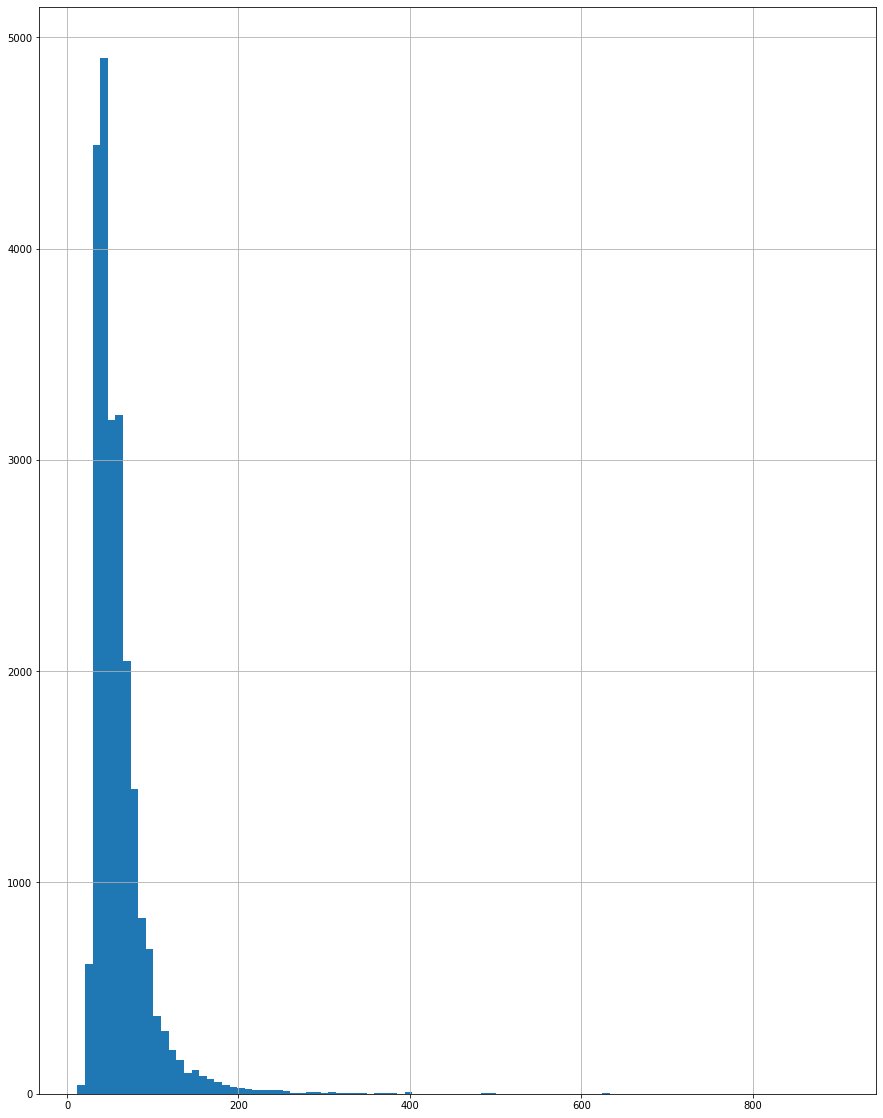

In [ ]:
data_research['total_area'].hist(figsize=(15,20), bins = 100, grid = True)

Гистограмма относительно "плавная" и "нормальная", достигающая пика в районе площади в 50 м². После около 250 стремится к нулю, с которым практически сливается, и "хвост" этот тянется еще долго.

На всякий случай глянем квартиры с самыми большими площадями, на случай ошибок внесения данных.

Ошибки, когда общая площадь была меньше суммы жилой и кухни мы уже исправили на предыдущем этапе.

In [ ]:
data_research[data_research['total_area'] >= 300.0]

,day_of_week,month,year,days_exposition,last_price,last_price_1000,price_per_meter,total_area,living_area,kitchen_area,rooms,ceiling_height,type_floor,floors_total,locality_name,city_centers_by_km,city_centers_nearest,parks,parks_nearest,ponds,ponds_nearest
155,4,7,2017,62.0,96000000,96000,302839.11,317.000000,183.000000,NaN,4,3.50,последний,3,Санкт-Петербург,1.770000,1771.0,True,508.0,True,366.0
578,0,3,2019,NaN,65000000,65000,178082.19,365.000000,NaN,NaN,7,2.90,последний,7,Санкт-Петербург,1.690000,1690.0,True,378.0,True,58.0
657,2,10,2017,391.0,49950000,49950,103223.80,483.899994,312.500000,26.4,7,3.20,другой,6,Санкт-Петербург,0.940000,945.0,True,461.0,True,22.0
789,1,5,2018,342.0,135000000,135000,435483.87,310.000000,250.000000,50.0,4,3.30,другой,5,Санкт-Петербург,7.250000,7251.0,True,295.0,True,190.0
862,5,12,2017,418.0,25000000,25000,68870.52,363.000000,222.000000,16.6,14,3.16,другой,5,Санкт-Петербург,7.950000,7950.0,False,NaN,True,435.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20802,3,3,2019,NaN,54000000,54000,180000.00,300.000000,170.000000,20.0,6,3.00,последний,5,Санкт-Петербург,5.500000,5509.0,False,NaN,False,NaN
21830,0,10,2017,161.0,130000000,130000,301624.12,431.000000,220.000000,20.0,7,3.70,другой,8,Санкт-Петербург,NaN,NaN,NaN,NaN,NaN,NaN
21865,5,9,2018,234.0,68000000,68000,182256.76,373.100006,176.199997,29.4,8,NaN,последний,8,Санкт-Петербург,7.870000,7873.0,True,562.0,True,691.0
22006,3,10,2018,NaN,27000000,27000,63950.73,422.200012,NaN,NaN,5,2.70,другой,13,Санкт-Петербург,16.549999,16554.0,False,NaN,False,NaN


Квартира с индексом 155 может содержать ошибку касательно жилой площади: квартира достаточно просторная, имеет четыре комнаты, и, пусть площадь кухни не указана, вряд ли она вместе с санузлом занимает оставшуюся площадь.

Остальные параметры отобранных квартир подтверждают их большую площадь, но все равно сами параметры выглядят некорректно

Странные "потери площадей" у строк 660, 866, 20919, 21955, 21990, 22494, и это только из  выведенной на экран части строк! Однако удалять мы их не будем (чтобы после проверки по каждому из параметров не остаться без данных), а просто не будем включать в дальнейшее ислледование по данномку столбцу.

Ввиду своей малочисленности, начения выше 300 не представляют интереса. Но для большей точности можем посмотреть на диаграмму размаха.

In [ ]:
data_research['total_area'].describe() # статистическое описание

count    23211.000000
mean        60.319279
std         35.737652
min         12.000000
25%         40.000000
50%         52.000000
75%         69.699997
max        900.000000
Name: total_area, dtype: float64

Среднее и медиана отличаются друг от друга на 8м², что существенно, когда сами значения составляют 52 и 60 соответственно (на среднее валияет длинный "хвост" из дорогих квартир), но меньше стандартного отклонения, чей размер превышает половину как среднего, так и медианы. Это также может быть влияние хвоста, а может в датафрейме прячутся еще какие-то незамеченные аномалии.     

<AxesSubplot:>

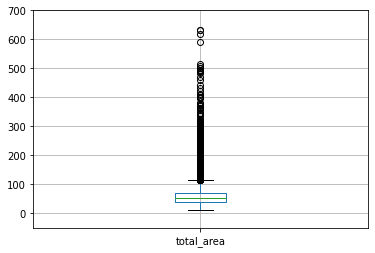

In [ ]:
plt.ylim(-50, 700)
data_research.boxplot(column=['total_area'])

Верхний ус межквартильного размаха и вовсе оказался ненамного выше сотни. Поэтому можно смело брать в будущее исследование строки с общей пощадью меньшей или равной 200 м².

***Вывод***

Самые "популярные" квартиры имеют общую площадь от 40 до 69 м².

Для дальнейшего исследования будем использовать строки со значением `<= 200` в столбце `'total_area'`.

#####  Жилая площадь

Построенная в самом начале гистрограмма столбца с жилой площадью `'living_area'` также черезвычайно длинна по оси x.

Присмотримся к ней получше, увеличив количество корзин.

<AxesSubplot:>

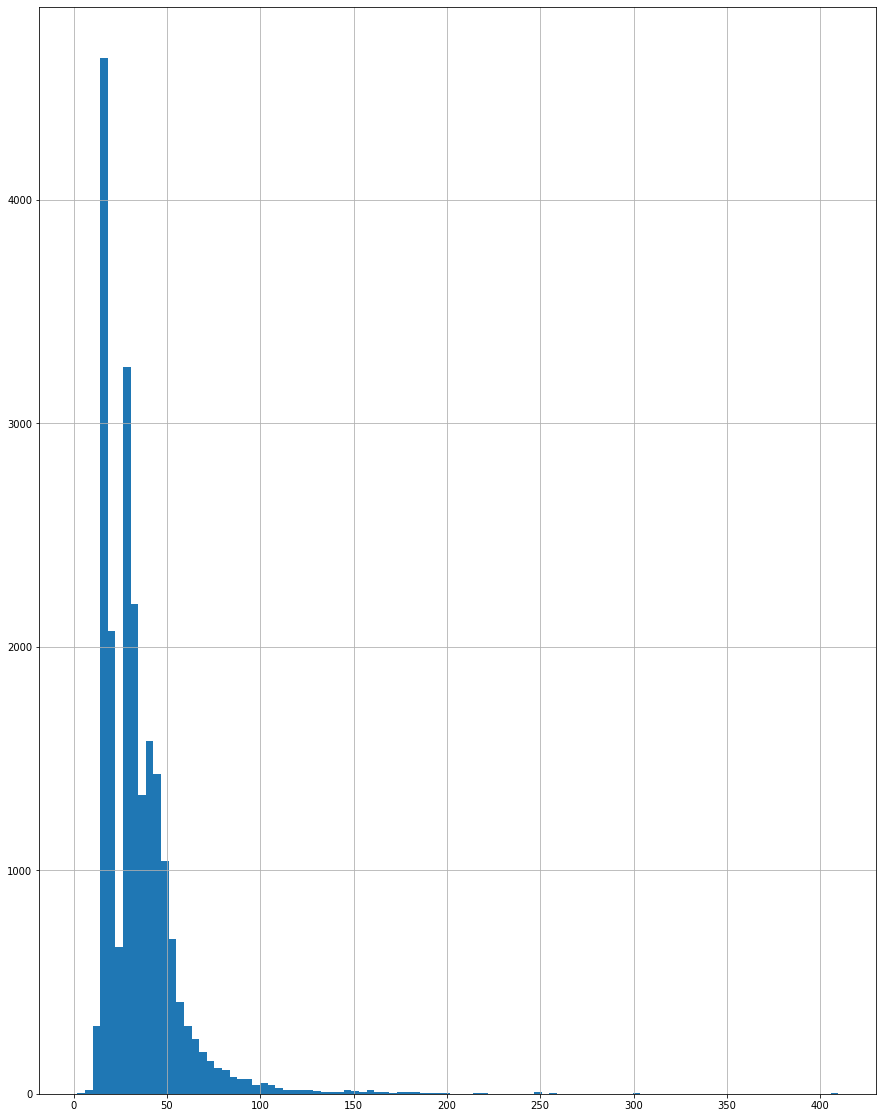

In [ ]:
data_research['living_area'].hist(figsize=(15,20), bins = 100, grid = True)

Имеется провал по значениям приблизительно около 25 м², "хвост" после приблизительно 125 м² и аномалии после 200 м².

Возможно провал частично связан с пропусками в данном столбце, чье количество составляет почти 8%. Но достаточно большое количество значений в области "провала" так же не дает возможность однозначно причислить их к аномалиям для последующего удаления.

Также проверим аномально большие значения площадей на предмет ошибок внесения данных.

In [ ]:
data_research[data_research['living_area'] >= 200.0]

,day_of_week,month,year,days_exposition,last_price,last_price_1000,price_per_meter,total_area,living_area,kitchen_area,rooms,ceiling_height,type_floor,floors_total,locality_name,city_centers_by_km,city_centers_nearest,parks,parks_nearest,ponds,ponds_nearest
657,2,10,2017,391.0,49950000,49950,103223.80,483.899994,312.500000,26.400000,7,3.20,другой,6,Санкт-Петербург,0.94,945.0,True,461.0,True,22.0
789,1,5,2018,342.0,135000000,135000,435483.87,310.000000,250.000000,50.000000,4,3.30,другой,5,Санкт-Петербург,7.25,7251.0,True,295.0,True,190.0
862,5,12,2017,418.0,25000000,25000,68870.52,363.000000,222.000000,16.600000,14,3.16,другой,5,Санкт-Петербург,7.95,7950.0,False,NaN,True,435.0
1081,0,7,2017,259.0,75000000,75000,232198.14,323.000000,255.699997,66.000000,5,4.00,другой,5,Санкт-Петербург,0.59,594.0,True,398.0,True,515.0
1489,1,11,2018,46.0,65000000,65000,178571.42,364.000000,250.000000,20.000000,7,3.90,другой,6,Санкт-Петербург,3.25,3254.0,False,NaN,True,689.0
2571,0,10,2017,406.0,30900000,30900,91258.12,338.600006,230.000000,20.000000,7,3.86,другой,6,Санкт-Петербург,5.64,5641.0,False,NaN,False,NaN
4216,5,10,2017,NaN,50000000,50000,96711.79,517.000000,332.000000,22.000000,7,NaN,другой,4,Санкт-Петербург,1.84,1847.0,True,477.0,True,540.0
5330,3,2,2019,14.0,65000000,65000,110169.49,590.000000,409.000000,100.000000,15,3.50,другой,6,Санкт-Петербург,4.66,4666.0,True,767.0,False,NaN
6188,6,1,2018,179.0,34000000,34000,72294.28,470.299988,248.699997,40.000000,4,NaN,последний,3,Санкт-Петербург,15.45,15459.0,True,852.0,True,122.0
6587,6,4,2017,351.0,99000000,99000,202868.85,488.000000,216.000000,50.000000,5,2.95,другой,20,Санкт-Петербург,4.59,4598.0,True,646.0,True,368.0


Остальные данные в строках подтвержают большую жилую площадь данного помещения. Однако в некоторых случах (например, строки 21830, 20160, 19431) жилая площадь выглядит меньше предпологаемой, учитывая разность между общей и кухней.

Попробуем узнать, какие данные нам можно исключить из исследования.

In [ ]:
data_research['living_area'].describe() # статистическое описание

count    21346.000000
mean        34.732922
std         22.090929
min          2.000000
25%         18.900000
50%         30.020000
75%         42.599998
max        409.700012
Name: living_area, dtype: float64

<AxesSubplot:>

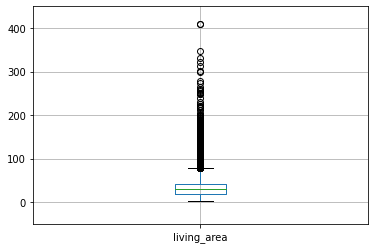

In [ ]:
plt.ylim(-50, 450)
data_research.boxplot(column=['living_area']) # диаграмма размаха

Медиана и средняя достаточно близки по значению (и даже меньше стандартного отклонения), и оба находятся как раз около "провала". Стандартное отклонение выглядит большим, подтверждая наличие вопросов к данным.

Верхний ус межквартильного размаха меньше сотни, находится где-то около 75. Для будущих исследований возьмем строки с жилой пощадью меньшей или равной 100 м².

***Вывод***

Самые "популярные" квартиры имеют жилую площадь от 18 до 42 м².

Для дальнейшего исследования будем использовать строки со значением `<= 100` в столбце `'living_area'`.

##### Площадь кухни

Как и две предыдущих площади, площадь кухни (столбец `'kitchen_area'`) имеет черезчур длинную ось x на гистограмме.

Строим новую, изменив количество корзин.

<AxesSubplot:>

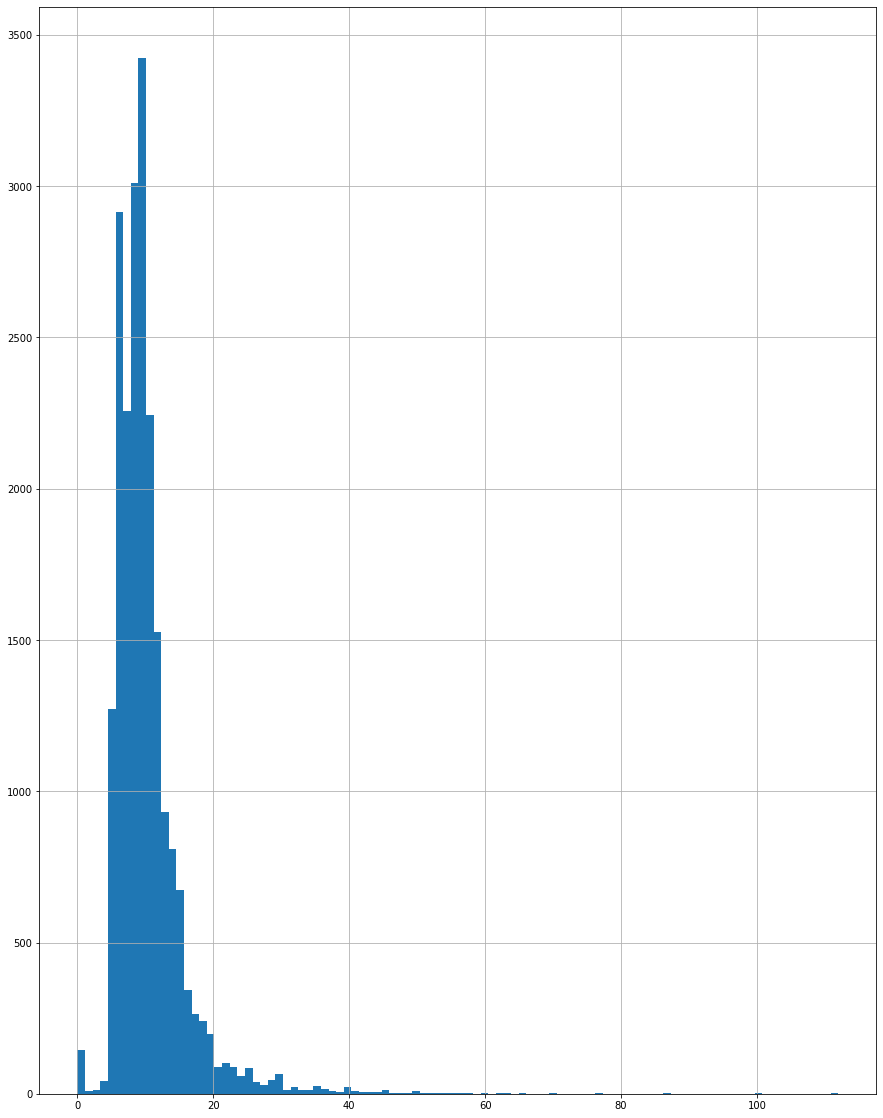

In [ ]:
data_research['kitchen_area'].hist(figsize=(15,20), bins = 100, grid = True)

Гистограмма имеет более скачущие ступеньки на спаде после 20 м² (гистограмма жилой площади на спаде более гладкая). Хвост гистограммы таже длиннее и аномальнее, имеются значения даже после 60 м² (при том, что у многих из квартир в датафрейме общая площадь меньше данного значения). А так же пик около ноля ("наследие" студий).

Также гистограмма площади кухни тоже имеет "провал в вершине" (или второй пик - как посмотреть), как и гистограмма жилой площади. Есть вероятность пропуска у них в одних и тех же строках.

In [ ]:
data_research.isna().sum() # общая информация о пропусках

day_of_week                 0
month                       0
year                        0
days_exposition          3120
last_price                  0
last_price_1000             0
price_per_meter             0
total_area                  0
living_area              1865
kitchen_area             2076
rooms                       0
ceiling_height           8938
type_floor                  0
floors_total                0
locality_name               0
city_centers_by_km       5433
city_centers_nearest     5433
parks                    5432
parks_nearest           15318
ponds                    5432
ponds_nearest           14348
dtype: int64

In [ ]:
data_research.dropna(subset=['kitchen_area']).isna().sum() # пропусках после удаления строк с пропусками в 'kitchen_area'

day_of_week                 0
month                       0
year                        0
days_exposition          2935
last_price                  0
last_price_1000             0
price_per_meter             0
total_area                  0
living_area               445
kitchen_area                0
rooms                       0
ceiling_height           7720
type_floor                  0
floors_total                0
locality_name               0
city_centers_by_km       4782
city_centers_nearest     4782
parks                    4781
parks_nearest           13888
ponds                    4781
ponds_nearest           13033
dtype: int64

Изначально было 2129 и 1903 строк с пропусками в столбце с площадью кухни и жилой площадью соотвественно. После удаления строк с пропусками касающимися площадей кухни, пропусков у жилой площади осталось только 449.

Выходит, что 68% строк с пропусками в столбце с площадью кухни имеют пропуски в столбце с жилой площадью.

Пиков и провалов на вершине много, так что их тоже нельзя отнести к выбросам и аномалиям. А вот в очередной раз "отрезать хвост" (ориентировочно после 60) можно.

Предварительно также проверим "хвосты" на ошибку введения.

In [ ]:
data_research[data_research['kitchen_area'] >= 50.0]

,day_of_week,month,year,days_exposition,last_price,last_price_1000,price_per_meter,total_area,living_area,kitchen_area,rooms,ceiling_height,type_floor,floors_total,locality_name,city_centers_by_km,city_centers_nearest,parks,parks_nearest,ponds,ponds_nearest
489,1,12,2017,14.0,95000000,95000,439814.81,216.000000,86.000000,77.000000,4,3.00,другой,5,Санкт-Петербург,0.430000,436.0,True,138.0,True,620.0
653,3,10,2018,53.0,18500000,18500,141221.37,131.000000,64.000000,50.000000,3,2.80,другой,20,Санкт-Петербург,8.670000,8672.0,True,139.0,False,NaN
789,1,5,2018,342.0,135000000,135000,435483.87,310.000000,250.000000,50.000000,4,3.30,другой,5,Санкт-Петербург,7.250000,7251.0,True,295.0,True,190.0
1022,4,10,2018,NaN,155000000,155000,500000.00,310.000000,190.000000,63.000000,5,5.30,последний,3,Санкт-Петербург,4.780000,4785.0,False,NaN,True,603.0
1081,0,7,2017,259.0,75000000,75000,232198.14,323.000000,255.699997,66.000000,5,4.00,другой,5,Санкт-Петербург,0.590000,594.0,True,398.0,True,515.0
2480,4,4,2017,102.0,12500000,12500,49019.60,255.000000,153.899994,100.699997,3,NaN,последний,2,Санкт-Петербург,6.910000,6916.0,False,NaN,True,198.0
3103,5,3,2019,NaN,140000000,140000,221870.04,631.000000,NaN,60.000000,7,NaN,последний,5,Санкт-Петербург,4.970000,4972.0,False,NaN,True,210.0
4373,0,11,2015,1039.0,57000000,57000,327586.20,174.000000,95.000000,77.000000,3,3.20,другой,10,Санкт-Петербург,4.160000,4166.0,True,193.0,True,199.0
5017,3,8,2017,15.0,35000000,35000,92105.26,380.000000,198.000000,50.000000,6,NaN,другой,3,Пушкин,30.639999,30643.0,True,527.0,True,668.0
5330,3,2,2019,14.0,65000000,65000,110169.49,590.000000,409.000000,100.000000,15,3.50,другой,6,Санкт-Петербург,4.660000,4666.0,True,767.0,False,NaN


Данные по общим площадям квартир и количеству комнат выглядят правдоподобно. А вот площадей комнат и кухни - не всегда (например, строки 19431 и 22849 выглядят так, будто кухням ошибочно приписали площадь одной из комнат). Однако установить правильные значения у нас не выйдет, поэтому скорее всего придется исключать их из исследования.

Посмотрим на данные распределения значений в данном столбце.

In [ ]:
data_research['kitchen_area'].describe()

count    21135.000000
mean        10.230765
std          5.373132
min          0.000000
25%          7.000000
50%          9.000000
75%         11.700000
max        112.000000
Name: kitchen_area, dtype: float64

Медиана и средние очень близко друг к другу, но среднее отклонение велико, что подтверждается провалом около главного пика гистограммы.

<AxesSubplot:>

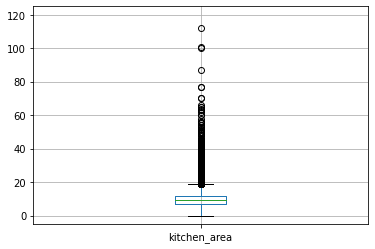

In [ ]:
plt.ylim(-5, 125)
data_research.boxplot(column=['kitchen_area'])

Нижний ус захватывает 0 как минимальное значение, верхний не достигает 25 м².

Посмотрим, как будет выглядеть гистограмма, если убрать "наследие студий".

<AxesSubplot:>

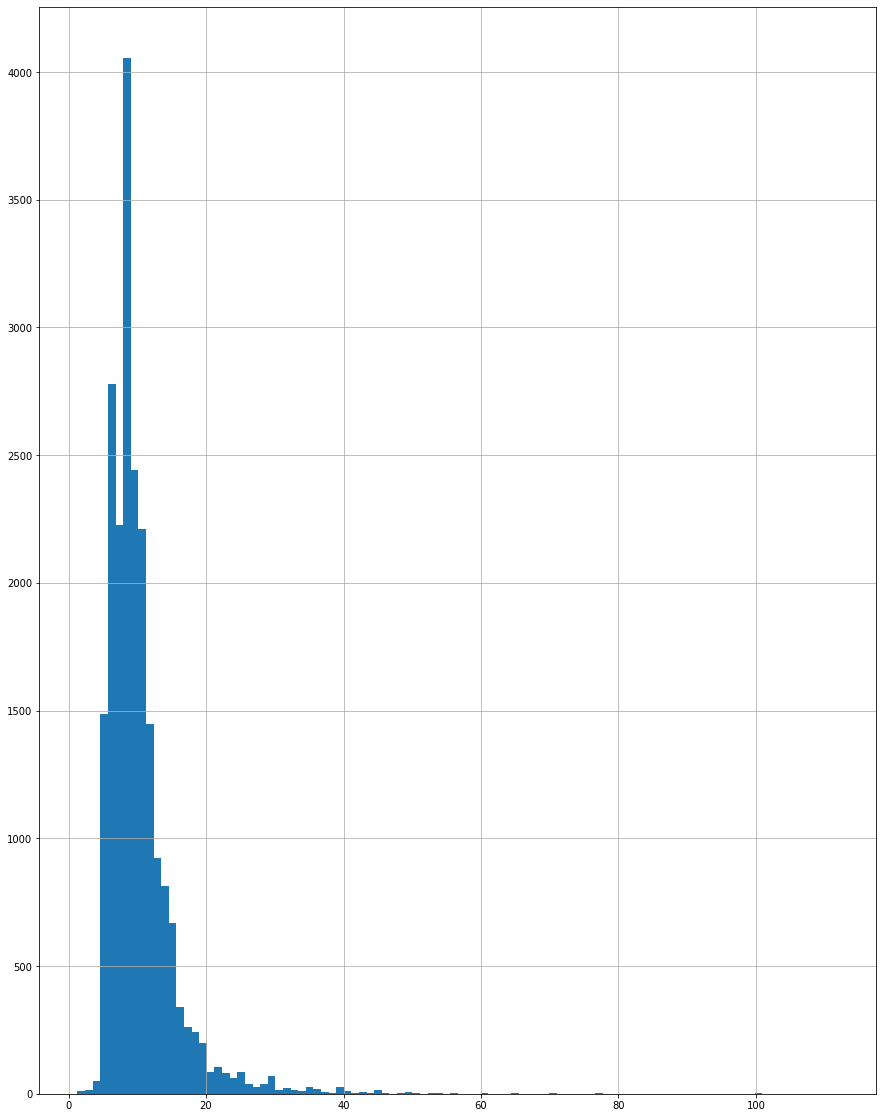

In [ ]:
data_research.drop(data_research.loc[data_research['kitchen_area'] == 0]
                   .index, axis = 0)['kitchen_area'].hist(figsize=(15,20), bins = 100, grid = True)

Центральный пик "подрос",перевалив за 4000 случаев, а ноль, что и требовалось, пропал. В остальном гистограммы отличаются несильно. Поэтому будем далее брать строки со значением больше ноля и меньше или равно 25.

***Вывод***

Самые "популярные" квартиры имеют площадь кухни от 7 до 11 м².

Для дальнейшего исследования будем использовать строки со значением `0<` и `<= 25` в столбце `'kitchen_area'`.

##### Цена объекта

Строим новую, более подробную, гистограмму для просмотра распределения цен. Для удобства будем использовать данные столбца `'last_price_1000'`.

<AxesSubplot:>

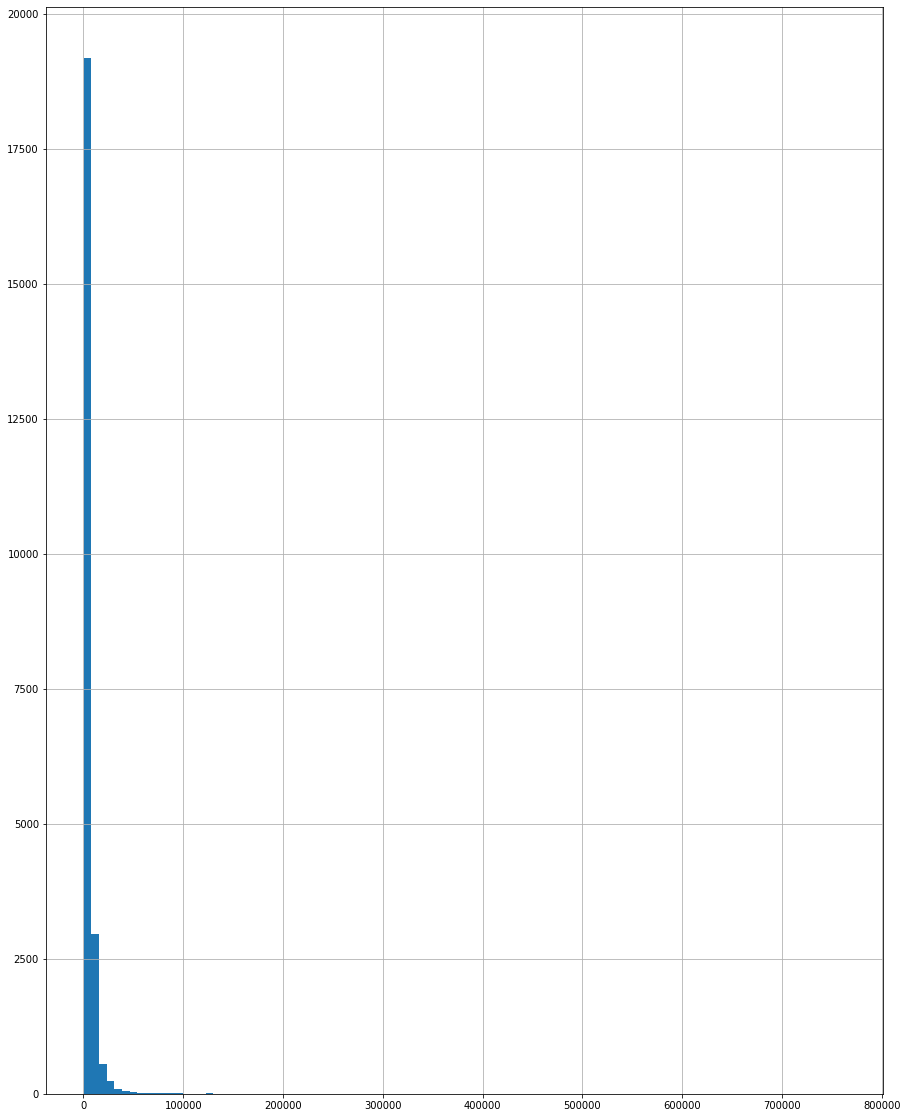

In [ ]:
data_research['last_price_1000'].hist(figsize=(15,20), bins = 100, grid = True)

Основная часть объектов находится до 100 млн, а после практически сходит на нет. Но хвост продолжается значительно дальше.

Посмотрим данные на предмет ошибок.

In [ ]:
data_research[data_research['last_price_1000'] >= 100000]

,day_of_week,month,year,days_exposition,last_price,last_price_1000,price_per_meter,total_area,living_area,kitchen_area,rooms,ceiling_height,type_floor,floors_total,locality_name,city_centers_by_km,city_centers_nearest,parks,parks_nearest,ponds,ponds_nearest
789,1,5,2018,342.0,135000000,135000,435483.87,310.000000,250.000000,50.000000,4,3.30,другой,5,Санкт-Петербург,7.25,7251.0,True,295.0,True,190.0
1022,4,10,2018,NaN,155000000,155000,500000.00,310.000000,190.000000,63.000000,5,5.30,последний,3,Санкт-Петербург,4.78,4785.0,False,NaN,True,603.0
1183,4,6,2018,316.0,118000000,118000,406056.42,290.600006,188.699997,22.000000,6,3.82,другой,6,Санкт-Петербург,6.22,6224.0,True,217.0,False,NaN
1295,3,7,2018,225.0,120000000,120000,428571.42,280.000000,162.000000,30.000000,5,4.70,другой,4,Санкт-Петербург,4.24,4247.0,True,464.0,True,339.0
1431,2,4,2018,233.0,330000000,330000,1736842.10,190.000000,95.000000,40.000000,3,3.50,другой,7,Санкт-Петербург,1.19,1197.0,True,519.0,True,285.0
1922,1,1,2017,174.0,125000000,125000,556792.87,224.500000,163.500000,30.000000,4,NaN,другой,4,Санкт-Петербург,2.33,2335.0,False,NaN,True,497.0
2235,4,7,2015,599.0,130278280,130278,428546.97,304.000000,NaN,NaN,5,3.11,другой,9,Санкт-Петербург,5.91,5913.0,True,164.0,False,NaN
2527,3,8,2015,501.0,159984000,159984,660000.01,242.399994,131.000000,20.000000,4,3.85,другой,9,Санкт-Петербург,2.24,2242.0,True,679.0,True,227.0
3103,5,3,2019,NaN,140000000,140000,221870.04,631.000000,NaN,60.000000,7,NaN,последний,5,Санкт-Петербург,4.97,4972.0,False,NaN,True,210.0
4971,3,10,2017,45.0,124000000,124000,995983.93,124.500000,67.199997,20.000000,4,3.00,другой,4,Санкт-Петербург,1.72,1722.0,True,302.0,True,172.0


Объект с индексом  22701 выглядит странно - большая цена для двухкомнатной квартиры, пусть и просторной, тем более - на последнем этаже, особенно в сравнении с тем, что за большую площадь и количество комнат даже в этой выборке аномалий просят меньше. Цена за метр также подтверждает, что это подозрительно. Может это влияние близости центра и природы вокруг, а может - ошибка данных. Узнать, какая цена была на самом деле, не представляется возможным, поэтому потенциально эта строка подлежит удалению из исследования. Да и часть жилых площадей у нее как будто утеряно (аналогичные "потери площадей", например, у строк 21023 и 20349, но по эти параметрам мы их уже отсекали ранее).

Аномально большая цена за метр замечена у строки с индексом 1436, корректные данные восстановить тут тоже не выйдет.

Также выбивается из ряда квартира в 12 комнат (индекс 19540), но она выглядит "настоящей"

Изучим данные распределения для данного столбца и посмотрим на диаграмму размаха.

In [ ]:
data_research['last_price_1000'].describe()

count     23211.000000
mean       6489.295248
std       10855.710478
min         430.000000
25%        3400.000000
50%        4600.000000
75%        6750.000000
max      763000.000000
Name: last_price_1000, dtype: float64

<AxesSubplot:>

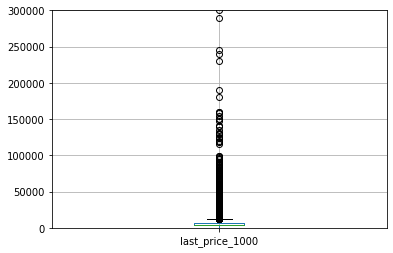

In [ ]:
plt.ylim(0, 300000)
data_research.boxplot(column=['last_price_1000'])

Медиана и среднее сильно отличаются друг от друга (на среднее явно влияют выбросы из хвоста), хотя и одного порядка. При этом стандартное отклонение велико, и уже относится к следующему порядку.

Стоимость квартир находится в пределах относительно небольшого (в сравнении с гистограммой) диапазона. То есть квартиры дороже 50 млн можно исключать из исследования.

***Вывод***

Наиболее частая цена квартир находится в диапазоне от 3.4 млн до 6.75 млн.

Для дальнейших иcследований будем использовать значения `'< 50000'` в столбце `'last_price_1000'`.

#####  Количество комнат

Теоретически, так как количество комнат - целое число, то большого разброса по вариантам значений быть не должно. И максимальное количество комнат также должно быть не очень велико (если, конечно, в выборку случайно не попали условные дворец, коммунальная квартира, общежитие или хостел).

Посмотрим на новую гистограмму.

<AxesSubplot:>

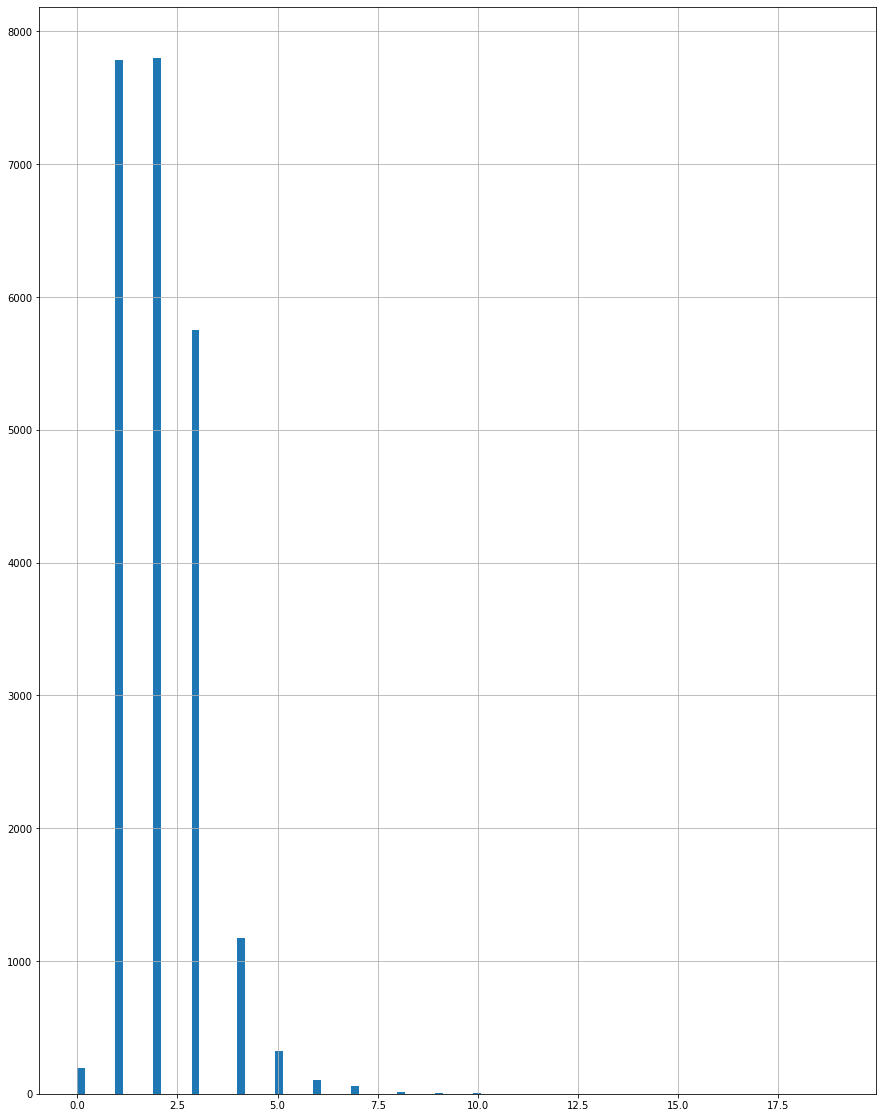

In [ ]:
data_research['rooms'].hist(figsize=(15,20), bins = 100, grid = True)

В целом гистограмма выглядит логичной: дробных значений нет и набор вариантов ограниченный.

Наиболее популярными выглядят квартиры с одной или двумя комнатами, реже встречаются три, четыре реже.

Однако пока не понятно, откуда взялись ноли, и что за многокомнатные помещения и сколько их у нас. Может, это ошибки при вводе?

Посмотрим на эти аномалии внимательней.

In [ ]:
data_research[data_research['rooms'] == 0]

,day_of_week,month,year,days_exposition,last_price,last_price_1000,price_per_meter,total_area,living_area,kitchen_area,rooms,ceiling_height,type_floor,floors_total,locality_name,city_centers_by_km,city_centers_nearest,parks,parks_nearest,ponds,ponds_nearest
144,3,3,2017,181.0,2450000,2450,90740.74,27.000000,15.500000,0.0,0,NaN,другой,24,поселок Мурино,NaN,NaN,NaN,NaN,NaN,NaN
347,2,9,2017,45.0,2320000,2320,92800.00,25.000000,17.000000,NaN,0,NaN,первый,14,деревня Кудрово,NaN,NaN,NaN,NaN,NaN,NaN
438,0,3,2018,64.0,2480000,2480,91479.15,27.110001,24.750000,0.0,0,NaN,другой,17,Санкт-Петербург,15.010000,15015.0,False,NaN,True,982.0
505,1,3,2017,430.0,3375000,3375,98110.46,34.400002,24.299999,NaN,0,NaN,другой,26,поселок Парголово,19.290001,19292.0,False,NaN,True,593.0
605,2,2,2019,29.0,1850000,1850,74000.00,25.000000,NaN,0.0,0,NaN,другой,10,поселок Шушары,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23079,4,9,2017,14.0,3200000,3200,123076.92,26.000000,18.000000,0.0,0,NaN,другой,25,Санкт-Петербург,13.220000,13222.0,False,NaN,True,623.0
23310,3,9,2017,4.0,2500000,2500,90252.70,27.700001,18.000000,NaN,0,NaN,другой,24,поселок Мурино,NaN,NaN,NaN,NaN,NaN,NaN
23422,4,9,2018,31.0,3350000,3350,128846.15,26.000000,NaN,0.0,0,NaN,другой,19,Санкт-Петербург,17.090000,17092.0,False,NaN,True,112.0
23459,5,11,2017,82.0,1450000,1450,50000.00,29.000000,18.000000,NaN,0,NaN,другой,9,Никольское,NaN,NaN,NaN,NaN,NaN,NaN


Судя по нулевой площади кухонь у некоторых квартир - часть из них являются студиями (но строк с нулем комнат больше, чем у нас было строк со студиями). А с точки зрения логики не может быть 0 комнат (да и откуда тогда взяться жилой?). Квартиры в видимой части датафрейма небольшие, так что вероятнее всего это на само деле одна комната.

Исправим 0 на 1.

In [ ]:
data_research.loc[data_research['rooms'] == 0, 'rooms'] = 1

Посмотрим на квартиры с более чем 8 комнатами.

In [ ]:
data_research[data_research['rooms'] >= 8]

,day_of_week,month,year,days_exposition,last_price,last_price_1000,price_per_meter,total_area,living_area,kitchen_area,rooms,ceiling_height,type_floor,floors_total,locality_name,city_centers_by_km,city_centers_nearest,parks,parks_nearest,ponds,ponds_nearest
645,6,7,2018,NaN,17500000,17500,95264.01,183.699997,138.800003,13.300000,11,3.40,последний,7,Санкт-Петербург,3.140000,3148.0,False,NaN,False,NaN
809,3,2,2016,806.0,16500000,16500,72052.40,229.000000,160.000000,25.000000,8,NaN,другой,6,Санкт-Петербург,4.530000,4536.0,True,243.0,False,NaN
862,5,12,2017,418.0,25000000,25000,68870.52,363.000000,222.000000,16.600000,14,3.16,другой,5,Санкт-Петербург,7.950000,7950.0,False,NaN,True,435.0
4130,3,1,2018,NaN,23000000,23000,84372.70,272.600006,145.899994,18.799999,10,3.14,последний,7,Санкт-Петербург,12.160000,12169.0,True,191.0,True,531.0
4414,1,12,2017,115.0,22190000,22190,116056.48,191.199997,115.800003,5.000000,8,2.90,первый,6,Санкт-Петербург,1.150000,1152.0,True,587.0,True,155.0
5330,3,2,2019,14.0,65000000,65000,110169.49,590.000000,409.000000,100.000000,15,3.50,другой,6,Санкт-Петербург,4.660000,4666.0,True,767.0,False,NaN
7817,2,10,2017,135.0,150000000,150000,652173.91,230.000000,220.000000,NaN,8,NaN,последний,8,Санкт-Петербург,5.840000,5845.0,True,116.0,False,NaN
8715,1,7,2018,NaN,16100000,16100,107333.33,150.000000,107.000000,7.200000,8,2.92,первый,5,Санкт-Петербург,4.780000,4782.0,True,473.0,False,NaN
8779,2,7,2017,471.0,49968900,49968,125550.00,398.000000,160.100006,41.000000,9,3.00,первый,2,Санкт-Петербург,16.719999,16722.0,True,471.0,True,440.0
8817,5,7,2018,90.0,17000000,17000,72340.42,235.000000,NaN,NaN,9,3.00,другой,6,Санкт-Петербург,5.030000,5034.0,True,346.0,False,NaN


С учетом оставшихся параметров квартир количество в 14, 16 и 19 комнат для строк 20712, 18744 и 14414 соответственно выглядит нереалистично. Похоже, на самом деле это 4, 6 и 9.

Исправим ситуацию.

In [ ]:
data_research.loc[data_research['rooms'] == 14, 'rooms'] = 4

In [ ]:
data_research.loc[data_research['rooms'] == 16, 'rooms'] = 6

In [ ]:
data_research.loc[data_research['rooms'] == 19, 'rooms'] = 9

Посмотрим обновленную гистограмму.

<AxesSubplot:>

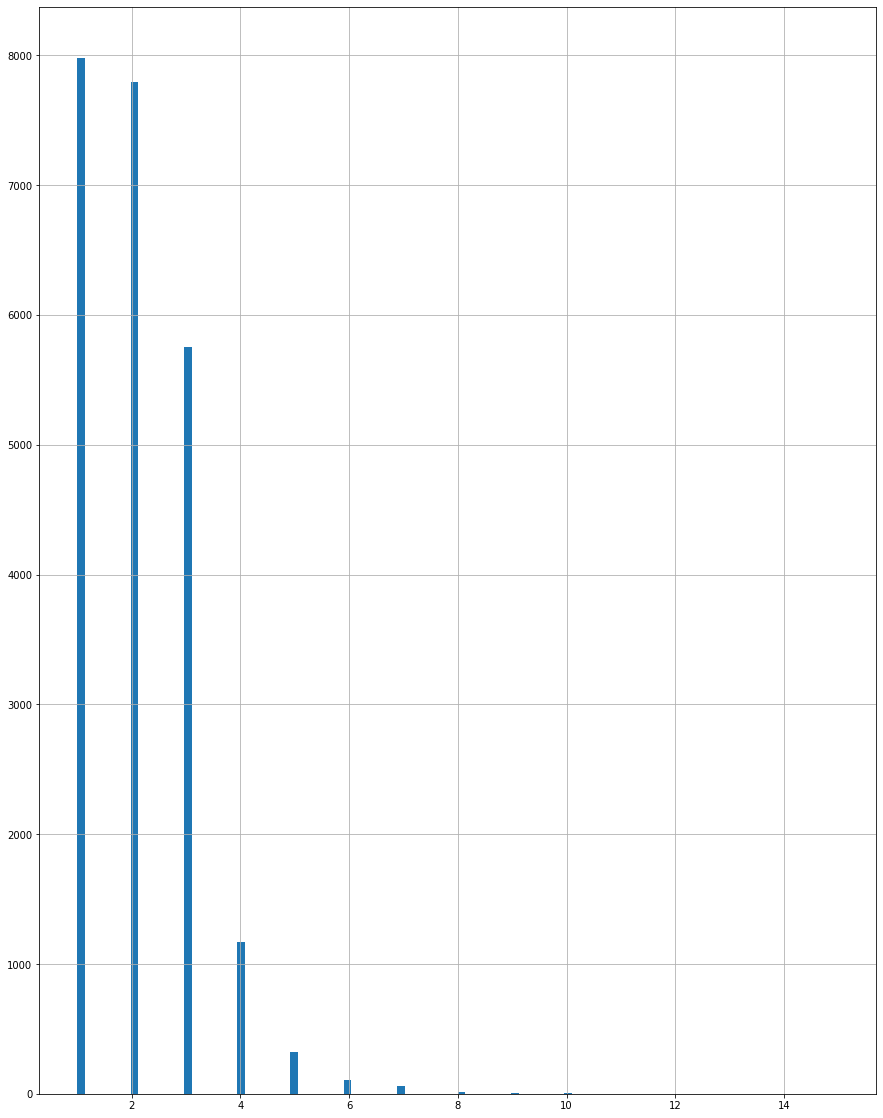

In [ ]:
data_research['rooms'].hist(figsize=(15,20), bins = 100, grid = True)

Выглядит уже получше - хвост сократился и ушли ноли.

Четко просматривается тенденция, чтоб чем больше комнат - тем меньше таких квартир на рынке.

Посмотрим описание и посмотрим диаграмму размаха.

In [ ]:
data_research['rooms'].describe()

count    23211.000000
mean         2.086511
std          1.054652
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         15.000000
Name: rooms, dtype: float64

<AxesSubplot:>

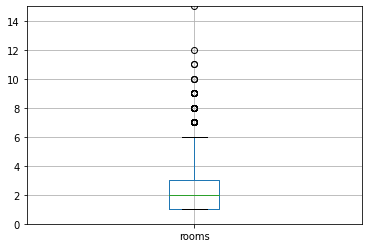

In [ ]:
plt.ylim(0, 15)
data_research.boxplot(column=['rooms'])

Средняя и медиана совпали, стандартное отклонение тоже выглядит нормальным.

С точки зрения диаграммы размаха, можно смело отсекать данные больше 6. Таких квартир немного, поэтому влияния на исследования они оказать не должны.

***Вывод***

Чаще всего встречаются кваартиры одной или двумя комнатами, чуть реже - с тремя.

В дальнейших исследованиях используем строки со значением `'<= 6'` в столбце `'rooms'`.

##### Высота потолков

Изучим гистрограмму более внимательно.

<AxesSubplot:>

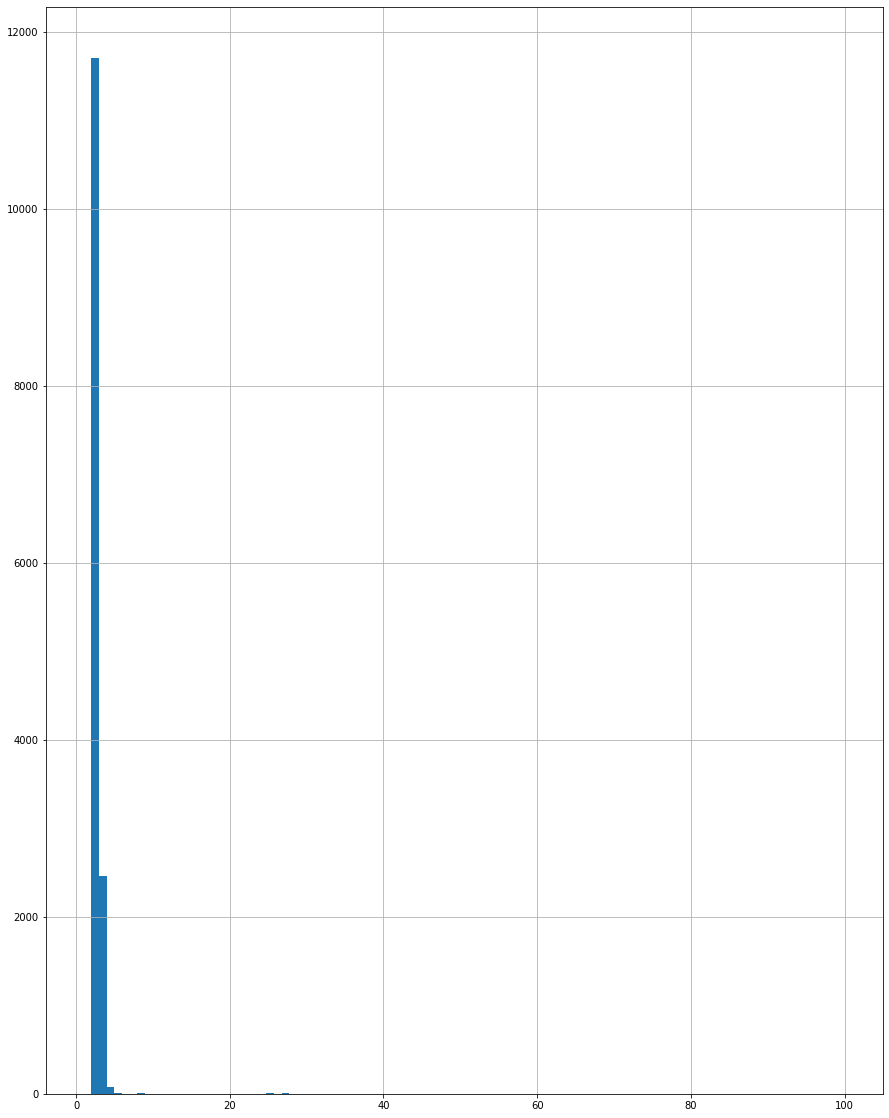

In [ ]:
data_research['ceiling_height'].hist(figsize=(15,20), bins = 100, grid = True)

После приблизительно 5-6 метров значения единичны, но видны значения 10, и даже между 2-30 метрами. А с учетом того, что гистограмма взяла себе значения по x превышающие 100, то где-то там тоже может прятаться аномалия.

In [ ]:
sorted(data_research['ceiling_height'].unique()) # смотрим варианты значений

[1.0,
 2.0,
 2.3,
 2.4,
 2.45,
 2.46,
 2.48,
 2.53,
 2.62,
 2.63,
 2.7,
 nan,
 1.2,
 1.75,
 2.2,
 2.25,
 2.34,
 2.47,
 2.49,
 2.5,
 2.51,
 2.52,
 2.54,
 2.55,
 2.56,
 2.57,
 2.58,
 2.59,
 2.6,
 2.61,
 2.64,
 2.65,
 2.66,
 2.67,
 2.68,
 2.69,
 2.71,
 2.72,
 2.73,
 2.74,
 2.75,
 2.76,
 2.77,
 2.78,
 2.79,
 2.8,
 2.81,
 2.82,
 2.83,
 2.84,
 2.85,
 2.86,
 2.87,
 2.88,
 2.89,
 2.9,
 2.91,
 2.92,
 2.93,
 2.94,
 2.95,
 2.96,
 2.97,
 2.98,
 2.99,
 3.0,
 3.01,
 3.02,
 3.03,
 3.04,
 3.05,
 3.06,
 3.07,
 3.08,
 3.09,
 3.1,
 3.11,
 3.12,
 3.13,
 3.14,
 3.15,
 3.16,
 3.17,
 3.18,
 3.2,
 3.21,
 3.22,
 3.23,
 3.24,
 3.25,
 3.26,
 3.27,
 3.28,
 3.29,
 3.3,
 3.31,
 3.32,
 3.33,
 3.34,
 3.35,
 3.36,
 3.37,
 3.38,
 3.39,
 3.4,
 3.42,
 3.43,
 3.44,
 3.45,
 3.46,
 3.47,
 3.48,
 3.49,
 3.5,
 3.51,
 3.52,
 3.53,
 3.54,
 3.55,
 3.56,
 3.57,
 3.58,
 3.59,
 3.6,
 3.62,
 3.63,
 3.65,
 3.66,
 3.67,
 3.69,
 3.7,
 3.75,
 3.76,
 3.78,
 3.8,
 3.82,
 3.83,
 3.84,
 3.85,
 3.86,
 3.87,
 3.88,
 3.9,
 3.93,
 3.95,
 3.98,


In [ ]:
data_research[data_research['ceiling_height'] >= 5.0].sort_values(by='ceiling_height')

,day_of_week,month,year,days_exposition,last_price,last_price_1000,price_per_meter,total_area,living_area,kitchen_area,rooms,ceiling_height,type_floor,floors_total,locality_name,city_centers_by_km,city_centers_nearest,parks,parks_nearest,ponds,ponds_nearest
1049,3,2,2018,6.0,550000,550,18965.51,29.000000,NaN,NaN,1,5.0,первый,3,Бокситогорск,NaN,NaN,NaN,NaN,NaN,NaN
461,3,6,2015,578.0,66571000,66571,237499.11,280.299988,159.500000,21.1,6,5.2,другой,8,Санкт-Петербург,6.650000,6655.0,True,187.0,True,616.0
12557,3,3,2018,8.0,3900000,3900,78000.00,50.000000,NaN,NaN,1,5.3,последний,5,Санкт-Петербург,3.910000,3918.0,True,505.0,True,92.0
1022,4,10,2018,NaN,155000000,155000,500000.00,310.000000,190.000000,63.0,5,5.3,последний,3,Санкт-Петербург,4.780000,4785.0,False,NaN,True,603.0
7540,3,11,2017,NaN,38000000,38000,265734.26,143.000000,83.000000,29.0,3,5.5,последний,5,Санкт-Петербург,6.440000,6448.0,True,479.0,False,NaN
1383,2,1,2015,719.0,59800000,59800,149874.68,399.000000,NaN,NaN,5,5.6,последний,6,Санкт-Петербург,6.930000,6934.0,True,149.0,True,577.0
21109,4,7,2017,30.0,8200000,8200,115492.95,71.000000,68.000000,0.0,1,5.8,последний,5,Санкт-Петербург,1.260000,1261.0,True,295.0,True,366.0
20151,0,7,2017,259.0,119000000,119000,634328.33,187.600006,147.000000,15.6,4,6.0,последний,7,Санкт-Петербург,5.600000,5605.0,True,484.0,True,305.0
3459,4,3,2018,125.0,1400000,1400,46666.66,30.000000,15.300000,7.3,1,8.0,другой,5,деревня Нурма,NaN,NaN,NaN,NaN,NaN,NaN
15656,4,11,2016,474.0,5600000,5600,83582.08,67.000000,41.000000,8.0,3,8.0,первый,16,Санкт-Петербург,11.030000,11035.0,True,723.0,False,NaN


Высота 5 и более метров смотрится странно, и больше похожа на ошибку, как будто была указана площадь одного из помещений квартиры вместо высоты потолков (там где слишком большая разница между общей площадью и суммой жилой и кухонной площадей) или номер этажа (например, строка 3459 или 22739, причем во втором случае лишний ноль).

К счастью, таких квартир немного. Некоторые данные можно исправить (например, 32 на 3.2), от остальных придется отказаться при исследовании. Строку потолка в 100 метров теоретически можно и вовсе удалить.

Обычно высота потолков составляет не менее 2,5 метров, но в датафрейме встречается и меньшая высота. Посмотрим на квартиры с меньшим потолком.

In [ ]:
data_research[data_research['ceiling_height'] <= 2.0].sort_values(by='ceiling_height')

,day_of_week,month,year,days_exposition,last_price,last_price_1000,price_per_meter,total_area,living_area,kitchen_area,rooms,ceiling_height,type_floor,floors_total,locality_name,city_centers_by_km,city_centers_nearest,parks,parks_nearest,ponds,ponds_nearest
22463,2,10,2018,13.0,6000000,6000,109090.90,55.000000,32.400002,10.00,2,1.00,другой,12,Санкт-Петербург,14.210000,14217.0,True,293.0,True,289.0
5683,0,8,2017,248.0,1500000,1500,35046.72,42.799999,27.500000,5.20,2,1.20,первый,2,поселок Мга,NaN,NaN,NaN,NaN,NaN,NaN
16837,1,10,2017,71.0,4100000,4100,102500.00,40.000000,17.400000,8.34,1,1.75,другой,37,Санкт-Петербург,20.440001,20444.0,False,NaN,True,80.0
549,3,3,2017,270.0,2999000,2999,89522.38,33.500000,17.500000,6.50,1,2.00,другой,15,Санкт-Петербург,11.740000,11746.0,True,520.0,True,949.0
2563,3,12,2018,NaN,2400000,2400,38709.67,62.000000,40.000000,6.00,3,2.00,другой,5,Луга,NaN,NaN,NaN,NaN,NaN,NaN
4191,0,12,2017,36.0,2120000,2120,59836.29,35.430000,16.600000,8.80,1,2.00,другой,18,Тосно,NaN,NaN,NaN,NaN,NaN,NaN
5820,1,5,2018,100.0,1650000,1650,46478.87,35.500000,NaN,NaN,1,2.00,последний,5,Луга,NaN,NaN,NaN,NaN,NaN,NaN
11286,6,6,2017,53.0,3300000,3300,91666.66,36.000000,15.200000,10.10,1,2.00,другой,17,поселок Металлострой,26.980000,26980.0,False,NaN,False,NaN
16357,1,3,2019,NaN,12300000,12300,139297.84,88.300003,63.900002,12.00,3,2.00,другой,5,Санкт-Петербург,7.670000,7675.0,True,568.0,True,154.0
16787,2,10,2018,6.0,1500000,1500,45454.54,33.000000,20.000000,6.00,1,2.00,последний,5,Выборг,NaN,NaN,NaN,NaN,NaN,NaN


Высота потолков от одного до двух метров выглядит странно и неправдоподобно. К счастью, таких столбцов немного. Потенциально их следует исключить из исследования.

Внесем возможные исправления.

In [ ]:
data_research.drop(data_research.loc[data_research['ceiling_height'] == 100]
                   .index, axis = 0, inplace = True) # удаление аномальной строки

In [ ]:
# корректируем высоту
data_research.loc[data_research['ceiling_height'] >= 20, 'ceiling_height'] = data_research['ceiling_height']/10

In [ ]:
data_research[(data_research['ceiling_height'] <=2.0)|(data_research['ceiling_height'] >= 5.0)]\
.sort_values(by='ceiling_height') # проверяем изменения

,day_of_week,month,year,days_exposition,last_price,last_price_1000,price_per_meter,total_area,living_area,kitchen_area,rooms,ceiling_height,type_floor,floors_total,locality_name,city_centers_by_km,city_centers_nearest,parks,parks_nearest,ponds,ponds_nearest
22463,2,10,2018,13.0,6000000,6000,109090.90,55.000000,32.400002,10.00,2,1.00,другой,12,Санкт-Петербург,14.210000,14217.0,True,293.0,True,289.0
5683,0,8,2017,248.0,1500000,1500,35046.72,42.799999,27.500000,5.20,2,1.20,первый,2,поселок Мга,NaN,NaN,NaN,NaN,NaN,NaN
16837,1,10,2017,71.0,4100000,4100,102500.00,40.000000,17.400000,8.34,1,1.75,другой,37,Санкт-Петербург,20.440001,20444.0,False,NaN,True,80.0
22829,3,10,2018,NaN,2300000,2300,42910.44,53.599998,19.000000,10.00,2,2.00,первый,2,Всеволожск,NaN,NaN,NaN,NaN,NaN,NaN
549,3,3,2017,270.0,2999000,2999,89522.38,33.500000,17.500000,6.50,1,2.00,другой,15,Санкт-Петербург,11.740000,11746.0,True,520.0,True,949.0
20406,3,7,2018,62.0,3600000,3600,94736.84,38.000000,15.000000,11.80,1,2.00,другой,12,Кудрово,NaN,NaN,NaN,NaN,NaN,NaN
19222,6,7,2018,45.0,1700000,1700,42500.00,40.000000,NaN,NaN,2,2.00,другой,9,Сосновый Бор,NaN,NaN,NaN,NaN,NaN,NaN
2563,3,12,2018,NaN,2400000,2400,38709.67,62.000000,40.000000,6.00,3,2.00,другой,5,Луга,NaN,NaN,NaN,NaN,NaN,NaN
18992,6,2,2018,282.0,2700000,2700,48214.28,56.000000,46.000000,6.00,3,2.00,первый,5,Выборг,NaN,NaN,NaN,NaN,NaN,NaN
4191,0,12,2017,36.0,2120000,2120,59836.29,35.430000,16.600000,8.80,1,2.00,другой,18,Тосно,NaN,NaN,NaN,NaN,NaN,NaN


Да, у нас еще остались аномальные значения. Но их уже не так много.

Попробуем узнать, какие данные нам можно исключить из исследования.

In [ ]:
data_research['ceiling_height'].describe()

count    14272.000000
mean         2.726785
std          0.313914
min          1.000000
25%          2.500000
50%          2.650000
75%          2.800000
max         14.000000
Name: ceiling_height, dtype: float64

<AxesSubplot:>

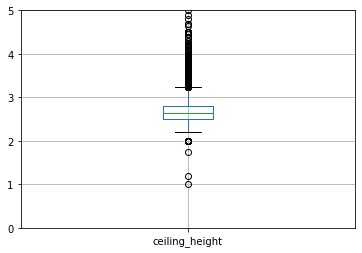

In [ ]:
plt.ylim(0, 5)
data_research.boxplot(column=['ceiling_height'])

Медиана и среднее довольно близки. Стандартное отклонение невелико.

Большинство вариантов высоты потолков находится в диапазоне от более двух до менее трех метров.

***Выводы***

Чаще всего полоки имеют высоту от 2.5 до 2.8 метров.

Для последующих исследований лучше использовать значения столбца `'ceiling_height'` в диапазоне  от `'2 >'` до `'< 3'`

##### Тип этажа квартиры

Изучим гистограмму.

<AxesSubplot:>

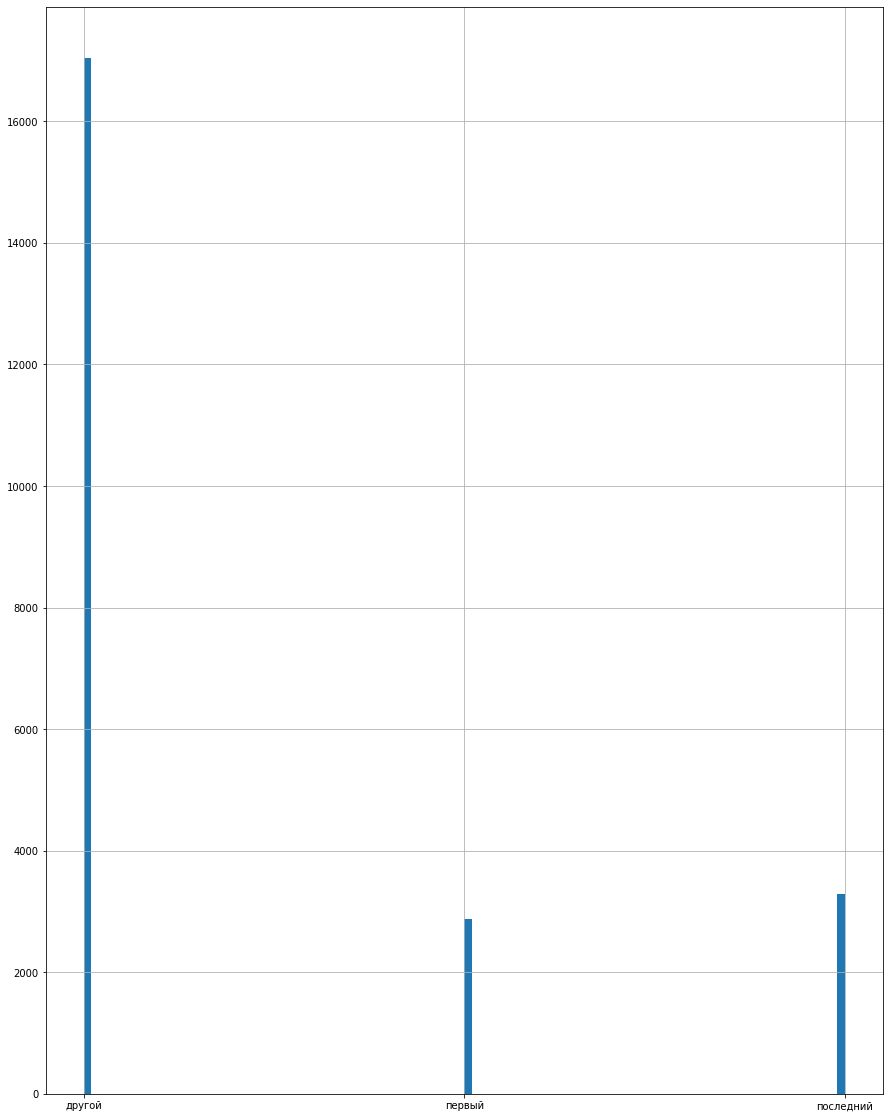

In [ ]:
data_research['type_floor'].hist(figsize=(15,20), bins = 100, grid = True)

Этажей типа "другой" гораздо больше, чем первых и последних, что логично.

***Выводы***

Этажей типа "другой" гораздо больше, чем первых и последних.

В исследованиях нам пригодятся все данные столбца `'type_floor'`.

##### Общее количество этажей в доме

Изучим гистограмму.

<AxesSubplot:>

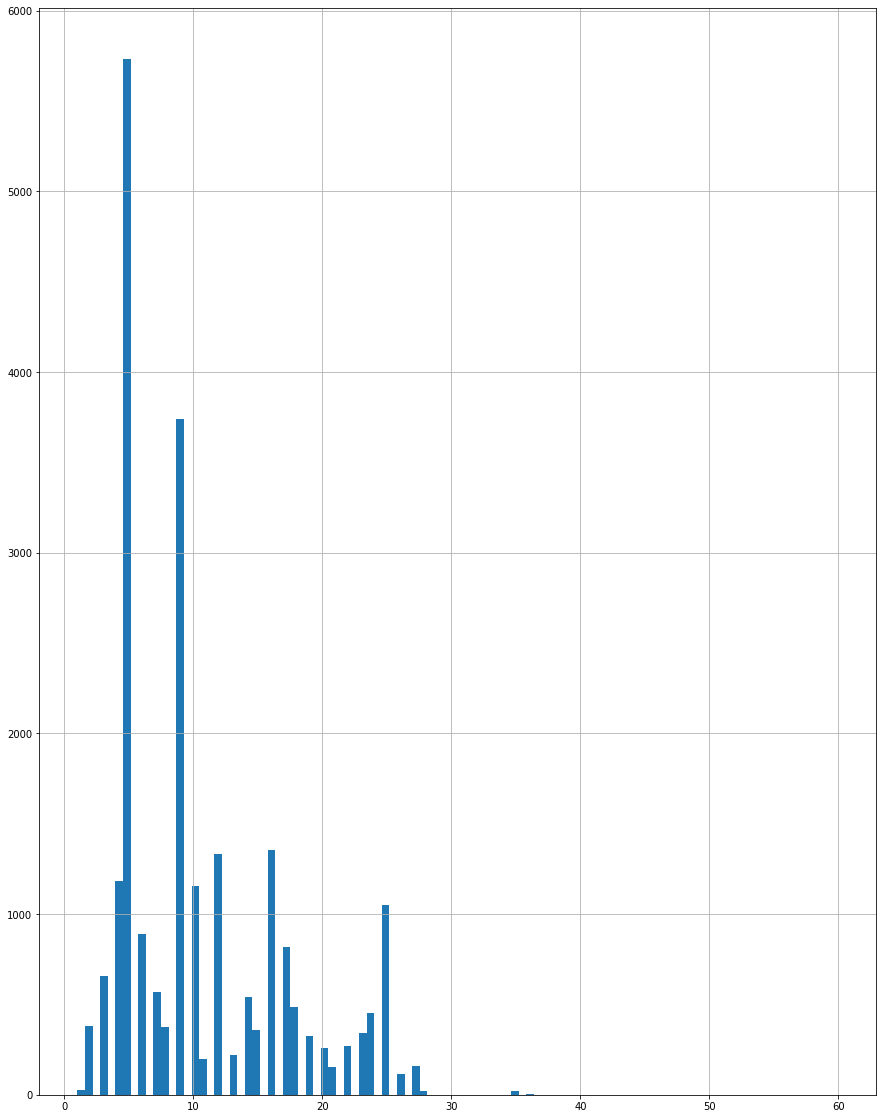

In [ ]:
data_research['floors_total'].hist(figsize=(15,20), bins = 100, grid = True)

Лидерами по количеству являются пятиэтажки. Также большое количество девятиэтажек.

Несмотря на то, что основной массив лежит до 30 и есть небольшой всплеск между 30 и 40, гистограмма продолжается дальше.

Посмотрим на высотки.

In [ ]:
data_research[data_research['floors_total'] > 30]

,day_of_week,month,year,days_exposition,last_price,last_price_1000,price_per_meter,total_area,living_area,kitchen_area,rooms,ceiling_height,type_floor,floors_total,locality_name,city_centers_by_km,city_centers_nearest,parks,parks_nearest,ponds,ponds_nearest
395,3,3,2018,11.0,5990000,5990,110925.92,54.000000,21.400000,18.700001,2,NaN,другой,36,Санкт-Петербург,20.440001,20444.0,False,NaN,True,80.0
867,3,11,2017,169.0,7777777,7777,103703.69,75.000000,40.500000,11.700000,2,NaN,другой,35,Санкт-Петербург,20.440001,20444.0,False,NaN,True,80.0
1056,4,11,2015,281.0,5200000,5200,104000.00,50.000000,39.000000,20.500000,2,NaN,другой,35,Санкт-Петербург,20.440001,20444.0,False,NaN,True,80.0
1692,3,2,2018,410.0,3550000,3550,126785.71,28.000000,18.000000,NaN,1,2.65,другой,34,Санкт-Петербург,20.440001,20444.0,False,NaN,True,80.0
1911,4,11,2017,NaN,10150000,10150,137162.16,74.000000,34.400002,13.000000,2,2.80,другой,35,Санкт-Петербург,20.440001,20444.0,False,NaN,True,80.0
2245,3,6,2018,166.0,3800000,3800,83516.48,45.500000,27.400000,7.400000,2,2.88,другой,60,Кронштадт,49.480000,49488.0,True,342.0,True,614.0
2953,1,8,2017,50.0,4300000,4300,116216.21,37.000000,14.000000,10.400000,1,NaN,другой,35,Санкт-Петербург,20.440001,20444.0,False,NaN,True,80.0
4831,3,6,2017,537.0,5500000,5500,110000.00,50.000000,22.000000,13.000000,1,2.80,другой,35,Санкт-Петербург,20.330000,20339.0,True,609.0,True,145.0
5720,2,8,2017,198.0,3590000,3590,143600.00,25.000000,NaN,NaN,1,2.80,другой,35,Санкт-Петербург,20.440001,20444.0,False,NaN,True,80.0
5777,2,1,2019,38.0,8150000,8150,101875.00,80.000000,41.000000,12.000000,2,2.70,другой,36,Санкт-Петербург,20.440001,20444.0,False,NaN,True,80.0


Из этих строк выбивается только 2245. Судя по одинаковому населенному пункту, почти у всех одинаковое расстояние до центра и этажей в доме - это группа зданий от 33 до 36 этажей рядом друг с другом в 20.33-20.44 км от центра Санкт-Петербурга.

В теории, можно из интереса посмтреть зависимости в этой конкретной группе. А вот для остального исследования она не подойдет.

Но и в этой группе выбивается строка с индексом 867 - своей ценой (все цифры одинаковые, и без нолей, а ведь никто не будет указывать "некруглую" цену квартиры). Похоже на ошибку, которую необходимо исключить из исследования (а может - и из датафрейма в целом).

In [ ]:
data_research['floors_total'].describe()

count    23210.000000
mean        10.629987
std          6.570742
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64

Среднее и медиана близки друг к другу, но при этом тяготеют к девяти, хотя "лидеры гистограммы" - пятиэтажки.

Этажность зданий и их распространенность не являются случайными величинами - решение принимали люди, и есть типовые высоты.  Поэтому и гистограмма для общей этажности так же не может быть близка к нормальной.

<AxesSubplot:>

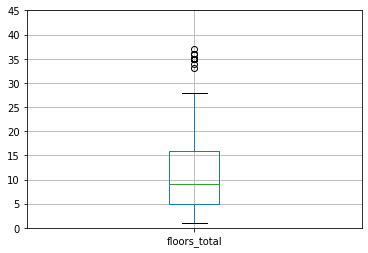

In [ ]:
plt.ylim(0, 45)
data_research.boxplot(column=['floors_total'])

***Выводы***

Основная часть зданий имеют высоту 5 этажей, но 9 тоже популярный формат.

Для дальнейшего исследования мы возьмем значения `'< 30'` в столбце `'floors_total'`

##### Расстояние до центра города в метрах

Изучим гистограмму.

<AxesSubplot:>

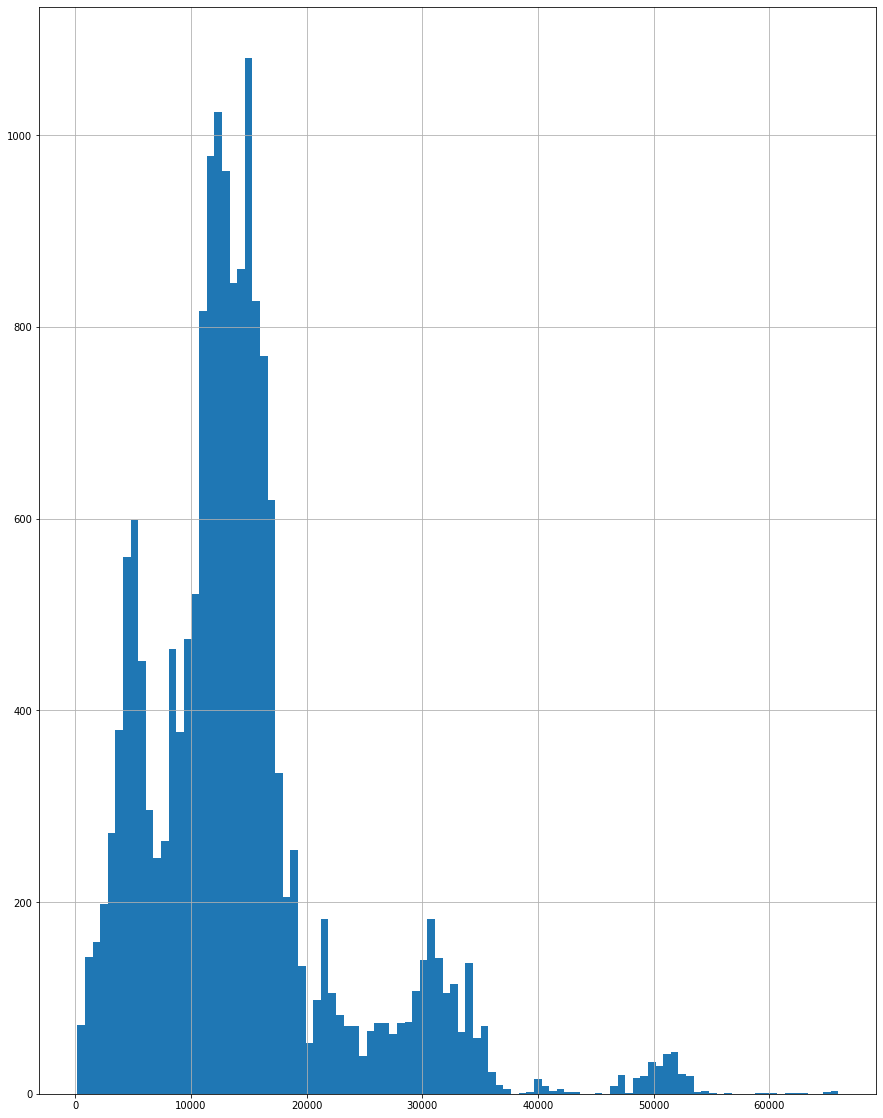

In [ ]:
data_research['city_centers_nearest'].hist(figsize=(15,20), bins = 100, grid = True)

Гистограмма неоднородна и имеет много пиков. Возможно, это связано с размерами населенных пунктов и их плотностью, этажностью и районностью застройки (если в выборке много небольших городков или квартир из центра густонаселенного города с высотками, то и малые расстояния встречаются чаще), то есть структуры населенного пункта, а значит это тоже не совсем случайные величины. К тому же расстояния между населенными пунктами тоже ограничены.

Но все-таки основная часть квартир находтся в пределах 40 километров до центра.

Посмотрим на отдаленные от центра жилища.

In [ ]:
data_research[data_research['city_centers_nearest'] > 40000]

,day_of_week,month,year,days_exposition,last_price,last_price_1000,price_per_meter,total_area,living_area,kitchen_area,rooms,ceiling_height,type_floor,floors_total,locality_name,city_centers_by_km,city_centers_nearest,parks,parks_nearest,ponds,ponds_nearest
11,0,8,2018,7.0,3300000,3300,75000.00,44.000000,31.000000,6.0,2,NaN,другой,5,Ломоносов,51.669998,51677.0,False,NaN,False,NaN
67,1,8,2018,39.0,2550000,2550,82258.06,31.000000,15.400000,7.2,1,2.50,другой,5,Ломоносов,51.099998,51100.0,False,NaN,True,490.0
72,6,12,2018,141.0,4500000,4500,81818.18,55.000000,35.500000,7.5,2,2.70,другой,3,Кронштадт,49.980000,49984.0,True,167.0,True,118.0
120,4,10,2017,360.0,2500000,2500,80906.14,30.900000,16.700001,6.0,1,2.75,первый,5,Кронштадт,50.720001,50722.0,True,285.0,True,221.0
128,2,2,2019,35.0,2500000,2500,80645.16,31.000000,19.500000,5.0,1,2.75,первый,3,Ломоносов,52.070000,52073.0,False,NaN,True,896.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23082,3,9,2015,487.0,3950000,3950,85683.30,46.099998,28.600000,7.1,2,NaN,другой,9,Ломоносов,51.389999,51399.0,False,NaN,False,NaN
23132,1,11,2016,616.0,4450000,4450,70634.92,63.000000,40.000000,7.2,3,2.50,другой,9,Петергоф,49.349998,49354.0,True,510.0,False,NaN
23377,6,11,2018,169.0,3150000,3150,70945.94,44.400002,28.799999,5.0,2,2.55,другой,5,Ломоносов,52.250000,52259.0,False,NaN,True,669.0
23526,3,2,2018,35.0,2950000,2950,55037.31,53.599998,32.000000,5.8,2,2.75,последний,3,Красное Село,41.709999,41718.0,False,NaN,False,NaN


Похоже, что все они относятся к пригородам Санкт-Петербурга, а потому считают расстояние до его центра.

Изучим распределение.

In [ ]:
data_research['city_centers_nearest'].describe()

count    17777.000000
mean     14229.888226
std       8627.784545
min        181.000000
25%       9315.000000
50%      13114.000000
75%      16293.000000
max      65968.000000
Name: city_centers_nearest, dtype: float64

<AxesSubplot:>

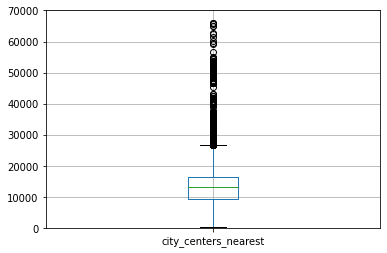

In [ ]:
plt.ylim(0, 70000)
data_research.boxplot(column=['city_centers_nearest'])

Среднее и медиана близки друг к другу. Но на стандартное отклонение похоже влияет "пригородный хвост".

***Выводы***

Основная часть продаваемых объектов находится в пределах от 9 до 16,5 км от центра населенного пункта.

Для дальнейшего исследования нам понадобятся данные с значниями `'<40'` в столбце `'city_centers_by_km'`.

##### Расстояние до ближайшего парка

Изучим гистограмму.

<AxesSubplot:>

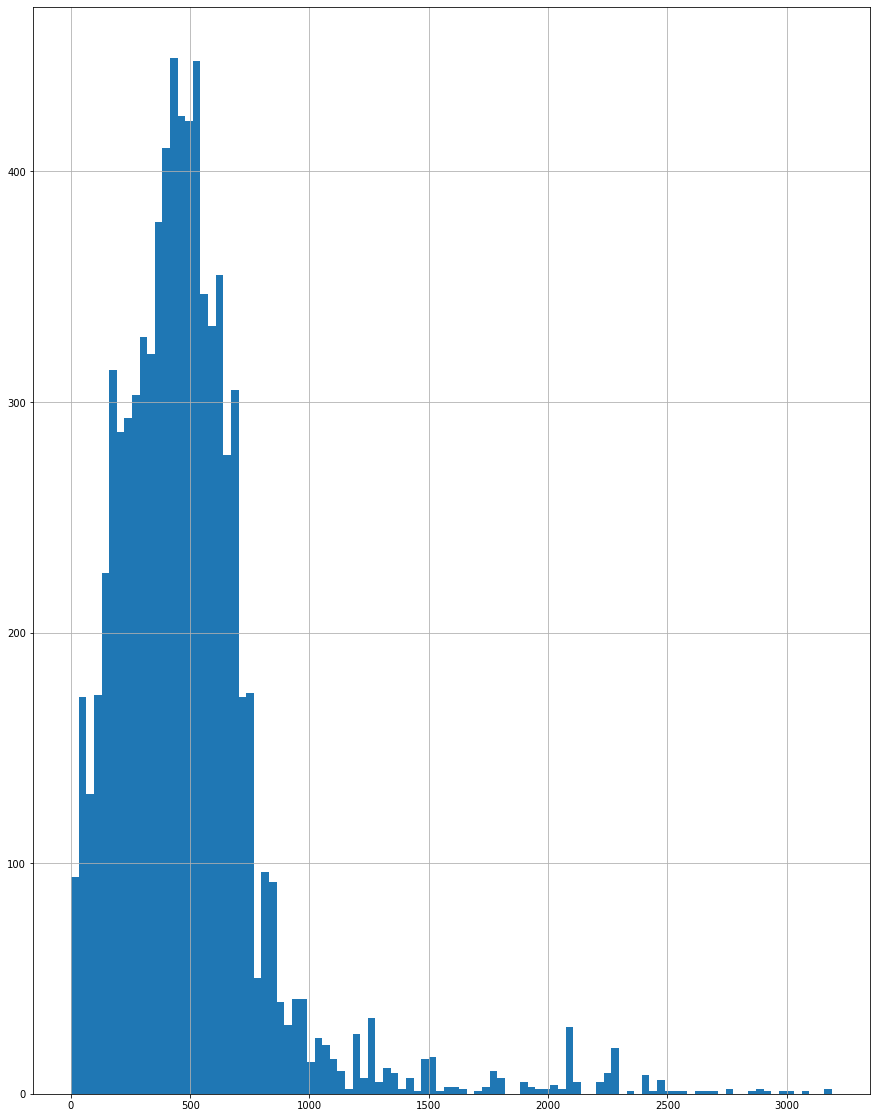

In [ ]:
data_research['parks_nearest'].hist(figsize=(15,20), bins = 100, grid = True)

В данном столбце у нас было очень много пропусков, что возможно объясняет некоторую "игольчатость поверхности" гистограммы. Но несмотря на эти самые пропуски, гистограмма выглядит на удивление неплохо.

Хоть парки могут быть искусственно созданными объектами (как и здания, расстояния от которых измеряют, плюс здания строят в конкретном месте по планам и нормам), гистограмма растояний до них приближается к нормальному распределению. К тому же область и ее главный город досточно "зеленые", что объясняет близость парков.

Но однако тоже имеется хвост. Причем хвост превышает величину 3000 метров, заложенную в самом названии связанного с текущим столбца (количество парков в радиусе 3000 метров).

Посмотрим на его содержимое.

In [ ]:
data_research[data_research['parks_nearest'] > 3000]

,day_of_week,month,year,days_exposition,last_price,last_price_1000,price_per_meter,total_area,living_area,kitchen_area,rooms,ceiling_height,type_floor,floors_total,locality_name,city_centers_by_km,city_centers_nearest,parks,parks_nearest,ponds,ponds_nearest
1585,1,7,2017,4.0,7500000,7500,107142.85,70.0,37.000000,10.0,2,NaN,другой,18,Санкт-Петербург,9.79,9791.0,False,3064.0,True,264.0
10898,1,3,2017,234.0,3000000,3000,96463.02,31.1,17.700001,5.5,1,NaN,другой,5,Санкт-Петербург,9.73,9734.0,False,3190.0,True,431.0
19101,3,10,2017,49.0,14950000,14950,79946.52,187.0,80.000000,17.0,5,3.0,последний,2,Санкт-Петербург,8.65,8656.0,False,3013.0,True,537.0
19322,3,2,2018,176.0,3900000,3900,127868.85,30.5,16.500000,5.5,1,2.6,первый,5,Санкт-Петербург,9.73,9734.0,False,3190.0,True,431.0


Как и ожидалось, в связанном столбце (есть ли парк в радиусе 3 км) указан False. Зато рядом есть пруд.

Расширим границы хвоста.

In [ ]:
data_research[data_research['parks_nearest'] > 1500]

,day_of_week,month,year,days_exposition,last_price,last_price_1000,price_per_meter,total_area,living_area,kitchen_area,rooms,ceiling_height,type_floor,floors_total,locality_name,city_centers_by_km,city_centers_nearest,parks,parks_nearest,ponds,ponds_nearest
321,3,6,2017,118.0,9591727,9591,133218.43,72.000000,34.000000,17.000000,2,2.80,другой,10,Санкт-Петербург,5.380000,5384.0,True,2295.0,True,534.0
369,2,9,2018,92.0,7300000,7300,112307.69,65.000000,30.040001,10.200000,2,NaN,другой,12,Санкт-Петербург,17.620001,17623.0,True,1510.0,True,372.0
436,3,6,2017,229.0,7410000,7410,105857.14,70.000000,NaN,NaN,2,NaN,другой,12,Санкт-Петербург,5.380000,5384.0,True,2295.0,True,534.0
509,1,12,2014,1155.0,6260000,6260,144572.75,43.299999,NaN,NaN,1,NaN,другой,8,Санкт-Петербург,10.720000,10720.0,True,2102.0,True,303.0
680,1,12,2014,1141.0,9200000,9200,110936.93,82.930000,41.919998,16.740000,2,NaN,другой,12,Санкт-Петербург,10.720000,10720.0,True,2102.0,True,303.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23028,3,7,2018,54.0,7952000,7952,124250.00,64.000000,37.000000,11.000000,2,2.75,другой,10,Санкт-Петербург,5.380000,5384.0,True,2295.0,True,534.0
23108,0,4,2019,NaN,21800000,21800,191228.07,114.000000,64.400002,23.299999,3,2.75,другой,15,Санкт-Петербург,8.250000,8256.0,True,2009.0,True,253.0
23211,0,4,2017,475.0,11900000,11900,140000.00,85.000000,51.000000,13.600000,3,NaN,другой,8,Санкт-Петербург,17.139999,17143.0,True,1514.0,True,16.0
23272,4,2,2017,277.0,17671500,17671,196350.00,90.000000,35.000000,16.000000,2,2.80,другой,12,Санкт-Петербург,10.720000,10720.0,True,2102.0,True,303.0


Многие такие объекты имеют рядом не только парк, но и пруд.

Изучим распределение.

In [ ]:
data_research['parks_nearest'].describe()

count    7892.000000
mean      490.286873
std       339.241155
min         1.000000
25%       288.000000
50%       455.000000
75%       612.000000
max      3190.000000
Name: parks_nearest, dtype: float64

<AxesSubplot:>

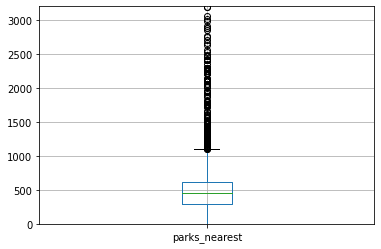

In [ ]:
plt.ylim(0, 3200)
data_research.boxplot(column=['parks_nearest'])

Среднее и медиана похожи, а значит даже хвост не смог слишком навредить данным. Но при этом большое стандартное отклонение все-таки указывает на сложности с данными (дополнительные пики).

***Выводы***

Основное количество продаваемых объектов имеет парк в радиусе от 288 до 612 метров.

Для дальнейшего использования мы возьмем значениям столбца `'parks_nearest'` `'<1500'`

После всех очисток можно наконец сбросить индексы.

In [ ]:
data_research.reset_index(drop=True, inplace=True)

***Выводы***

Мы осмотрели полученные данные на предмет аномалий и по-возможности устранили их, а также определили пригодные для исследования диапазоны значений в различных столбцах.

#### Быстрота продажи квартиры

Скорость продажи квартиры - тоже немаловажный фактор, часто связанный с ценой. Если цена ниже, то и купят квартиру быстрее и охотнее.

Изучим скорость продажи квартир, попытаемя найти среднюю стоимость, а также узнать, что считать быстрой продажей, а когда уже пора начинать волноваться и снижать цену.

Для начала построим гистограмму для дней размещения.

<AxesSubplot:>

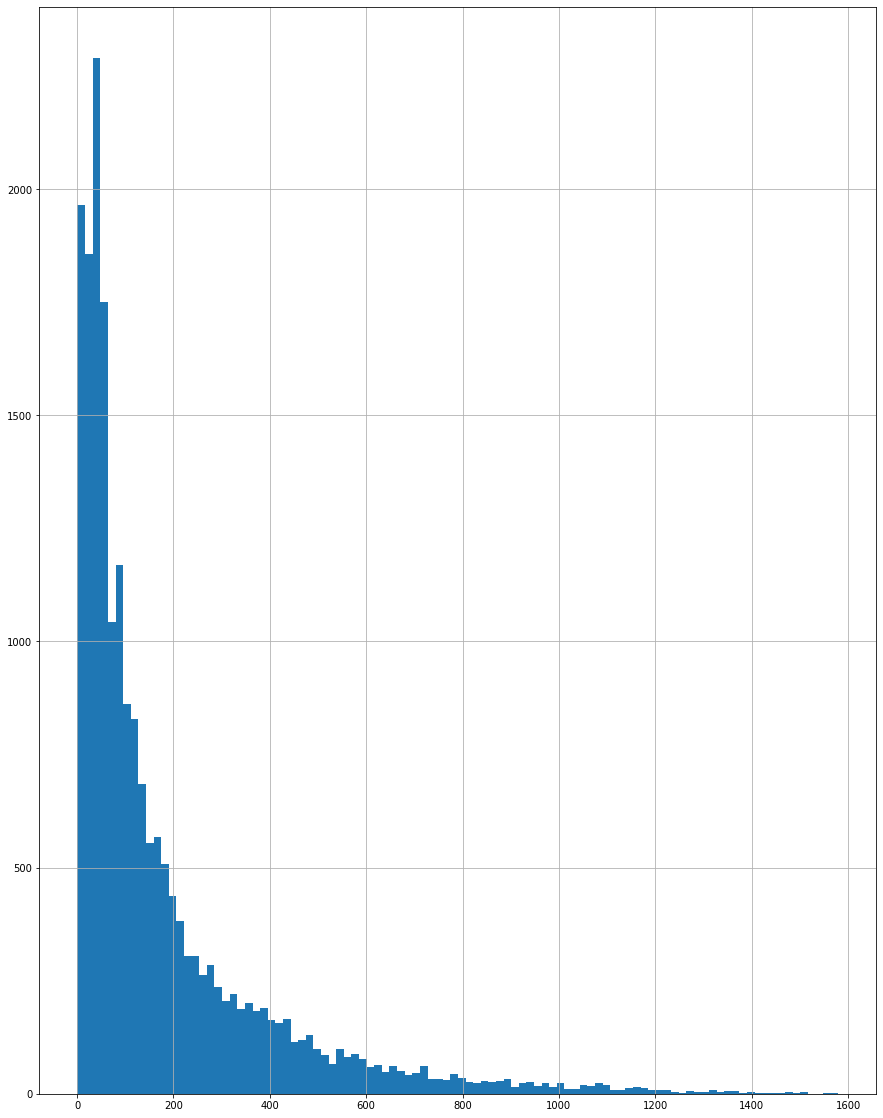

In [ ]:
data_research['days_exposition'].hist(figsize=(15,20), bins = 100, grid = True)

В целом гистограмма выглядит логично - чем "свежее" объявление, тем выше шанс продажи.

Более старые объявления опускаются по странице и уже реже попадаются на глаза потенциальному покупателю. Плюс самих объявлений со временем становится меньше: объект продается, объявление закрывается.

Но есть определенные пики, которые могут быть как особенностью масштабирования (использования определенного количества корзин) гистограммы, так и из-за проблем внутри данных или или иных особенностей в процессе продажи квартир.

Посмотрим на медиану и среднее, чтобы определить характерную скорость продаж.

In [ ]:
data_research['days_exposition'].describe()

count    20090.000000
mean       180.553808
std        219.733490
min          1.000000
25%         45.000000
50%         95.000000
75%        231.000000
max       1580.000000
Name: days_exposition, dtype: float64

Средняя скорость продаж составляет 180 дней (на нее влияет затяжной хвост из "залежавшихся" квартир), тогда как медианной будет 95 дней.

Попробуем изучить диаграмму распределения.

<AxesSubplot:>

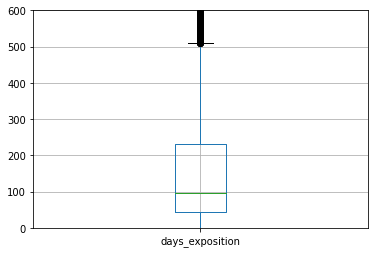

In [ ]:
plt.ylim(0, 600)
data_research.boxplot(column=['days_exposition'])

Основная часть продаж происходить в пределах 45-231 дня. Верхний ус диаграммы переходит границу в 500 метров. То есть такие продажи (более 500 метров) уже можно считать необычно долгими (то есть относящимися к аномалиям/выбросам при статистической обработке данных).

Быстрыми продажами можно считать те, что произошли до 45 дней.

***Вывод***

Быстрыми продажами можно считать те, что произошли за период до 45 дней. Необычайно долгими - те, что преодолели порог в 500 дней.

Основная же часть сделок совершается в период 45-231 день.

#### Зависимость цены (общая)

После обработки данных мы наконец можем приступить к основной части исследований и попытаться найти общую зависимость от определенных параметров продаваемой квартиры.

Были выбраны наиболее перспективные из них, у части из которых будут ограничения диапазона используемой выборки из-за устоновленных на предыдущем этапе аномалий. Также при получении сводных таблиц будем использовать медиану вместо среднего для получения более корректных результатов.

##### Общая площадь

Наверно, один из первых (или самых первых) параметров, на который обратят внимания будущие покупатели. Больше квартира - выше цена?

Проверим это. Для проверки будем использовать данные из  ранее установленных диапазонов (значения `'< 50000'` в столбце `'last_price_1000'` и  `'<= 200'` в столбце `'total_area'`).

Для начала попробуем построить обычный график(1) по сводной таблице с условиями.

<AxesSubplot:xlabel='total_area'>

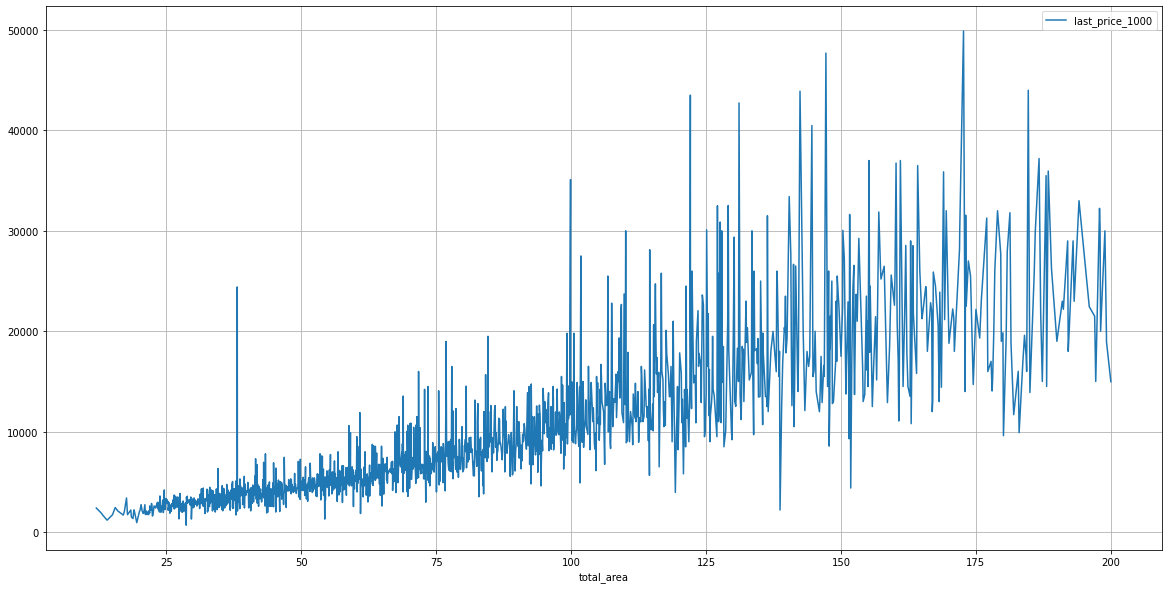

In [ ]:
data_research.query('last_price_1000 < 50000 and total_area <= 200')\
.pivot_table(index='total_area', values='last_price_1000', aggfunc='median')\
.plot(grid=True, figsize = (20,10)) # вариант 1

Получилось подобие кардиограммы, которая к тому же имеет местами резкие пики. Но в целом видна тенденция к повышению цены с увеличением размера квартиры.

Попробуем исправить визуализацию (2).

<AxesSubplot:xlabel='total_area'>

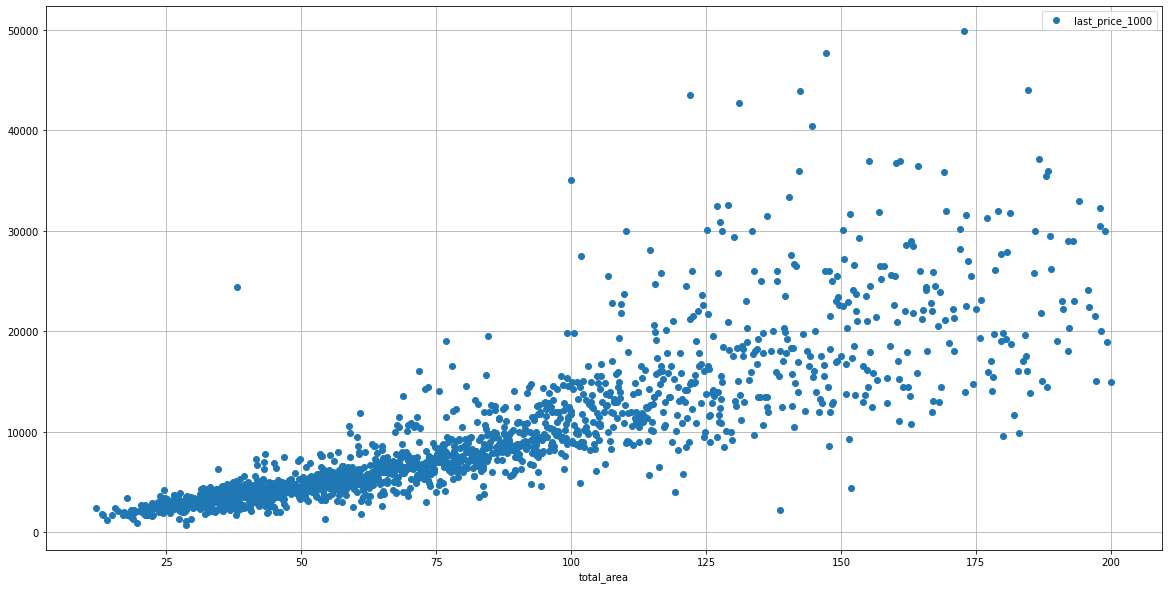

In [ ]:
data_research.query('last_price_1000 < 50000 and total_area <= 200')\
.pivot_table(index='total_area', values='last_price_1000', aggfunc='median')\
.plot(style='o', grid=True, figsize = (20,10)) # вариант 2

На отрезке от 0 до 100 м² зависимость видна уже более четко: в целом, чем больше площадь, тем выше цена. После 100 хвост понемногу размывается и рассеивается, но в целом тенденция сохраняется.

Также ярче стали видны аномалии, которые было проблематичной выявить на гистограммах (вроде квартиры общей площадью между 25 и 50 м² с ценой в диапазоне 20-30 млн).

Попробуем представить этот же график иным инструментом, чтобы выбрать более потенциально подходящую визуализацию для использования далее (3).

<AxesSubplot:xlabel='total_area', ylabel='last_price_1000'>

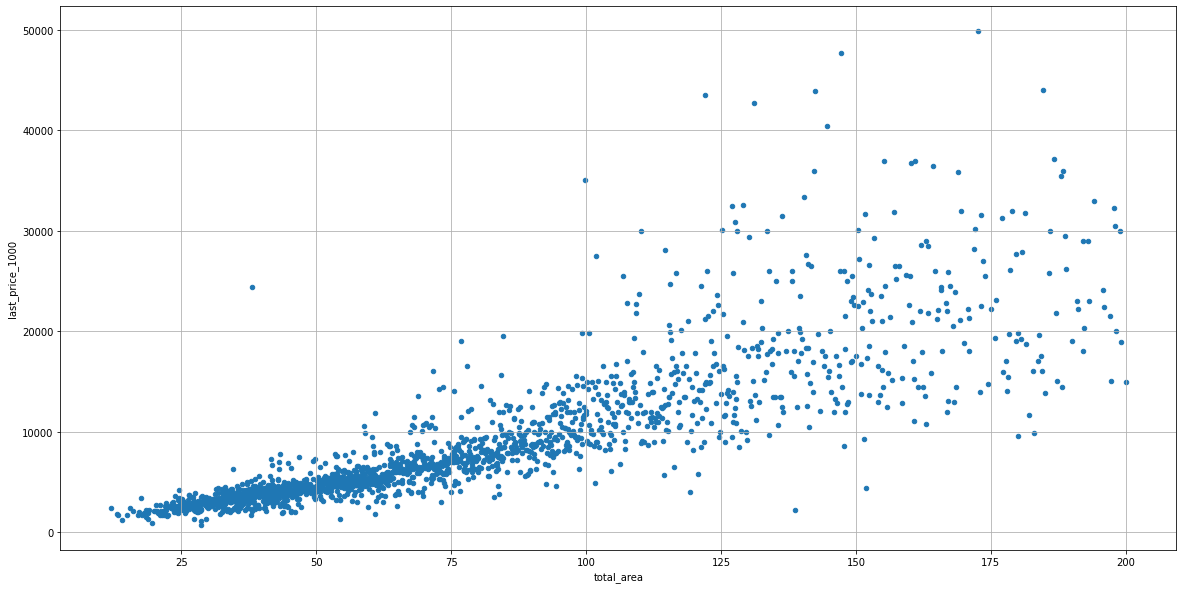

In [ ]:
data_research.query('last_price_1000 < 50000 and total_area <= 200')\
.pivot_table(index='total_area', values='last_price_1000', aggfunc='median').reset_index()\
.plot(grid=True, figsize = (20,10), x='total_area', y='last_price_1000', kind = 'scatter') # вариант 3

Этот и предыдущий способ показали одинаковую картину зависимости/распределения.

Первый требует меньше кода, но вместо подписи оси 'y' указывает в верхнем правом углу то, что же обозначают наши точки, что выглядит не очень подходяще для нашего случая.

Второй же хоть и требует дополнительного сброса индекса и указания большего количества параметров (то есть больше кода), зато ось 'y' у нас подписана и сами точки выглядят аккуратнее.

Нет пределов совершенству, поэтому попробуем еще один вариант (4) визуализации, чтобы оценить "плотность случаев".

<AxesSubplot:xlabel='total_area', ylabel='last_price_1000'>

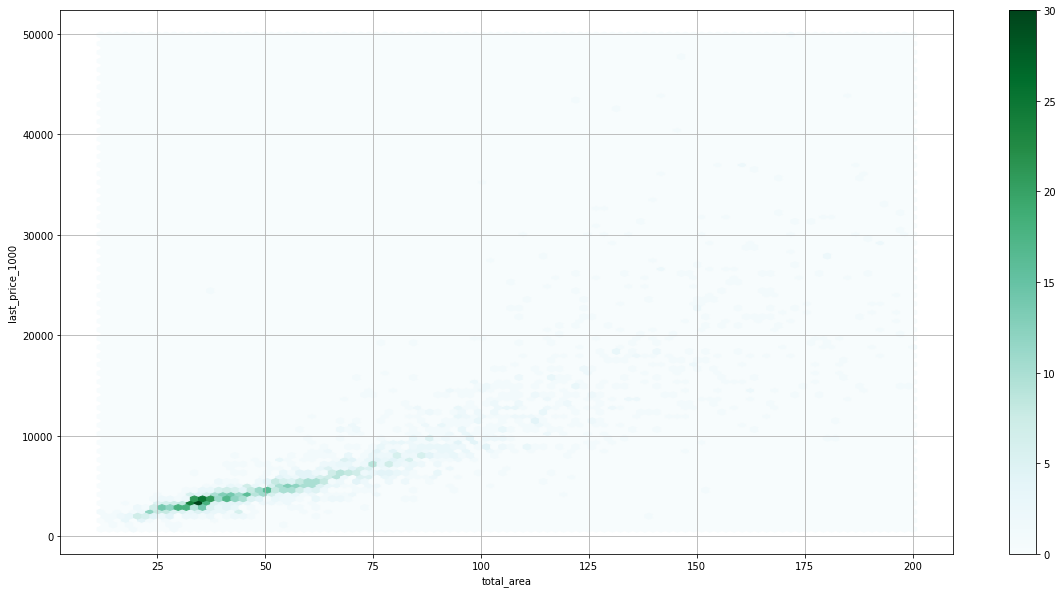

In [ ]:
# вариант 4
data_research.query('last_price_1000 < 50000 and total_area <= 200')\
.pivot_table(index='total_area', values='last_price_1000', aggfunc='median').reset_index()\
.plot( x='total_area', y='last_price_1000', kind = 'hexbin',gridsize=100, sharex=False, figsize = (20,10),  grid=True)

Такой график лучше отражает частоту встречаемости случаев (наибольшая плотность, как и ожидалалось, находится в районе приблизительно от 30 до 40м² в районе ранее установленных медиан и среднего), и в целом также подтверждает хорошую прямую связь между общей площадью и ценой продажи. Но в какой-то момент график сильно размывается, плохо позволяя увидеть данные в целом и не позволяет увидеть аномалии в частности. Поэтому оставновимся на варианте графика номер 3.

Графики графиками, но числовые показатели тоже важны. Поэтому рассчитаем коэфициент Пирсона.

In [ ]:
data_research.query('last_price_1000 < 50000 and total_area <= 200')['last_price_1000']\
.corr(data_research.query('last_price_1000 < 50000 and total_area <= 200')['total_area'])

0.7697256334109235

Чем ближе этот кофэфициент к крайним значениям (-1 или 1), тем теснее связь между параметрами. В нашем случае он составил (с округлением) 0,77, что указывает на хорошую связь между общей площадью и конечной ценой.

***Выводы***

Конечная общая цена достаточно сильно зависит от общей площади (коэффициент кореляции Пирсона составил 0,77). То есть чем больше общая площадь, тем выше цена (особенно это хорошо заметно на площадях до 100 м²).

##### Жилая площадь

Тоже немаловажно. Вдруг там длинный коридор, просторные ванна и кухня, а вот в комнату кроме кровати и шкафа почти ничего не влезет?

Визуализируем зависимость цены продажи от жилой площади, используя выявленные ранее ограничения (значения `'< 50000'` в столбце `'last_price_1000'` и `<= 100` в столбце `'living_area'`), а затем посчитаем коэфициент корреляции.

<AxesSubplot:xlabel='living_area', ylabel='last_price_1000'>

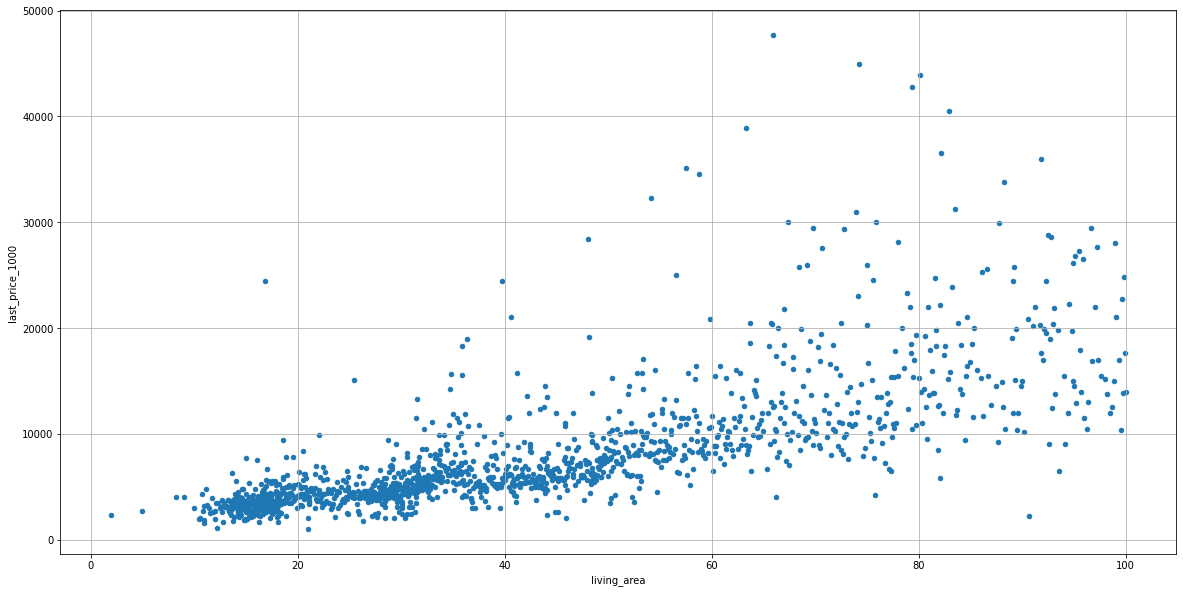

In [ ]:
data_research.query('last_price_1000 < 50000 and living_area <= 100')\
.pivot_table(index='living_area', values='last_price_1000', aggfunc='median').reset_index()\
.plot(grid=True, figsize = (20,10), x='living_area', y='last_price_1000', kind = 'scatter') # визуализируем

In [ ]:
data_research.query('last_price_1000 < 50000 and living_area <= 100')['last_price_1000']\
.corr(data_research.query('last_price_1000 < 50000 and living_area <= 100')['living_area']) # считаем корелляцию

0.6499383566833428

Тенденция на увеличиние общей цены при увеличении жилой площади также сохраняется, однако связь уже более слабая, чем у цены и общей площадью. На графике это видно относительно неплох она площадях до 50 м² (хотя уже и после 40 хватает аномалий).

***Выводы***

Выявлена связь между жилой площадью и общей ценой: чем больше жилая площадь, тем выше цена. Однако зависимость цены от жилой площади меньше, чем от общей площадь (коэффициент кореляции Пирсона составил 0,65).

##### Площадь кухни

Просторная кухня обычно более удобна, чем маленькая, и позволяет, к примеру, разместить больше мебели и кухонной техники. Но при этом отнимает на себя часть общей площади.

Студии решили проще: нет кухни - нет зависимости. А как у других?

Не забудем использовать ранее вывленые ограничения: значения `'< 50000'` в столбце `'last_price_1000'` `0<` и `<= 25` в столбце `'kitchen_area'`.

<AxesSubplot:xlabel='kitchen_area', ylabel='last_price_1000'>

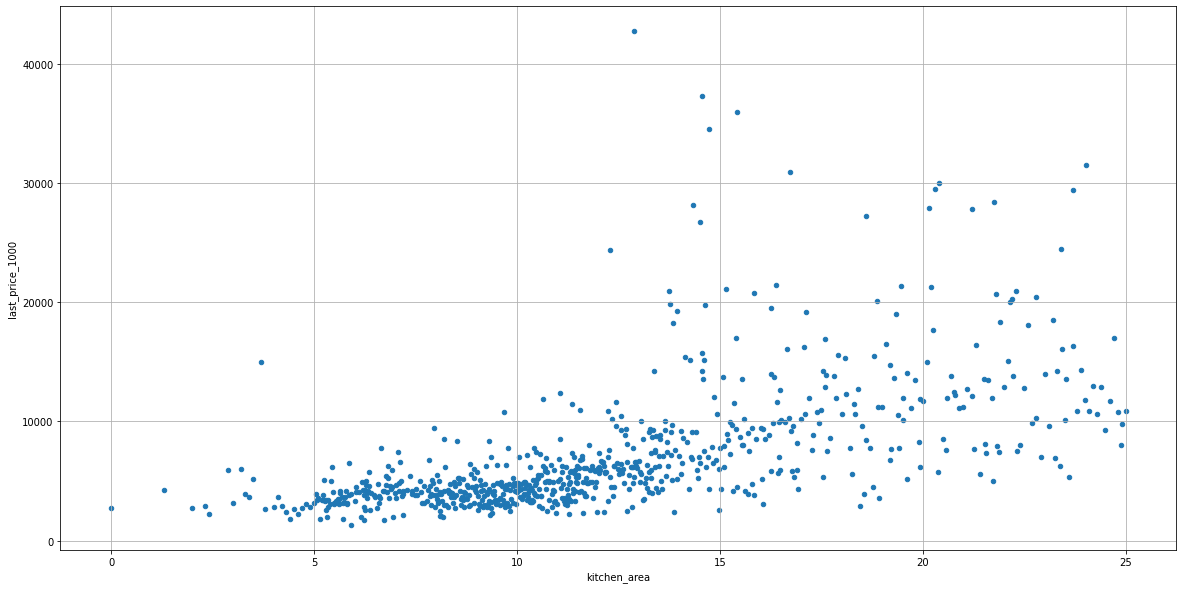

In [ ]:
data_research.query('last_price_1000 < 50000 and kitchen_area <= 25')\
.pivot_table(index='kitchen_area', values='last_price_1000', aggfunc='median').reset_index()\
.plot(grid=True, figsize = (20,10), x='kitchen_area', y='last_price_1000', kind = 'scatter') # визуализируем

In [ ]:
data_research.query('last_price_1000 < 50000 and kitchen_area <= 25')['last_price_1000']\
.corr(data_research.query('last_price_1000 < 50000 and kitchen_area <= 25')['kitchen_area']) # считаем корелляцию

0.5573109181557208

Хотя определенные тенденции роста цены с увеличением площади кухни прослеживаются, но увидеть такую же яркую зависимость на графике не выходит. И коэффициент корреляции (составивший 0.56, средний уровень зависимости) подтверждает слабость этой связи в сравнении с предыдущими параметрами, хотя в целом чем больше площадь кухни, тем выше цена.

***Выводы***

Увеличение площади кухни также приводит к увеличению общей цены. Однако коэфициент зависимости Пирсона составил 0.56, что указывает на слабость данной зависимости относительно влияния других площадей.

##### Количество комнат

Что дороже: много маленьких или несколько больших? Сложно сказать. Но можно попытаться найти связь между количеством и стоимостью.

Поищем зависимость для значений `'< 50000'` в столбце `'last_price_1000'` и `'<= 6'` в столбце `'rooms'`. Так как количество вариантов комнат у нас ограничено, можно для начала использовать график с линией (вариант 1).

<AxesSubplot:xlabel='rooms'>

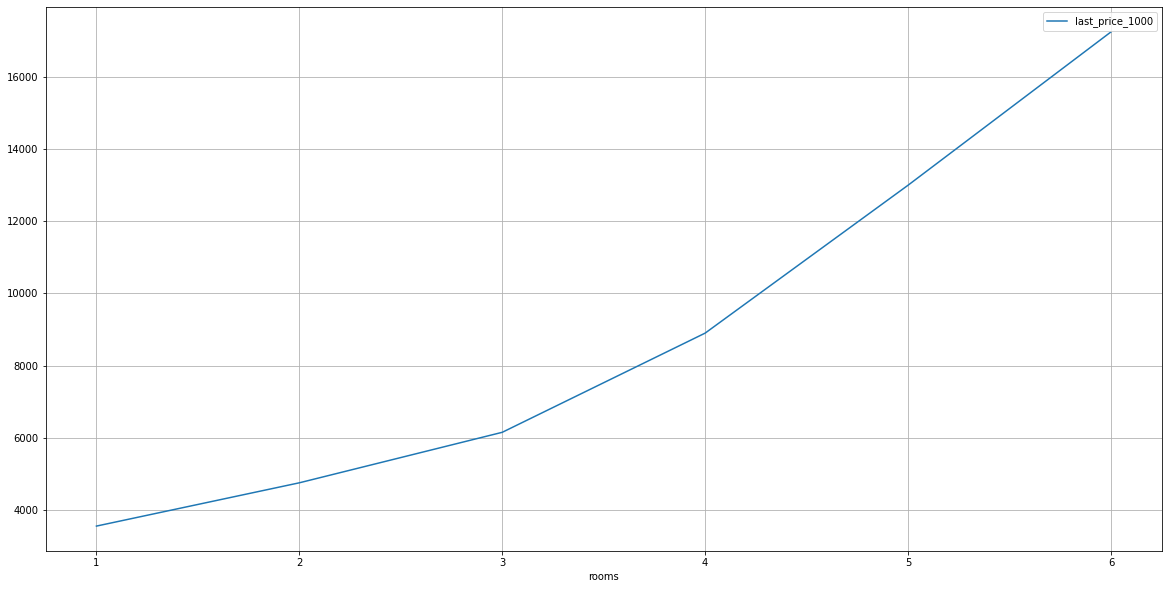

In [ ]:
data_research.query('last_price_1000 < 50000 and rooms <= 6')\
.pivot_table(index='rooms', values='last_price_1000', aggfunc='median')\
.plot(grid=True, figsize = (20,10)) # визуализируем

Такой график выглядит красиво. Но все-таки у нас отдельные целые значения (то есть в некотором роде категории), а не диапазон значений, как в тех же площадях. Поэтому все-таки для визуализации корректнее использовать график типа 'bar' (вариант 5).

<AxesSubplot:xlabel='rooms'>

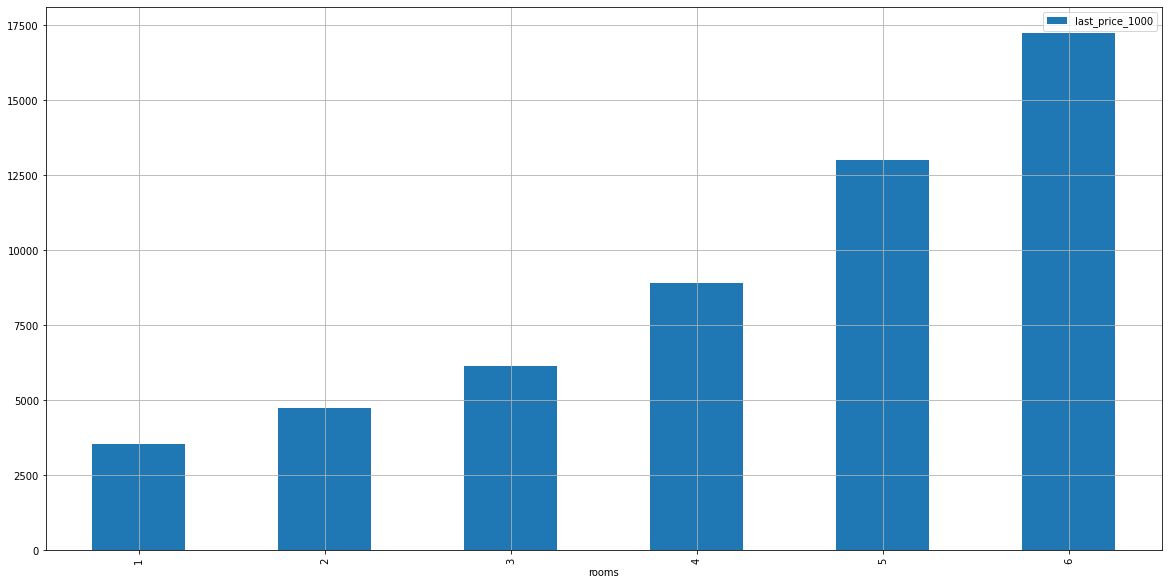

In [ ]:
data_research.query('last_price_1000 < 50000 and rooms <= 6')\
.pivot_table(index='rooms', values='last_price_1000', aggfunc='median')\
.plot(y='last_price_1000', kind='bar',figsize = (20,10), grid=True,) # визуализируем

Выглядит гораздо нагляднее и не вводит в заблужение о неприрывности значений, а "разметка сеткой" позволяет легче читать график и более точных проводить визуальные сравнения показателей в графике. Для презентации результатов в общих выводах сетку можно будет убрать.

In [ ]:
data_research.query('last_price_1000 < 50000 and rooms <= 6')['last_price_1000']\
.corr(data_research.query('last_price_1000 < 50000 and rooms <= 6')['rooms']) # считаем корелляцию

0.4945739956034655

И хотя коэфициент корреляции указывает на средний уровень зависимости (возможно, это связано с тем, что квартир с меньшим количеством комнат в принципе есть и строится больше, что мы ранее наблюдали на соответсвующих гистограмме и диаграмме размаха), но графики однозначно показывают, что чем больше комнат - тем выше цена. Однако эта зависимость может быть вторичной, ведь больше комнат наверняка часто значит и большую общую площадь (с которой связь уже теснее).

Также отличия между тем, что показывает коэффициент кореляции и график может быть вызван категориальностью наших значений для комнат.

***Выводы***

Коэффициент кореляции Пирсона (0,49) указал на средний уровень зависимости между количеством комнат и общей ценой, но это может быть связано с тем, что варианты  с 1, 2 (3 - немного реже, но тоже часто) комнатами встречаются чаще, чем более многокомнатные квартиры.

График же указывает на линейность зависимости между количеством комнат и конечной ценой квартиры (чем больше первое, тем выше второе). Но эта зависимость может быть вторичной, бедь большее количесво комнат, как правило, означает и большие общую и жилую площади (а вот от них зависимость уже сильнее).

Но в целом - чем больше комнат, тем выше цена.

##### Тип этажа

У каждого этажа есть плюсы и минусы. На первый легче подниматься, но под полом может быть холодный подвал. Последнему деревья не заслоняют солнце, но вот риск протечки крыши выше. А пятый в пятиэтажке без лифта и пятый в дквятиэтажке с лифтом - это и вовсе два разных этажа.

Попробуем найти связь между категорией этажа и ценой, используя ранее отобранные значения `'< 50000'` в столбце `'last_price_1000'`. Данные разделены по категориям, поэтому тоже будем использовать 'bar'-график (вариант 5).

<AxesSubplot:xlabel='type_floor'>

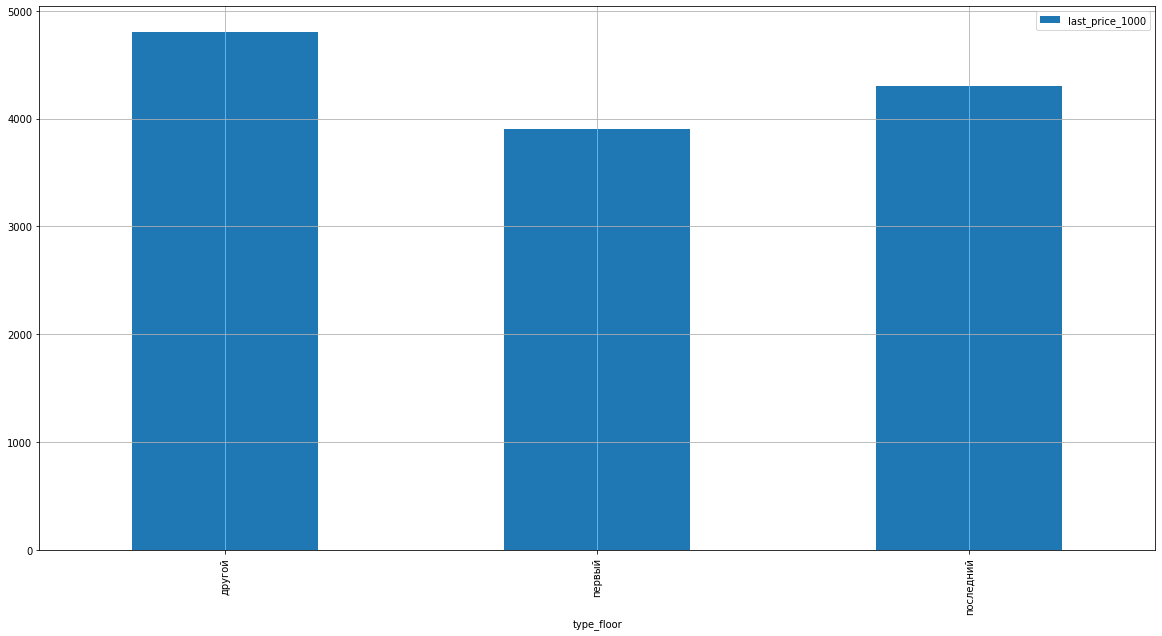

In [ ]:
data_research.query('last_price_1000 < 50000')\
.pivot_table(index='type_floor', values='last_price_1000', aggfunc='median')\
.plot(y='last_price_1000', kind='bar',figsize = (20,10), grid=True) # визуализируем

Как мы видим на графике, зависимость нелинейна: первый этаж является однозначным минусом к цене. Последний тоже менее привлекательный, чем другие, но не настолько, как первый.

Интересно было бы узнать причину такого резкого отличия в показателях. Холодный подвал, закрытое деревьями небо, магазины с шумными покупателями за стеной? А может причина банальнее, и большое количество объектов находится в недорогих райнах низкой застройки и проживает в частных домах где первый этаж он же последний?

Для проверки подобного варианта мы возьмем значения `'< 30'` в столбце `'floors_total'` и используем исходный датафрейм.

In [ ]:
data.query('last_price_1000 < 50000 and floors_total < 30').groupby('floor').agg({'floors_total':['count']})

,floors_total
,count
floor,
1,2903
2,3339
3,3036
4,2768
5,2589
6,1280
7,1195
8,1063


Да, таких квартир почти 3 тысячи, но эта небольшая часть от находящихся в исследовании почти 23. Значит, дело все-таки в другом.

Для дополнительной проверки коэфициент корреляции Пирсона мы использовать не сможем, так как в данном случае мы смотрим заисимость от категориальных данных.

***Выводы***

Квартиры, находящиеся на первом этаже, стоят гораздо дешевле остальных. Самые дорогие квартиры находятся в категории "другие".

##### Дата размещения (день недели, месяц, год)

Возможно, если выложить в выходные (субботу и воскресенье) объявление увидят и захотят купить большее количество людей, у которых будет больше свободного времени на поиск квартиры и общения с хозяевами. С другой стороны, по этой же причине и выше конкуренция (покупателю проще найти более привлекательный вариант в виду большего свободного времени, да и продавцы в выходные тоже более свободны и большее их количество может заняться оформлением объявления и демонстрацией объекта).

А с третьей - квартиры продаются в среднем от 45 до 231 дня. Так что вряд ли такая мелкая единица времени может на что-то повлиять, особенно - на цену. А вот месяц уже более сущесвеннен. Летом люди тратятся на отдых, зимой - на новогодние подарки. Может и тут есть сезонность?

Влияние же года завязано на общую экономическую ситуацию в регионе.

А теперь приступим к поиску зависимостей, не забывая об ограничениях (используем значения `'< 50000'` в столбце `'last_price_1000'`).

##### День недели

Начнем с дня недели, в котрый было выложено объявление, как с наиболее мелкой и предположительно маловлиятельной единицы.

<AxesSubplot:xlabel='day_of_week'>

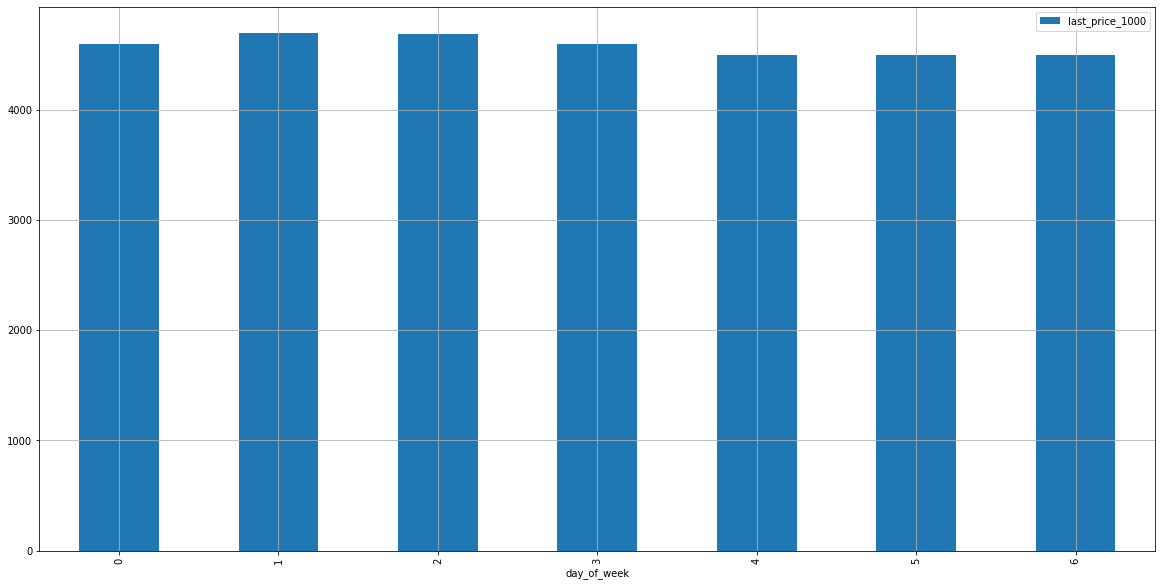

In [ ]:
data_research.query('last_price_1000 < 50000')\
.pivot_table(index='day_of_week', values='last_price_1000', aggfunc='median')\
.plot(y='last_price_1000', kind='bar',figsize = (20,10), grid=True) # визуализируем

На первый взгляд, во вторник и среду цены выше, а в пятницу, субботу и воскресенье - ниже, чем у выставляемых в четверг и понедельник.Однако эти колебания не выглядят слишком большими (особенно на фоне других параметров, влияющих на цену, например, общей площади).

Но сам факт зависимости от дня недели выглядит странно (и возможно зависит от количества выкладываемых в принципе в разные дни недели квартир), поэтому стоит присмотреться внимательней. Можно также посчитать коэфициент корреляции (однако дни недели - категориальные значения, поэтому его использование может быть не очень корректным).

In [ ]:
data_research.query('last_price_1000 < 50000')['last_price_1000']\
.corr(data_research.query('last_price_1000 < 50000')['day_of_week']) # считаем корелляцию

-0.015620930474048797

Коэффициент кореляции близок к нулю, что указывает на отсутсвие линейной зависимости.

То есть, как и следовало ожидать, особой разнице в ценах в зависимости от дня недели на самом деле не имеется, либо колебания эти не слишком значительные.

***Выводы***

Коэффициент кореляции Пирсона близок к нулю,что указывает на отсутствие линейной зависимости цены квартиры от дня недели, в который был выложено объявление.

График хотя и показывает максимум цен во вторник и среду, а минимум - в субботу и воскресенье, виду небольшого уровня колебаний цен также подтверждает слабое влияние дня недели, в которую было выложено объявление, на стоимость квартиры.

##### Месяц

Месяц выглядит более весомой единицей влияния, чем день недели. Возможно, что и продажа квартир подвержена сезонному влиянию?

Для начала построим график зависимости общей цены от месяца, в который было выложено объявление.

<AxesSubplot:xlabel='month'>

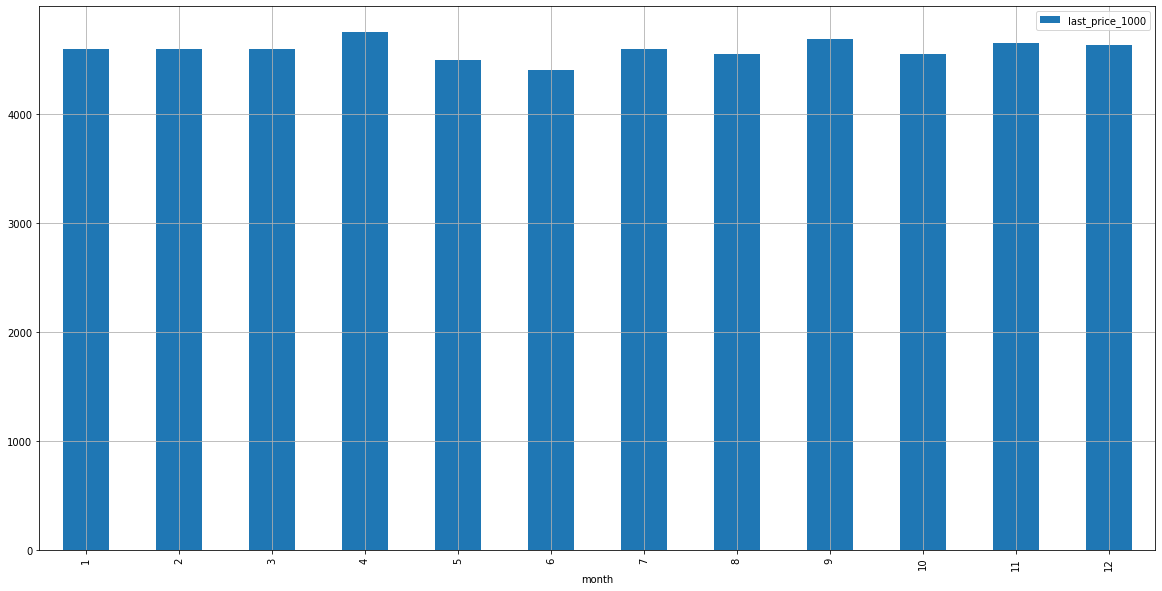

In [ ]:
data_research.query('last_price_1000 < 50000')\
.pivot_table(index='month', values='last_price_1000', aggfunc='median')\
.plot(y='last_price_1000', kind='bar',figsize = (20,10), grid=True) # визуализируем

Согласно графику, самые дорогие квартиры появляются на рынке в апреле, а самые дешевые - в июне.

Но колебания эти не слишком значительны, хотя и "плавности" в поведении столбиков (в отличие от тех же дней недели) не наблюдается. Но в целом нельзя утвержать однозначно о наличии зависимости цены квартиры от месяца, когда было выложено объявление.

Это логично, ведь квартира - это не елочная игрушка, это товар дорогой и продающийся в течении относительно длительного периода времени, а значит сезонности (в отличе от цен на краткосрочную аренду, например, у номера в отеле у моря) подвержен быть не должен.

In [ ]:
data_research.query('last_price_1000 < 50000')['last_price_1000']\
.corr(data_research.query('last_price_1000 < 50000')['month']) # считаем корелляцию

0.00767963663046698

Ожидаемо, коэфициент корреляции не обнаружил линейной зависимости цены квартиры от месяца, когда было выложено объявление о ее продаже.

***Выводы***

Коэффициент кореляции Пирсона близок к нулю,что указывает на отсутствие линейной зависимости цены квартиры от месяца, в который было выложено объявление о продаже.

График утверждает, что самые дорогие квартиры чаще всего появлялись на рынке продаж в апреле, самые дешевые - в июне. Но в целом нельзя утвержать однозначно о наличии зависимости цены квартиры от месяца, когда было выложено объявление.

##### Год

Год выглядит более перспективной единицей. На него оказывает влияние экономическая ситуация в стране (наприер, уровни инфляции или зарплат), что может сказаться и на ценах за квартиру.

Снова начнем с визуализации.

<AxesSubplot:xlabel='year'>

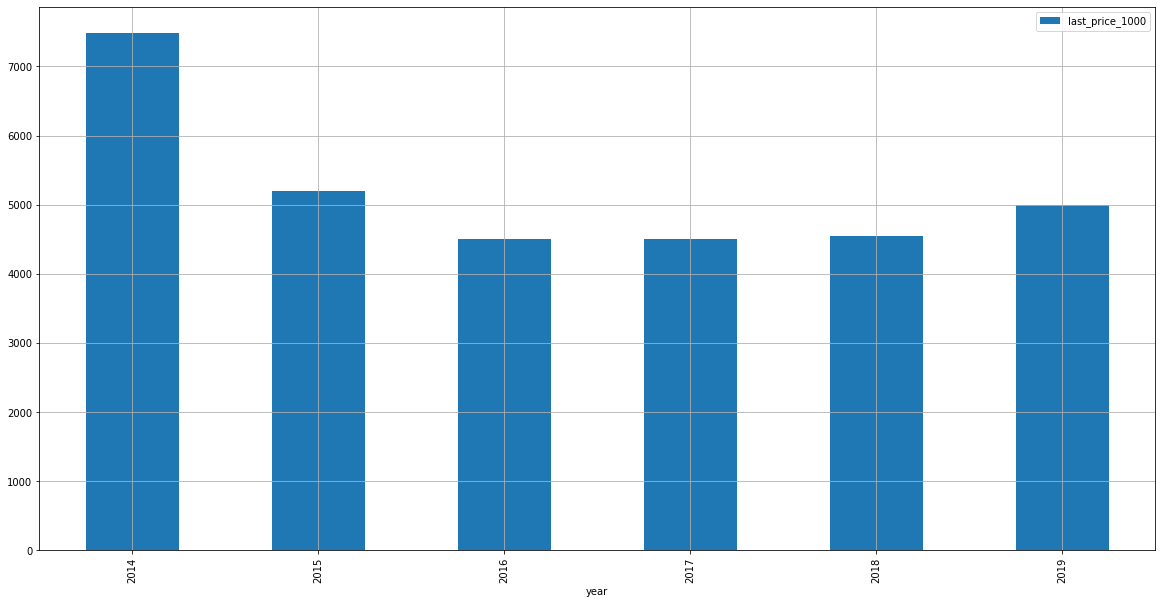

In [ ]:
data_research.query('last_price_1000 < 50000')\
.pivot_table(index='year', values='last_price_1000', aggfunc='median')\
.plot(y='last_price_1000', kind='bar',figsize = (20,10), grid=True) # визуализируем

Самые дорогие квартиры были в 2014 году (возможно, ввели в экспуатацию много новостроек в Санкт-Петербурге и его пригородах?). В 2015 и 2016 году они существенно дешевели относительно предыдущего года. В период 2016-2018 стоимость была практически на одном уровне (в 2018 немного подорожали, но незначительно), в 2019 вновь пошел рост, однако уровня 2014 года так и не достиг.

Определенная зависимость тут видна, хоть она и явно нелинейна (значит можно обойтись без коэфициента корреляции Пирсона).

Но может быть секрет не в самом годе, а в квартирах, которые тогда продавались? Точнее, в их размерах (ведь, как мы уже установили ранее, общая площадь оказывает достаточно сильное влияние на цену).

Изучим это предположение.

In [ ]:
data_research.query('last_price_1000 < 50000')\
.pivot_table(index='year', values='total_area', aggfunc='median')

,total_area
year,
2014,76.050003
2015,59.800003
2016,53.000000
2017,51.900002
2018,50.500000
2019,51.599998


Действительно, медиана общей площади продаваемых в 2014 квартир была выше, чем у остальных. И в целом динамика изменения этой медианы схожа с медианой цен в зависимоcти от года. Входит, что на самом деле зависимости нет.

***Выводы***

Зависимость цены квартиры от года, в котором было выложено объявление, отсутствует.

#### Самые дорогие и дешевые населенные пункты

Неплохо было бы посмотреть на общее распределение цен по населенным пунктам.

Какие-то населенные пункты крупнее сами по себе, и объявления встречаются чаще, а какой-то может быть представлен в единсвенном экземпляре и не нести с собой полезной информации по данному вопросу. Поэтому для исследования мы выделим 10 самых активных в продажах населенных пунктов и составим из них рейтинг по средней цене квадратного метра.

Для начала определим эти самые населенные пункты.

In [ ]:
data_research['locality_name'].value_counts().head(10)

Санкт-Петербург      15398
поселок Мурино         537
поселок Шушары         430
Всеволожск             395
Пушкин                 362
Колпино                338
поселок Парголово      313
Гатчина                305
деревня Кудрово        287
Выборг                 237
Name: locality_name, dtype: int64

Ожидаемо, первое место занял сам Санкт-Петербург. Его некоторые пригороды также попали в наш топ-10.

Сохраним наш перечень в новую переменную для дальнейших расчетов.

In [ ]:
top_10 = data_research['locality_name'].value_counts().head(10).reset_index()

In [ ]:
top_10 # проверяем успешность создания, смотрим название нужного далее столбца

,index,locality_name
0,Санкт-Петербург,15398
1,поселок Мурино,537
2,поселок Шушары,430
3,Всеволожск,395
4,Пушкин,362
5,Колпино,338
6,поселок Парголово,313
7,Гатчина,305
8,деревня Кудрово,287
9,Выборг,237


In [ ]:
data_research.query('locality_name in @top_10["index"]')\
.pivot_table(index='locality_name', values='price_per_meter', aggfunc='mean')\
.rename(columns={'price_per_meter':'mean_price_per_meter'})\
.sort_values(by='mean_price_per_meter', ascending = False)

,mean_price_per_meter
locality_name,
Санкт-Петербург,114118.740794
Пушкин,102905.940138
деревня Кудрово,92550.473972
поселок Парголово,89782.452875
поселок Мурино,85467.775345
поселок Шушары,78248.249023
Колпино,75424.574704
Гатчина,68683.613279
Всеволожск,68553.631772


***Выводы***
На первом месте в рейтинге самых дорогих квадратных метров среди самых часто встречающихся населенных пунктов оказался Санкт-Петербург (114118 руб/м²). Самым дешевым оказался Выборг (58142 руб/м²).

####  Зависимость цены (Санкт-Петербург и его центр)

Местом с самым дорогим квадратным метром ожидаемо оказался Санкт-Петербург. Он же и самый активный на сайте объявлений.

Санкт-Петербург - большой город. Посмотрим, как колеблются цены внутри него в зависимости от расстояния до центра в километрах.

Попробуем два варианта работы с данными.

На предыдущем этапе мы установили, что количество объявлений из Санкт-Петербург составляет 15467 штук.

Вариант 1 (сводная таблица)

In [ ]:
data_research.query('locality_name == "Санкт-Петербург"')\
.pivot_table(index='city_centers_by_km', values='price_per_meter', aggfunc='mean')\
.rename(columns={'price_per_meter':'mean_price_per_meter'})\
.sort_values(by='mean_price_per_meter', ascending = False).reset_index()

,city_centers_by_km,mean_price_per_meter
0,1.190000,657507.816667
1,1.070000,636039.906667
2,0.430000,525676.635000
3,1.030000,500000.000000
4,1.370000,494145.330000
...,...,...
1919,24.420000,54545.450000
1920,26.100000,53716.210000
1921,18.500000,53250.160000
1922,24.969999,51250.000000


Вместо ожидаемых 15398 строк в будущую сводную таблицу пытаются попасть 1924. Значит, такой способ не годится, пойдем другим путем.

Но сначала попробуем узнать, в какой части кода происходит проблема.

In [ ]:
data_research.query('locality_name == "Санкт-Петербург"')

,day_of_week,month,year,days_exposition,last_price,last_price_1000,price_per_meter,total_area,living_area,kitchen_area,rooms,ceiling_height,type_floor,floors_total,locality_name,city_centers_by_km,city_centers_nearest,parks,parks_nearest,ponds,ponds_nearest
0,3,3,2019,NaN,13000000,13000,120370.37,108.000000,51.000000,25.000000,3,2.70,другой,16,Санкт-Петербург,16.02,16028.0,True,482.0,True,755.0
2,3,8,2015,558.0,5196000,5196,92785.71,56.000000,34.299999,8.300000,2,NaN,другой,5,Санкт-Петербург,13.93,13933.0,True,90.0,True,574.0
3,4,7,2015,424.0,64900000,64900,408176.10,159.000000,NaN,NaN,3,NaN,другой,14,Санкт-Петербург,6.80,6800.0,True,84.0,True,234.0
5,3,4,2019,NaN,7915000,7915,110544.69,71.599998,NaN,18.900000,2,NaN,другой,24,Санкт-Петербург,11.63,11634.0,False,NaN,False,NaN
7,6,2,2017,289.0,5400000,5400,88524.59,61.000000,43.599998,6.500000,3,2.50,другой,9,Санкт-Петербург,15.00,15008.0,False,NaN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23200,2,2,2018,29.0,3550000,3550,100566.57,35.299999,16.299999,9.100000,1,2.86,другой,15,Санкт-Петербург,16.08,16081.0,True,353.0,True,652.0
23201,3,7,2018,15.0,5500000,5500,105769.23,52.000000,31.000000,6.000000,2,NaN,другой,5,Санкт-Петербург,6.26,6263.0,True,300.0,False,NaN
23202,3,10,2016,519.0,9470000,9470,129903.97,72.900002,40.299999,10.600000,2,2.75,другой,25,Санкт-Петербург,4.48,4489.0,False,NaN,True,806.0
23205,1,3,2017,NaN,9700000,9700,72490.84,133.809998,73.300003,13.830000,3,3.70,другой,5,Санкт-Петербург,4.23,4232.0,True,796.0,True,381.0


Количество строк совпадает с искомым.

In [ ]:
data_research.query('locality_name == "Санкт-Петербург"')\
.pivot_table(index='city_centers_by_km', values='price_per_meter', aggfunc='mean')

,price_per_meter
city_centers_by_km,
0.180000,195591.19
0.200000,172619.05
0.210000,109900.00
0.280000,88796.29
0.290000,101321.58
...,...
28.639999,85191.33
28.799999,79890.30
29.260000,56526.80


А вот тут уже количество строк совпадает с тем, что выходит при использовании кода целиком. Значит, проблема где-то здесь.

Вариант 2 (поэтапный)

In [ ]:
data_centers = data_research[['locality_name', 'price_per_meter', 'city_centers_by_km']] # создаем новую переменную

In [ ]:
data_centers = data_centers[data_centers['locality_name'] == 'Санкт-Петербург'] # фильтруем

In [ ]:
data_centers['km'] = data_centers['city_centers_by_km']//1 # добавляем новый столбец с округленными километрами

In [ ]:
data_centers =  data_centers[['price_per_meter','km']] # обрезаем лишние колонки

In [ ]:
data_centers # проверяем результат создания

,price_per_meter,km
0,120370.37,16.0
2,92785.71,13.0
3,408176.10,6.0
5,110544.69,11.0
7,88524.59,15.0
...,...,...
23200,100566.57,16.0
23201,105769.23,6.0
23202,129903.97,4.0
23205,72490.84,4.0


Количество строк ожидаемых и переехавших совпало. Значит будем работать с этой переменной дальше.

Для начала узнаем среднюю цену за квадратный метр на каждом километре.

In [ ]:
data_centers.pivot_table(index='km', values='price_per_meter', aggfunc='mean')\
.reset_index().sort_values(by='price_per_meter', ascending = False) # сводим таблицу и сортируем по цене

,km,price_per_meter
0,0.0,187675.871529
1,1.0,167378.752085
6,6.0,150731.411353
2,2.0,146393.273737
5,5.0,143561.088441
7,7.0,138903.906489
4,4.0,135985.153870
27,27.0,132115.705000
3,3.0,128818.390833
8,8.0,119313.274908


Как и ожидалось, первые места заняли 0 и 1 км от центра. А вот дальше плавного прямого снижения цены снижения цены не вышло - на восьмом месте внезапно оказался 27 км, а 3 - на девятом.

Однако иметь данные в таблице хорошо, когда нужны точные цифры, а вот воспринимать содержимое проще будет через график.

Построим график зависимостей средней цены квадратного метра для каждого километра от центра Петербурга (для лучшей наглядности будем использовать "bar"-график (вариант 5)), а также дополнительно посчитаем коэфициент корреляции Пирсона.

<AxesSubplot:xlabel='km'>

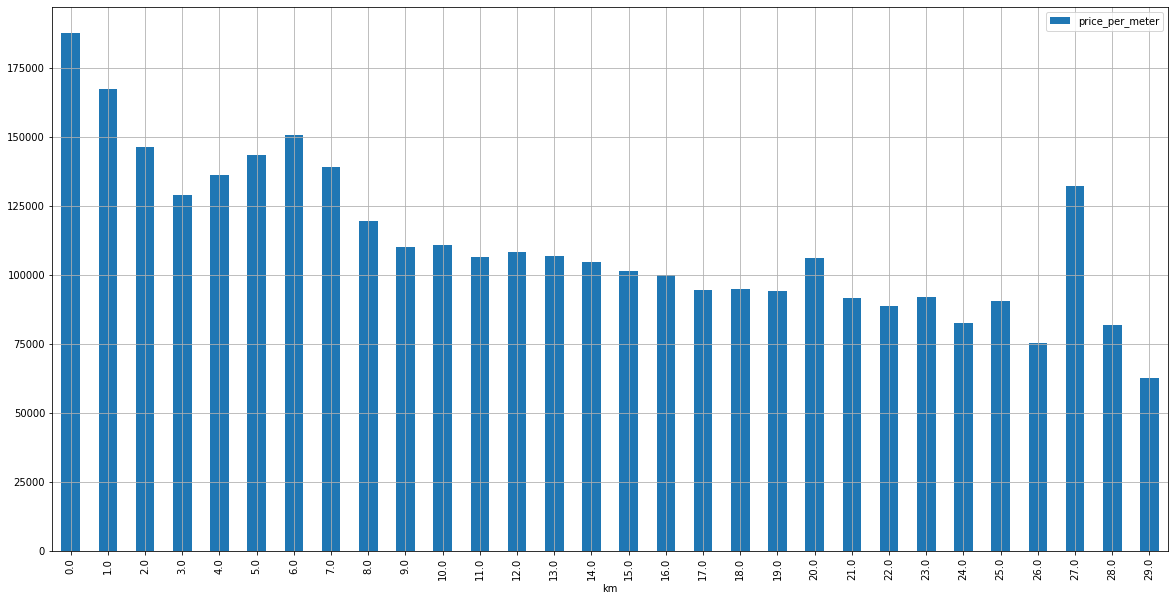

In [ ]:
data_centers.pivot_table(index='km', values='price_per_meter', aggfunc='mean').reset_index()\
.plot(y='price_per_meter', x='km',  kind='bar',figsize = (20,10), grid=True) # визуализируем

In [ ]:
data_centers['km'].corr(data_centers['price_per_meter']) # считаем корелляцию

-0.31102359523459655

Коэфициент корреляции ниже среднего (-0,31), указывает на слабую, но все же имеющуяся обратную линейную связь: чем дальше от цетра, тем выше цена за квадратный метр.

График же дает самые высокие показатели в самом центре (0 и 1 км), причем от 0 до 3 падение резкое, затем идет рост до 6 (но не достигает изначальных показателей), резкое снижение до 9-10, откуда относительно плавно снижается до плато 17-19, затем в целом идет снижение, иногда прерываемое обычно небольшими скачками (исключение - 27 км, возможно, там находтся какой-то элитный дорогой комплекс).

***Выводы***

Самые дорогие квартиры находятся в пределах 7 км от центра Санкт-Петербурга (причем самые элитные - на расстоянии 0-1 км). Дальше стоимость в целом постепенно снижается, выдавая резкий скачек около 27 км от центра.

Коэфициент корреляции Пирсона подтверждает наличие (хоть и слабое) обратной линейной зависимости: чем дальше от центра, тем ниже цена за метр. Максимум цены составил 187676 руб/м² (0 км до центра), минимум - 62482 руб/м² (29 км до центра).

### Общий вывод

Для исследования были получены данные сервиса Яндекс Недвижимость.

**На этапе предобработки были выполнены следующие действия:**

1. Приведены к хорошему стилю наименования столбцов, а сами столбцы расставлены более логично.
2. Обнаружены пропуски и по возможности осуществлена их замена.
3. Исправлены неподходящие типы данных в тех столбцах, где это было возможно и необходимо.
4. Произведена унификация наименований населенных пунктов с целью исключения дубликатов.
5. Добавлены новые столбцы для использования в будущем исследовании (например, цена одного квадратного метра), произведена категоризация этажей продаваемых квартир, введена маркировка наличия или отсутствия парка или водоема в радиусе 3 км.

**На первых этапах исследования**

1. Изучены данные на предмет аномалий. Часть аномалий было исправлено, часть - удалено целиком, остальные исключались из исследования.

2. Изучено, как быстро продавались квартиры. Установлено, что:
Быстрыми продажами можно считать те, что произошли за период до 45 дней. Необычайно долгими - те, что преодолели порог в 500 дней.Основная же часть сделок совершается в период 45-231 день.

**После чего мы проверили восемь гипотез и установили:**

1. Сильную положительную линейную зависимость между общей площадью квартиры и конечной общей ценой: Чем больше общая площадь, тем выше цена.

2. Сильную положительную линейную зависимость между площадью квартиры и конечной общей ценой: Чем больше жилая площадь, тем выше цена. Однако зависимость цены от жилой площади меньше, чем от общей площади.

3. Среднюю положительную линейную зависимость между площадью кухни и конечной общей ценой: Увеличение площади кухни также приводит к увеличению общей цены. Однако данная зависимость слабее относительно влияния других площадей на цену.

4. Среднюю положительную линейную зависимость между количеством комнат и конечной общей ценой: Квартиры с большим количеством комнат продавались по более высокой цене.

5. Зависимость между типом этажа ("первый","последний","другой") и конечной общей ценой: Квартиры, находящиеся на первом этаже, стоят гораздо дешевле остальных. Самые дорогие квартиры находятся в категории "другие".

6. Отсутствие зависимости между днем недели, в которые было размещено объявление, и конечной ценой за квартиру.

7. Слабые колебания общей цены квартиры в течении года: Cамые дорогие квартиры чаще всего появлялись на рынке продаж в апреле, самые дешевые - в июне. Однако нельзя однозначно утверждать о наличии связи между конечной ценой квартиры и месяцем, когда было выложено объявление.

8. Отсутствие зависимости между конечной ценой квартиры и годом, когда было выложено объявление.

**Изучили среднюю цену квадратного метра в десяти населенных пунктах с наибольшим количеством объявлений:**

Самый дорогой квадратный метр среди них оказался у Санкт-Петербурга (114118 руб/м²), самый дешевый - в Выборге (58142 руб/м²).

**Изучили влияние расстояния до центра на среднюю стоимость квадратного метра для Санкт-Петербурга**

Обнаружена слабая обратная линейная связь: чем дальше от центра, тем меньше цена квадратного метра. Максимум цены составил 187676 руб/м² (0 км до центра), минимум - 62482 руб/м² (29 км до центра).


**Рекомендации по улучшению сбора данных:**

1. Выявить источник пропусков в исходных данных.

Особое внимание следует уделить "геолокационным" столбцам, на которую приходится наибольшая часть потерь


Поэтому для улучшения качества исследования желательно выяснить, откуда была взята информация для датафрейма, чтобы более точно установить причины пропусков (технический или человеческий фактор) в данных и устранить их. А затем можно будет дополнительно проверить гипотезы о наличии зависимости между конечной стомостью квартиры и близостью водоемов или парков, их количеством, а также близостью аэропорта.

2. Узнать причины, по которым значения высоты потолков принимали черезчур высокие или низкие значения.

Велика вероятность человеческого фактора.

3. Унифицировать способ заполнения объявления продавцом и введение проверки заполнения.

Лучше всего - давать выбор из нескольких готовых вариантов, вместо написания своего. Например, выбор установка галочки в нужном из вариантов в параметре "студия" (да или нет) или выбор количества балконов из предложенных вариантов. Обучить сайт котнролировать пропущенные пользователем при заполнении строки и указывать ему на это. А также сделать многие из них обязательными (например, жилую площадь), без заполнения которых объявление не будет принято к публикации.

4. Оптимизировать датафрейм как способ хранения данных об объектах недвижимости.

Добавить столбцы для обозначения самого факта наличия парка или водоема в радиусе трех км. Перевести расстояние в столбцах, касающихся расстояния до центра и до аэропорта из метров в километров. По возможности исправить типы данных в столбце на более подходящие (например, установить тип datetime для содержащего дату размещения столбца).

5. Категоризировать типы этажей.

Добавить столбец, содержащий отношение этажа продаваемого объект к общему количеству этажей в здании ("первый","последний","другой").

6. Избежать дублирования.

Для избежания вариаций в названии одного и того же населенного пункта можно обучить систему подсказывать пользователю варианты на основе первых вводимых им букв, а также предлагать самостоятельно выбрать на карте.
